# Activity Cliff 예측 파이프라인

구조가 비슷한 두 분자의 약효 차이(Δ)를 예측한다. **학습은 비슷한 쌍 전부(유사 쌍 전부)로 하고,
평가는 구조가 한 군데만 다른 쌍을 기본으로 본다** (실제로 비교하는 후보 분자는 보통 한 군데만 다르다).
약효가 크게 차이 나는 쌍(|Δ| ≥ 1, **cliff**)을 잘 맞히는 것이 목표다.


In [1]:
import os, urllib.request
from multiprocessing import Pool
import numpy as np, pandas as pd
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import rdFMCS, rdFingerprintGenerator
RDLogger.DisableLog('rdApp.*')

DATA, PAIRS = 'data/moleculeace', 'data/pairs'
# 개발용: 작고 cliff 비율 높은 타깃 4개 (Ki 2 + EC50 2). 괜찮으면 30개로 늘린다
# CHEMBL2835_Ki는 쌍은 많지만 cliff 2%라 제외
DEV_TARGETS = ['CHEMBL1862_Ki', 'CHEMBL237_EC50', 'CHEMBL4616_EC50', 'CHEMBL2034_Ki']
USE_ALL_TARGETS = True  # True면 3번 셀에서 30개 전체로 바꾼다
SEED = 0
SEEDS = [0, 1, 2]       # 실행 간 편차를 재려면 시드가 여러 개여야 한다
SPLITS = ['train', 'val', 'test']   # 쌍 split. 모든 쌍은 학습 분자를 하나 이상 포함한다
CLIFF = 1.0         # |Δ| >= 1 → cliff (MoleculeACE 기준, 10배)
VAL_FRAC = 0.2      # train 분자 중 validation 비율
SIM_MIN = 0.5       # ECFP4 Tanimoto 사전 필터 (MCS 통과 쌍의 99.5% 유지)
MAX_CHANGED = 10    # 한쪽에서 바뀐 원자 수 상한 (MMP 관례)
MCS_TIMEOUT = 5     # 초 (벽시계). CHEMBL4616_EC50에서 1초 시간 초과 쌍의 83%가 5초에 풀렸다 (10초 87%)
N_JOBS = 64
os.makedirs(DATA, exist_ok=True); os.makedirs(PAIRS, exist_ok=True)

import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'Noto Sans CJK JP', 'axes.unicode_minus': False, 'figure.dpi': 110,
                     'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6, 'axes.axisbelow': True})
# 검증된 기본 categorical 팔레트의 앞 네 칸 (파랑 / 주황 / 아쿠아 / 노랑)
C1, C2, C3, C4 = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
SURFACE, MUTED = 'white', '0.45'

def tidy(a):
    """축을 눈에 덜 띄게"""
    a.spines[['top', 'right']].set_visible(False)
    a.spines[['left', 'bottom']].set_color('0.7')
    a.tick_params(colors='0.35', length=3)

## 1. 데이터

MoleculeACE의 30개 단백질 타깃 데이터를 내려받는다.

In [2]:
URL = 'https://raw.githubusercontent.com/molML/MoleculeACE/main/MoleculeACE/Data/benchmark_data/'
TARGETS = ['CHEMBL1862_Ki', 'CHEMBL1871_Ki', 'CHEMBL2034_Ki', 'CHEMBL2047_EC50', 'CHEMBL204_Ki', 'CHEMBL2147_Ki',
           'CHEMBL214_Ki', 'CHEMBL218_EC50', 'CHEMBL219_Ki', 'CHEMBL228_Ki', 'CHEMBL231_Ki', 'CHEMBL233_Ki',
           'CHEMBL234_Ki', 'CHEMBL235_EC50', 'CHEMBL236_Ki', 'CHEMBL237_EC50', 'CHEMBL237_Ki', 'CHEMBL238_Ki',
           'CHEMBL239_EC50', 'CHEMBL244_Ki', 'CHEMBL262_Ki', 'CHEMBL264_Ki', 'CHEMBL2835_Ki', 'CHEMBL287_Ki',
           'CHEMBL2971_Ki', 'CHEMBL3979_EC50', 'CHEMBL4005_Ki', 'CHEMBL4203_Ki', 'CHEMBL4616_EC50', 'CHEMBL4792_Ki']
for t in TARGETS:
    if not os.path.exists(f'{DATA}/{t}.csv'):
        urllib.request.urlretrieve(f'{URL}{t}.csv', f'{DATA}/{t}.csv')
if USE_ALL_TARGETS:
    DEV_TARGETS = TARGETS
print(f'사용 타깃 {len(DEV_TARGETS)}개')

사용 타깃 30개


## 2. 분자 나누기

분자를 **학습 / 검증 / 평가**용으로 나눈다. 쌍은 **한쪽이 반드시 학습 분자**가 되도록 쓴다.

- **학습 쌍**: 학습 분자 – 학습 분자
- **검증 쌍**: 검증 분자 – 학습 분자
- **평가 쌍**: 평가 분자 – 학습 분자

두 분자 모두 처음 보는 쌍(검증–검증, 평가–평가)은 쓰지 않는다.
실측값을 아는 기준 분자 없이 Δ만 맞히면, 두 분자의 활성을 똑같이 틀려도 정답으로 처리될 수 있기 때문이다.
(이런 쌍도 쌍 캐시에는 남겨 둔다)

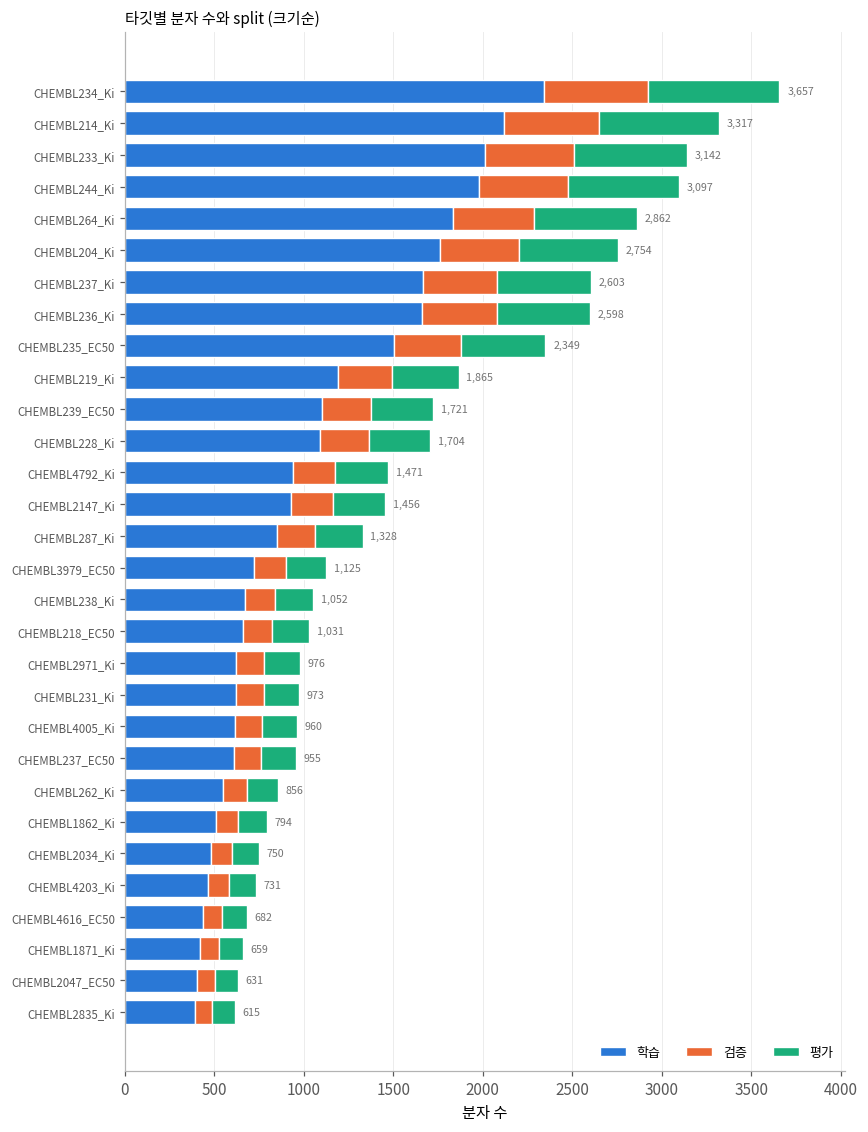

분자 48,714행 | train 31,144 (64%)  val 7,768 (16%)  test 9,802 (20%) | 타깃당 615~3,657개


In [3]:
from functools import lru_cache

@lru_cache(maxsize=None)
def split_by_smiles():
    """분자 하나는 모든 타깃에서 같은 split이다. 어느 타깃에서든 평가면 평가, 나머지 학습 분자 중 VAL_FRAC은 검증.
    타깃마다 따로 나누면 다른 타깃의 평가 분자가 학습 분자로 들어가 누수가 생긴다 (30개 타깃을 한 모델로 학습)"""
    raw = pd.concat([pd.read_csv(f'{DATA}/{t}.csv', usecols=['smiles', 'split']) for t in DEV_TARGETS])
    sp_ = raw.groupby('smiles').split.agg(lambda x: 'test' if (x == 'test').any() else 'train')
    train = sp_.index[sp_ == 'train']
    rng = np.random.default_rng(SEED)
    # ponytail: 단순 무작위 추출. val 결과가 흔들리면 cliff_mol 기준 층화 추출로 바꾼다
    sp_[rng.choice(train, int(len(train) * VAL_FRAC), replace=False)] = 'val'
    return sp_

@lru_cache(maxsize=None)   # 30개 타깃이면 load가 수십 번 불린다
def load(target):
    df = pd.read_csv(f'{DATA}/{target}.csv').rename(columns={'y [pEC50/pKi]': 'p'})[['smiles', 'p', 'cliff_mol', 'split']]
    df['split'] = df.smiles.map(split_by_smiles())
    return df

sp = pd.DataFrame({t: load(t).split.value_counts() for t in DEV_TARGETS}).T[['train', 'val', 'test']]
sp = sp.loc[sp.sum(1).sort_values().index]

fig, a_ = plt.subplots(figsize=(8, 0.30 * len(sp) + 1.4))
y, left = np.arange(len(sp)), np.zeros(len(sp))
for col, c, lbl in [('train', C1, '학습'), ('val', C2, '검증'), ('test', C3, '평가')]:
    a_.barh(y, sp[col], 0.74, left=left, color=c, label=lbl, zorder=2,
            edgecolor=SURFACE, linewidth=0.9)   # 흰 테두리로 구간을 떼어 놓는다
    left += sp[col].values
for i, v in enumerate(left):
    a_.text(v + left.max() * 0.012, i, f'{int(v):,}', va='center', fontsize=7, color=MUTED)

a_.set(yticks=y, xlabel='분자 수', xlim=(0, left.max() * 1.10))
a_.set_yticklabels(sp.index, fontsize=7.5)
a_.legend(fontsize=8.5, frameon=False, ncol=3, loc='lower right')
a_.grid(axis='y', visible=False); tidy(a_)
a_.set_title('타깃별 분자 수와 split (크기순)', loc='left', fontsize=10)
fig.tight_layout(); plt.show()

tot = sp.sum()
print(f'분자 {int(tot.sum()):,}행 | ' + '  '.join(f'{k} {int(v):,} ({v/tot.sum():.0%})' for k, v in tot.items())
      + f' | 타깃당 {int(sp.sum(1).min()):,}~{int(sp.sum(1).max()):,}개')

## 3. "한 군데만 다른 쌍" 정하기

두 분자에서 **공통 부분을 찾고, 나머지를 바뀐 부분**으로 본다.
바뀐 부분이 **한 덩어리이고 작을 때만** 쌍으로 인정한다.
아래 그림에서 빨간 원자가 바뀐 부분이다.

In [4]:
def components(mol, atoms):
    """바뀐 원자들을 결합으로 이어진 덩어리(성분) 목록으로 나눈다"""
    left, comps = set(atoms), []
    while left:
        comp, stack = set(), [left.pop()]
        while stack:
            x = stack.pop(); comp.add(x)
            for nb in mol.GetAtomWithIdx(x).GetNeighbors():
                if nb.GetIdx() in left:
                    left.remove(nb.GetIdx()); stack.append(nb.GetIdx())
        comps.append(sorted(comp))
    return comps

def n_components(mol, atoms):
    return len(components(mol, atoms))

def anchors(mol, changed, match):
    """바뀐 원자에 붙은 MCS 원자를 MCS 쿼리 내 순번으로 반환"""
    pos = {x: k for k, x in enumerate(match)}
    return {pos[nb.GetIdx()] for a in changed for nb in mol.GetAtomWithIdx(a).GetNeighbors() if nb.GetIdx() in pos}

def site_counts(a, b, ma, mb, comps_a, cb):
    """부위별 편집 수. A 성분과 B 성분이 anchor를 공유하면 replace, B에만 있으면 insert, A에만 있으면 delete"""
    A = [anchors(a, c, ma) for c in comps_a]
    B = [anchors(b, c, mb) for c in components(b, cb)]
    used = set()
    for aa in A:
        k = next((k for k, bb in enumerate(B) if k not in used and aa & bb), None)
        if k is not None:
            used.add(k)
    return len(used), len(B) - len(used), len(A) - len(used)

NO_FRAG = dict(edit='multi', atoms_a=[], atoms_b=[], n_replace=0, n_insert=0, n_delete=0, n_sites=0, n_changed=0, frag_available=0)

def analyze(sa, sb):
    """쌍 하나의 MCS 판정. 탈락한 쌍도 조각 정보를 버리지 않고 항상 같은 형태로 돌려준다
    reason: pass(한 곳만 다름) / multi_site / too_big / identical_2d / timeout
    edit: pass면 replace·insert·delete, 아니면 multi. frag_available=0이면 조각 정보 없음(timeout·identical_2d)"""
    a, b = Chem.MolFromSmiles(sa), Chem.MolFromSmiles(sb)
    r = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                       bondCompare=rdFMCS.BondCompare.CompareOrder,
                       ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
    if r.canceled:
        return dict(NO_FRAG, reason='timeout')
    q = Chem.MolFromSmarts(r.smartsString)
    # 한계: A는 첫 매칭 하나만 쓰고 B만 모든 매칭을 돈다. A가 대칭 분자면 맞는 대응을 놓칠 수 있다.
    # A도 모두 돌면 통과 쌍이 CHEMBL1862_Ki +0.37% (6,848 → 6,873), CHEMBL4616_EC50 +0.00% 였다
    # (2026-10-06 측정). 1% 미만이라 고치지 않는다
    ma = a.GetSubstructMatch(q)
    ca = [i for i in range(a.GetNumAtoms()) if i not in ma]
    comps_a = components(a, ca)
    best = None
    # 대칭 분자는 매칭이 여러 개라 anchor 순번이 달라질 수 있어 B의 매칭을 모두 확인
    for mb in b.GetSubstructMatches(q, uniquify=False, maxMatches=1000):
        cb = [i for i in range(b.GetNumAtoms()) if i not in mb]
        if not ca and not cb:
            return dict(NO_FRAG, reason='identical_2d')
        single = len(comps_a) <= 1 and n_components(b, cb) <= 1 and (not ca or not cb or anchors(a, ca, ma) == anchors(b, cb, mb))
        n_rep, n_ins, n_del = site_counts(a, b, ma, mb, comps_a, cb)
        # 대응 고르기 (결정론적): 바뀐 원자 수는 MCS 크기로 정해져 대응마다 같으므로,
        # 한 곳만 다른 대응을 먼저, 그다음 부위 수가 적은 대응, 같으면 먼저 나온 대응
        key = (not single, n_rep + n_ins + n_del)
        if best is None or key < best[0]:
            best = (key, single, dict(atoms_a=ca, atoms_b=cb, n_replace=n_rep, n_insert=n_ins, n_delete=n_del,
                                      n_sites=n_rep + n_ins + n_del, n_changed=max(len(ca), len(cb)), frag_available=1))
        if single:
            break
    _, single, out = best
    if out['n_changed'] > MAX_CHANGED:
        return dict(out, edit='multi', reason='too_big')
    if single:
        return dict(out, edit='insert' if not ca else 'delete' if not out['atoms_b'] else 'replace', reason='pass')
    return dict(out, edit='multi', reason='multi_site')

def single_site(sa, sb):
    """(호환용) 한 곳만 다르면 (edit, atoms_a, atoms_b), 아니면 탈락 사유 문자열"""
    r = analyze(sa, sb)
    return (r['edit'], r['atoms_a'], r['atoms_b']) if r['reason'] == 'pass' else r['reason']

In [5]:
# 판정 규칙 확인
assert single_site('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccc(N)cc1')[0] == 'replace'  # 치환기 교체
assert single_site('CC(=O)Nc1ccccc1', 'CC(=O)Nc1ccc(F)cc1')[0] == 'insert'      # H → F
assert single_site('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccccc1')[0] == 'delete'      # F → H
assert single_site('Cc1ccccc1', 'Cc1ccncc1')[0] == 'replace'                     # 고리 원자 C → N
assert single_site('Fc1ccc(Cl)cc1', 'Nc1ccc(Br)cc1') == 'multi_site'             # 두 곳 변경
assert single_site('C[C@H](N)O', 'C[C@@H](N)O') == 'identical_2d'                # 입체만 다름
assert single_site('CC(=O)Nc1ccccc1', 'CC(=O)Nc1ccc(OCCCCCCCCCCCC)cc1') == 'too_big'  # 13원자
# 탈락한 쌍도 조각 정보를 갖는다 (■1)
r = analyze('Fc1ccc(Cl)cc1', 'Nc1ccc(Br)cc1')
assert r['reason'] == 'multi_site' and (r['n_replace'], r['n_insert'], r['n_delete'], r['n_sites']) == (2, 0, 0, 2) and r['frag_available'] == 1
r = analyze('CC(=O)Nc1ccccc1', 'CC(=O)Nc1ccc(F)cc1')
assert r['reason'] == 'pass' and (r['n_replace'], r['n_insert'], r['n_delete']) == (0, 1, 0)
r = analyze('Clc1ccc(F)cc1', 'Fc1ccccc1')                                         # F 유지, Cl 삭제 → 삭제 1곳
assert (r['n_replace'], r['n_insert'], r['n_delete']) == (0, 0, 1), r
r = analyze('CC(=O)Nc1ccccc1', 'CC(=O)Nc1ccc(OCCCCCCCCCCCC)cc1')
assert r['reason'] == 'too_big' and r['frag_available'] == 1 and r['n_changed'] == 13
assert analyze('C[C@H](N)O', 'C[C@@H](N)O')['frag_available'] == 0
print('판정 규칙 확인 완료')

판정 규칙 확인 완료


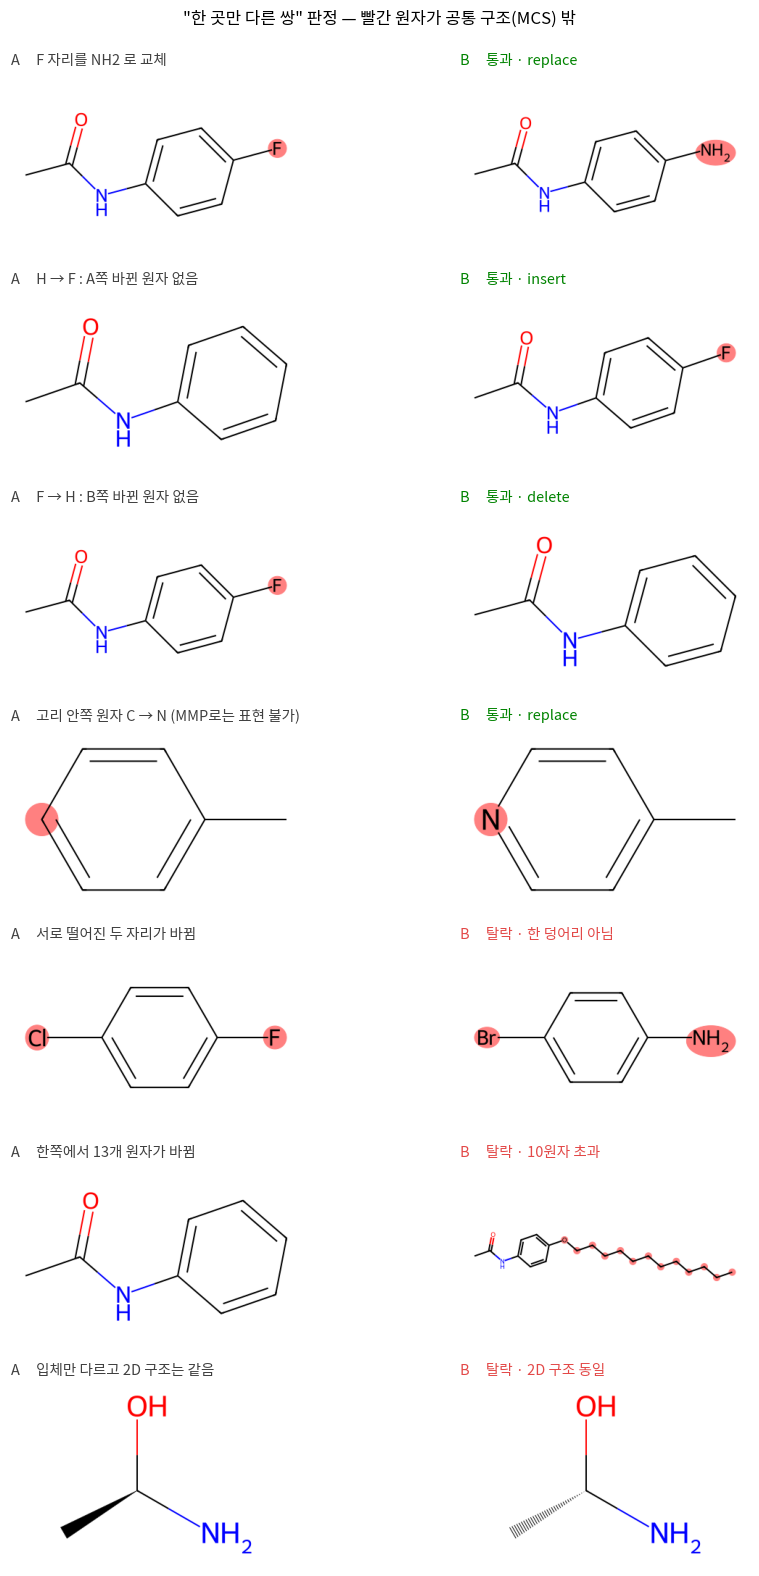

In [6]:
import io
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

RULE_CASES = [
    ('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccc(N)cc1', 'F 자리를 NH2 로 교체'),
    ('CC(=O)Nc1ccccc1',    'CC(=O)Nc1ccc(F)cc1', 'H → F : A쪽 바뀐 원자 없음'),
    ('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccccc1',    'F → H : B쪽 바뀐 원자 없음'),
    ('Cc1ccccc1',          'Cc1ccncc1',          '고리 안쪽 원자 C → N (MMP로는 표현 불가)'),
    ('Fc1ccc(Cl)cc1',      'Nc1ccc(Br)cc1',      '서로 떨어진 두 자리가 바뀜'),
    ('CC(=O)Nc1ccccc1',    'CC(=O)Nc1ccc(OCCCCCCCCCCCC)cc1', '한쪽에서 13개 원자가 바뀜'),
    ('C[C@H](N)O',         'C[C@@H](N)O',        '입체만 다르고 2D 구조는 같음'),
]
VERDICT = {'replace': '통과 · replace', 'insert': '통과 · insert', 'delete': '통과 · delete',
           'multi_site': '탈락 · 한 덩어리 아님', 'too_big': f'탈락 · {MAX_CHANGED}원자 초과',
           'identical_2d': '탈락 · 2D 구조 동일'}
PASS, FAIL = '#008300', '#e34948'

def mcs_diff(a, b):
    """판정 통과 여부와 무관하게 MCS 밖 원자를 구한다 (그림 전용)"""
    r = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                       bondCompare=rdFMCS.BondCompare.CompareOrder,
                       ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
    q = Chem.MolFromSmarts(r.smartsString)
    ma, mb = a.GetSubstructMatch(q), b.GetSubstructMatch(q)
    return q, [i for i in range(a.GetNumAtoms()) if i not in ma], [i for i in range(b.GetNumAtoms()) if i not in mb]

def render(m, hl):
    """RDKit으로 분자만 그린다. 글자는 matplotlib이 얹는다 (RDKit 폰트에 한글이 없다)"""
    d = rdMolDraw2D.MolDraw2DCairo(400, 250)
    rdMolDraw2D.PrepareAndDrawMolecule(d, m, highlightAtoms=hl)
    d.FinishDrawing()
    return plt.imread(io.BytesIO(d.GetDrawingText()))

fig, axes = plt.subplots(len(RULE_CASES), 2, figsize=(9.5, 2.05 * len(RULE_CASES)))
for (sa, sb, note), (ax_a, ax_b) in zip(RULE_CASES, axes):
    a, b = Chem.MolFromSmiles(sa), Chem.MolFromSmiles(sb)
    rdDepictor.Compute2DCoords(a)
    q, ca, cb = mcs_diff(a, b)
    rdDepictor.GenerateDepictionMatching2DStructure(b, a, refPatt=q, acceptFailure=True)
    res = single_site(sa, sb)
    key = res if isinstance(res, str) else res[0]
    ax_a.imshow(render(a, ca)); ax_b.imshow(render(b, cb))
    ax_a.set_title(f'A     {note}', loc='left', fontsize=9.5, color='0.25')
    ax_b.set_title(f'B     {VERDICT[key]}', loc='left', fontsize=9.5,
                   color=PASS if key in ('replace', 'insert', 'delete') else FAIL)
    for x in (ax_a, ax_b): x.axis('off')
fig.suptitle('"한 곳만 다른 쌍" 판정 — 빨간 원자가 공통 구조(MCS) 밖', y=0.995, fontsize=11)
fig.tight_layout(); plt.show()

## 4. 쌍 만들기

같은 타깃 안에서 서로 비슷한 분자(ECFP4 유사도 ≥ 0.5)끼리 짝을 짓는다. 쌍은 두 종류다.

- **유사 쌍 전부:** 비슷하기만 하면 전부. 여러 군데 바뀐 쌍도 들어간다 → **학습에 쓴다**
- **한 군데만 다른 쌍:** 그중 3번 규칙을 통과한 쌍 → **평가의 기본**

한 군데만 다른 쌍만으로 학습하면 데이터가 부족하다. 유사 쌍 전부로 학습하면 같은 평가 쌍에서 오차가 더 낮았다 (11번 기록).


In [7]:
FPGEN = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
PAIR_SPLIT = {('train', 'train'): 'train', ('train', 'val'): 'val_easy', ('val', 'val'): 'val_hard',
              ('test', 'train'): 'test_easy', ('test', 'test'): 'test_hard'}

def _job(args):
    i, j, sa, sb = args
    try:
        return i, j, analyze(sa, sb)
    except Exception:
        return i, j, dict(NO_FRAG, reason='error')

def make_pairs(target):
    """유사도 조건(ECFP4 Tanimoto ≥ SIM_MIN)을 만족하는 후보 쌍 전부의 MCS 판정.
    한 군데만 다른 쌍(reason == 'pass')과 유사 쌍 전부가 같은 판정을 쓴다.
    v2: 탈락한 쌍도 조각 원자·부위별 편집 수를 저장, MCS 시간 제한 5초 (옛 {target}.pkl · _simall.pkl은 보존)"""
    path = f'{PAIRS}/{target}_v3.pkl'
    if os.path.exists(path):
        return pd.read_pickle(path)
    df = load(target)
    fps = [FPGEN.GetFingerprint(Chem.MolFromSmiles(s)) for s in df.smiles]
    cand = [(i, j) for i in range(len(df))
            for j, s in enumerate(DataStructs.BulkTanimotoSimilarity(fps[i], fps[i + 1:]), i + 1) if s >= SIM_MIN]
    cand = [(i, j) for i, j in cand if tuple(sorted((df.split[i], df.split[j]))) in PAIR_SPLIT]
    with Pool(N_JOBS) as pool:
        res = pool.map(_job, [(i, j, df.smiles[i], df.smiles[j]) for i, j in cand], chunksize=20)
    rows = []
    for i, j, r in res:
        a, b = Chem.MolFromSmiles(df.smiles[i]), Chem.MolFromSmiles(df.smiles[j])
        rows.append(dict(i=i, j=j, smiles_a=df.smiles[i], smiles_b=df.smiles[j], p_a=df.p[i], p_b=df.p[j],
                         delta=df.p[j] - df.p[i], **r,
                         frag_a=Chem.MolFragmentToSmiles(a, r['atoms_a']) if r['atoms_a'] else '',
                         frag_b=Chem.MolFragmentToSmiles(b, r['atoms_b']) if r['atoms_b'] else '',
                         split=PAIR_SPLIT[tuple(sorted((df.split[i], df.split[j])))]))
    out = pd.DataFrame(rows)
    out['is_cliff'] = out.delta.abs() >= CLIFF
    out.to_pickle(path)
    return out

# 쌍 캐시에는 hard 쌍(검증–검증, 평가–평가)도 들어 있다. 파이프라인에서는 학습 분자를 포함한 쌍만 쓴다
KEEP = {'train': 'train', 'val_easy': 'val', 'test_easy': 'test'}
def keep_anchored(df):
    return df[df.split.isin(KEEP)].assign(split=lambda d: d.split.map(KEEP)).reset_index(drop=True)

ALL_PAIRS = keep_anchored(pd.concat([make_pairs(t).assign(target=t) for t in DEV_TARGETS], ignore_index=True))
pairs = ALL_PAIRS[ALL_PAIRS.reason == 'pass'].reset_index(drop=True)   # 한 군데만 다른 쌍
# 각 분자가 속한 split (쌍 split의 근거)
mol_split = {t: load(t).split for t in DEV_TARGETS}
pairs['split_a'] = [mol_split[t][i] for t, i in zip(pairs.target, pairs.i)]
pairs['split_b'] = [mol_split[t][j] for t, j in zip(pairs.target, pairs.j)]
print(f'쌍 {len(pairs):,}개  |  cliff {pairs.is_cliff.sum():,}개 ({pairs.is_cliff.mean():.1%})')

쌍 149,120개  |  cliff 33,064개 (22.2%)


In [8]:
# 유사 쌍 전부: 후보 쌍 전부. ■1부터 다중 부위 쌍도 자기 조각 마스크와 부위별 편집 수를 갖는다
pairs_all = ALL_PAIRS.copy()
pairs_all['split_a'] = [mol_split[t][i] for t, i in zip(pairs_all.target, pairs_all.i)]
pairs_all['split_b'] = [mol_split[t][j] for t, j in zip(pairs_all.target, pairs_all.j)]
_m = pairs_all.reason != 'pass'
print('판정 사유:', pairs_all.reason.value_counts().to_dict())
print(f'한 군데만 다르지 않은 쌍 {_m.sum():,}개 중 조각 정보 복원 {pairs_all[_m].frag_available.mean():.1%} '
      f'(나머지는 MCS 시간 초과·입체만 다름)')

# 학습은 유사 쌍 전부 하나로 한다. 평가는 11번에서 한 군데만 다른 쌍을 기본으로 본다 (유사 쌍 전부는 참고)
PAIRSETS = {'all': pairs_all}

summary = pd.DataFrame({
    '한 군데만 다른 쌍': {'학습': int((pairs.split == 'train').sum()),
                   '평가(val+test)': int((pairs.split != 'train').sum()),
                   'cliff 비율': f'{pairs.is_cliff.mean():.1%}'},
    '유사 쌍 전부':     {'학습': int((pairs_all.split == 'train').sum()),
                   '평가(val+test)': int((pairs_all.split != 'train').sum()),
                   'cliff 비율': f'{pairs_all.is_cliff.mean():.1%}'}}).T
summary['배수'] = [1.0, round(len(pairs_all) / len(pairs), 1)]
summary

판정 사유: {'multi_site': 305822, 'too_big': 208087, 'pass': 149120, 'timeout': 81175, 'identical_2d': 1498}
한 군데만 다르지 않은 쌍 596,582개 중 조각 정보 복원 86.1% (나머지는 MCS 시간 초과·입체만 다름)


,학습,평가(val+test),cliff 비율,배수
한 군데만 다른 쌍,70052,79068,22.2%,1.0
유사 쌍 전부,349565,396137,27.7%,5.0


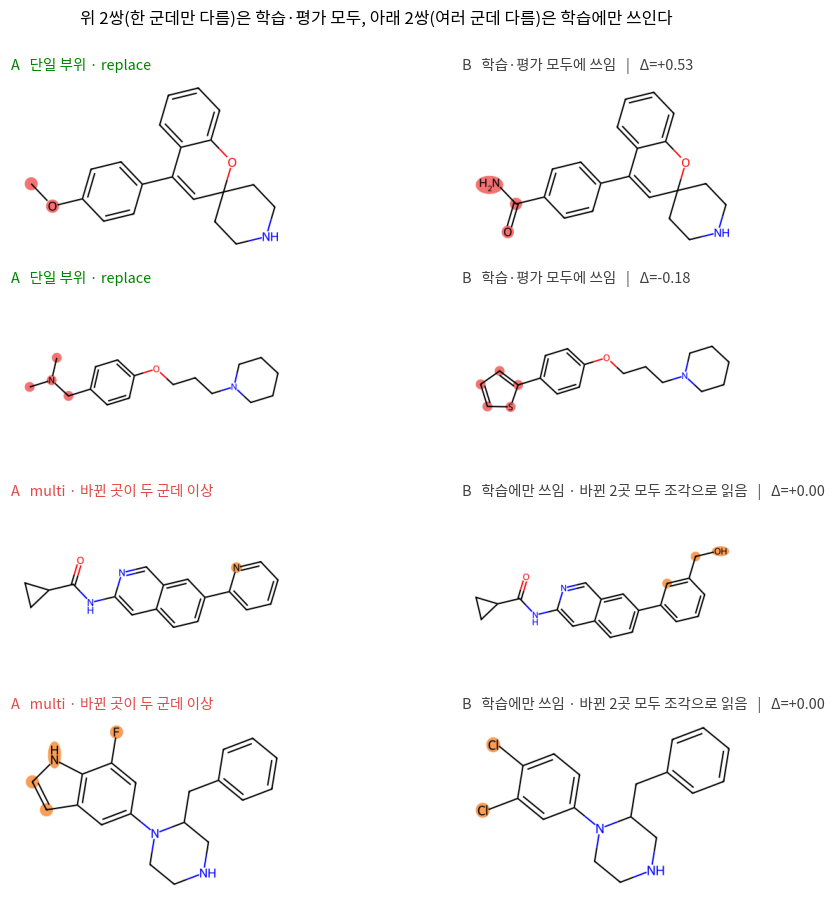

In [9]:
import io
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

def _smi(t, k): return load(t).smiles[k]
def _nat(t, k): return Chem.MolFromSmiles(_smi(t, k)).GetNumAtoms()

def mcs_diff(a, b):
    """판정 통과 여부와 무관하게 공통 구조 밖 원자를 구한다 (그림 전용)"""
    r = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                       bondCompare=rdFMCS.BondCompare.CompareOrder,
                       ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
    q = Chem.MolFromSmarts(r.smartsString)
    ma, mb = a.GetSubstructMatch(q), b.GetSubstructMatch(q)
    return q, [i for i in range(a.GetNumAtoms()) if i not in ma], [i for i in range(b.GetNumAtoms()) if i not in mb]

def render_mol(m, hl, color):
    """RDKit으로 분자만 그린다. 글자는 matplotlib이 얹는다 (RDKit 폰트에 한글이 없다)"""
    d = rdMolDraw2D.MolDraw2DCairo(400, 250)
    rdMolDraw2D.PrepareAndDrawMolecule(d, m, highlightAtoms=hl, highlightAtomColors={i: color for i in hl})
    d.FinishDrawing()
    return plt.imread(io.BytesIO(d.GetDrawingText()))

def _pick(sub, n, seed, want_multi):
    """작고 보기 좋은 예시만 고른다. multi는 바뀐 곳이 실제로 두 군데 이상인 것"""
    out = []
    for r in sub.sample(min(len(sub), 600), random_state=seed).itertuples():
        if max(_nat(r.target, r.i), _nat(r.target, r.j)) > 24:
            continue
        a, b = Chem.MolFromSmiles(_smi(r.target, r.i)), Chem.MolFromSmiles(_smi(r.target, r.j))
        _, ca, cb = mcs_diff(a, b)
        if not ca or not cb or max(len(ca), len(cb)) > 6:
            continue
        if (max(n_components(a, ca), n_components(b, cb)) >= 2) != want_multi:
            continue
        out.append(r)
        if len(out) == n:
            break
    return out

RED, ORANGE = (0.95, 0.45, 0.45), (0.97, 0.62, 0.35)
_tr = pairs_all[pairs_all.split == 'train']
rows = ([(r, 'single') for r in _pick(_tr[_tr.edit != 'multi'], 2, 1, False)]
        + [(r, 'multi') for r in _pick(_tr[_tr.edit == 'multi'], 2, 5, True)])

fig, axes = plt.subplots(len(rows), 2, figsize=(9.5, 2.05 * len(rows)))
for (r, kind), (ax_a, ax_b) in zip(rows, axes):
    a, b = Chem.MolFromSmiles(_smi(r.target, r.i)), Chem.MolFromSmiles(_smi(r.target, r.j))
    rdDepictor.Compute2DCoords(a)
    q, _, _ = mcs_diff(a, b)
    ca, cb = list(r.atoms_a), list(r.atoms_b)   # 모델이 실제로 읽는 조각 (바뀐 곳 전부)
    rdDepictor.GenerateDepictionMatching2DStructure(b, a, refPatt=q, acceptFailure=True)
    col = RED if kind == 'single' else ORANGE
    ax_a.imshow(render_mol(a, ca, col)); ax_b.imshow(render_mol(b, cb, col))
    if kind == 'single':
        ax_a.set_title(f'A   단일 부위 · {r.edit}', loc='left', fontsize=9.5, color='#008300')
        ax_b.set_title(f'B   학습·평가 모두에 쓰임   |   Δ={r.delta:+.2f}', loc='left', fontsize=9.5, color='0.25')
    else:
        ax_a.set_title('A   multi · 바뀐 곳이 두 군데 이상', loc='left', fontsize=9.5, color='#e34948')
        ax_b.set_title(f'B   학습에만 쓰임 · 바뀐 {r.n_sites}곳 모두 조각으로 읽음   |   Δ={r.delta:+.2f}', loc='left', fontsize=9.5, color='0.25')
    for x in (ax_a, ax_b):
        x.axis('off')
fig.suptitle('위 2쌍(한 군데만 다름)은 학습·평가 모두, 아래 2쌍(여러 군데 다름)은 학습에만 쓰인다', y=0.997, fontsize=11)
fig.tight_layout(); plt.show()

## 5. 쌍 살펴보기

만들어진 쌍의 개수와 cliff 비율, 그리고 실제 예시를 본다.
cliff 쌍을 일부러 골라 넣지 않았다 — 쌍을 먼저 만들고 약효 차이는 나중에 확인했다.

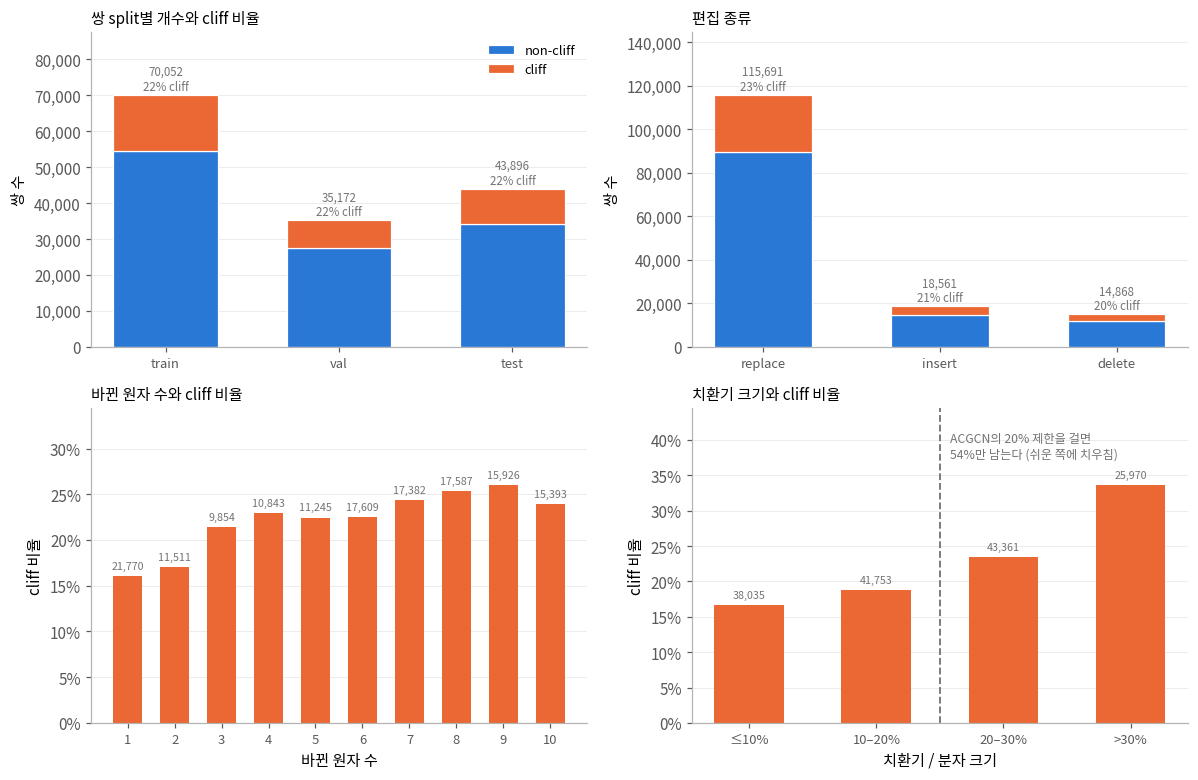

In [10]:
# 바뀐 원자 수와 "치환기 / 분자" 크기 비율 (ACGCN은 20% 이하인 쌍만 썼다)
n_heavy = {(t, k): Chem.MolFromSmiles(s).GetNumAtoms() for t in DEV_TARGETS for k, s in enumerate(load(t).smiles)}
pairs['n_changed'] = pairs[['atoms_a', 'atoms_b']].map(len).max(axis=1)
pairs['size_ratio'] = pairs.n_changed / [min(n_heavy[t, i], n_heavy[t, j])
                                         for t, i, j in zip(pairs.target, pairs.i, pairs.j)]

fig, ax = plt.subplots(2, 2, figsize=(11, 7.2))
thousands = lambda v, _: f'{int(v):,}'

def stacked(a_, idx, nc, cl, width=0.6):
    x = np.arange(len(idx))
    a_.bar(x, nc, width, color=C1, label='non-cliff', zorder=2, edgecolor=SURFACE, linewidth=0.8)
    a_.bar(x, cl, width, bottom=nc, color=C2, label='cliff', zorder=2, edgecolor=SURFACE, linewidth=0.8)
    for i, (n, c) in enumerate(zip(nc, cl)):
        a_.text(i, n + c + (nc + cl).max() * 0.02, f'{n + c:,}\n{c / (n + c):.0%} cliff',
                ha='center', fontsize=7.5, color=MUTED)
    a_.set(xticks=x, ylabel='쌍 수', ylim=(0, (nc + cl).max() * 1.25))
    a_.set_xticklabels(idx, fontsize=8.5)
    a_.yaxis.set_major_formatter(thousands)

d = pairs.groupby(['split', 'is_cliff']).size().unstack(fill_value=0).reindex(SPLITS)
stacked(ax[0, 0], SPLITS, d[False].values, d[True].values)
ax[0, 0].legend(fontsize=8.5, frameon=False)
ax[0, 0].set_title('쌍 split별 개수와 cliff 비율', loc='left', fontsize=10)

e = pairs.groupby(['edit', 'is_cliff']).size().unstack(fill_value=0).sort_values(True, ascending=False)
stacked(ax[0, 1], e.index, e[False].values, e[True].values, 0.55)
ax[0, 1].set_title('편집 종류', loc='left', fontsize=10)

def ratio_bars(a_, g, xlabel, note=None, width=0.6):
    x = np.arange(len(g))
    a_.bar(x, g['mean'], width, color=C2, zorder=2)
    for i, (_, r) in enumerate(g.iterrows()):
        a_.text(i, r['mean'] + g['mean'].max() * 0.03, f'{int(r["size"]):,}', ha='center', fontsize=7, color=MUTED)
    a_.set(xticks=x, xlabel=xlabel, ylabel='cliff 비율', ylim=(0, g['mean'].max() * 1.32))
    a_.set_xticklabels(g.index, fontsize=8.5)
    a_.yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')

ratio_bars(ax[1, 0], pairs.groupby('n_changed').is_cliff.agg(['size', 'mean']), '바뀐 원자 수')
ax[1, 0].set_title('바뀐 원자 수와 cliff 비율', loc='left', fontsize=10)

rb = pd.cut(pairs.size_ratio, [0, 0.1, 0.2, 0.3, 1.0], labels=['≤10%', '10–20%', '20–30%', '>30%'])
g = pairs.groupby(rb, observed=True).is_cliff.agg(['size', 'mean'])
ratio_bars(ax[1, 1], g, '치환기 / 분자 크기', width=0.55)
ax[1, 1].axvline(1.5, color=MUTED, ls='--', lw=1.2)
ax[1, 1].text(1.58, g['mean'].max() * 1.22, f'ACGCN의 20% 제한을 걸면\n{(pairs.size_ratio <= 0.2).mean():.0%}만 남는다 (쉬운 쪽에 치우침)',
              fontsize=8, color=MUTED, va='top')
ax[1, 1].set_title('치환기 크기와 cliff 비율', loc='left', fontsize=10)

for a_ in ax.ravel():
    tidy(a_); a_.grid(axis='x', visible=False)
fig.tight_layout(); plt.show()

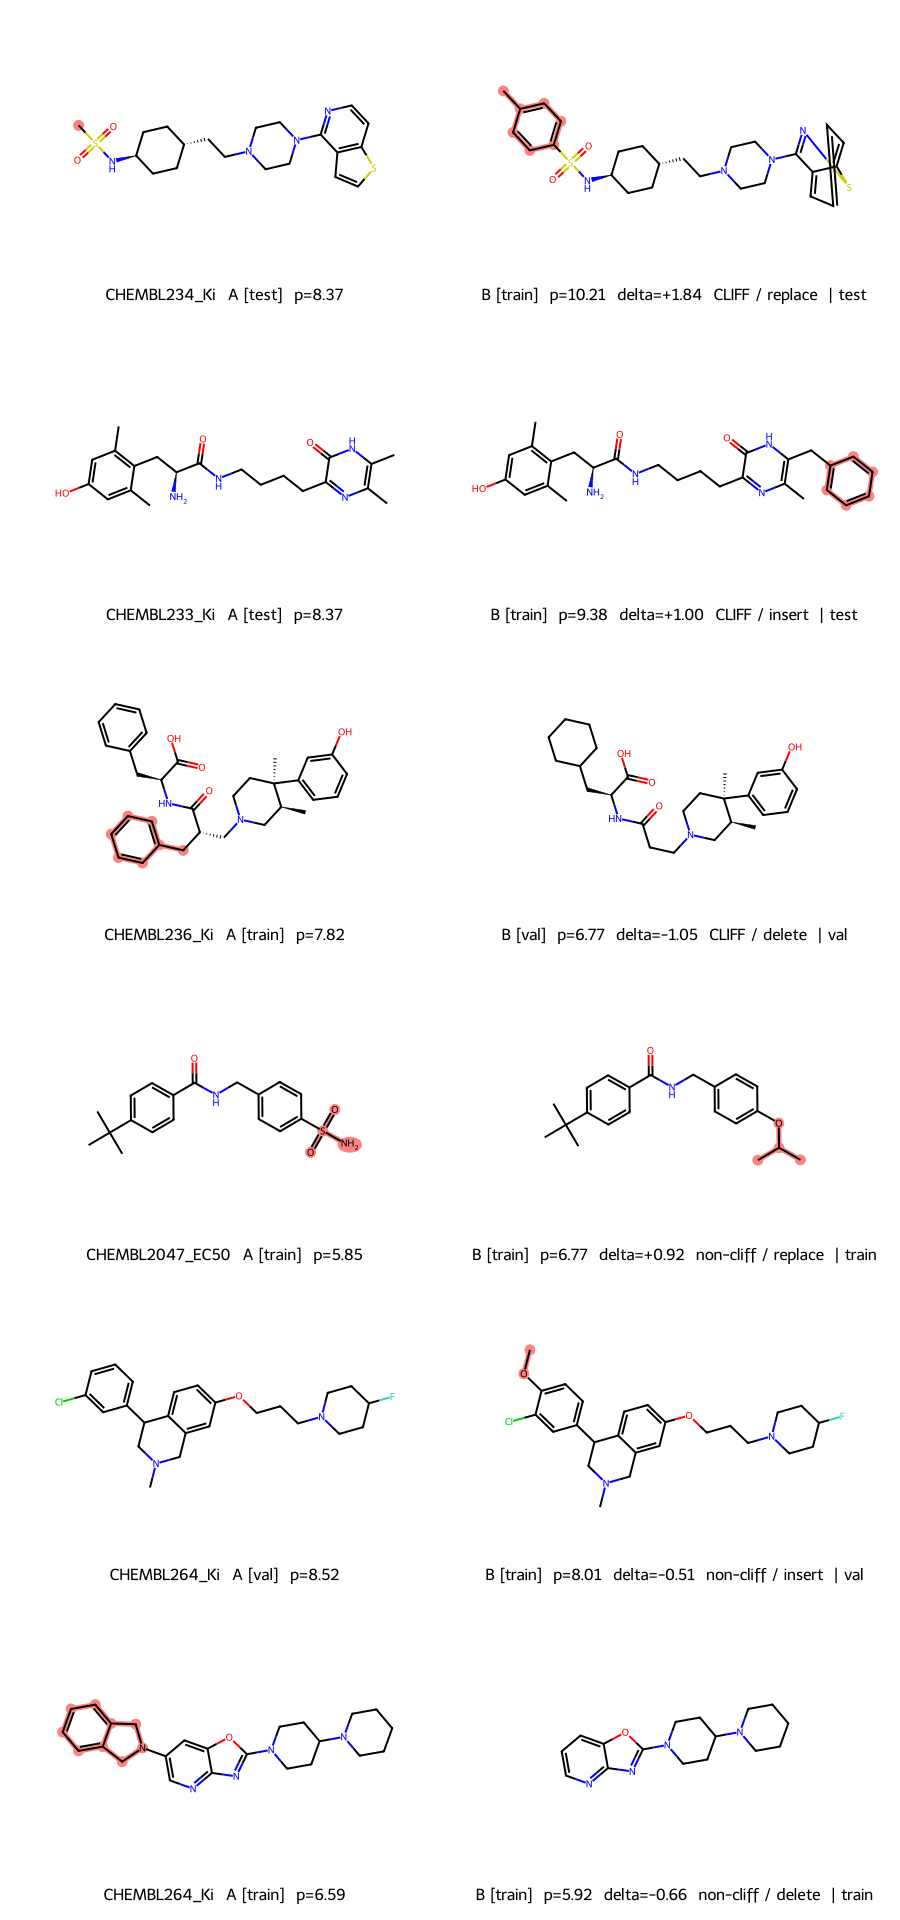

In [11]:
from rdkit.Chem import Draw, rdDepictor

def draw_pairs(rows):
    mols, highlights, legends = [], [], []
    for r in rows.itertuples():
        a, b = Chem.MolFromSmiles(r.smiles_a), Chem.MolFromSmiles(r.smiles_b)
        rdDepictor.Compute2DCoords(a)
        mcs = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                             bondCompare=rdFMCS.BondCompare.CompareOrder, ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
        rdDepictor.GenerateDepictionMatching2DStructure(b, a, refPatt=Chem.MolFromSmarts(mcs.smartsString), acceptFailure=True)
        mols += [a, b]
        highlights += [r.atoms_a, r.atoms_b]
        legends += [f'{r.target}  A [{r.split_a}]  p={r.p_a:.2f}',
                    f'B [{r.split_b}]  p={r.p_b:.2f}  delta={r.delta:+.2f}  {"CLIFF" if r.is_cliff else "non-cliff"} / {r.edit}  | {r.split}']
    return Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(450, 320), highlightAtomLists=highlights, legends=legends)

sample = pairs.groupby(['is_cliff', 'edit']).sample(1, random_state=SEED).sort_values(['is_cliff', 'edit'], ascending=False)
draw_pairs(sample)

## 6. 평가 쌍 예시

평가 분자 하나가 **여러 학습 분자와** 짝을 이룬다.
11번에서 이 학습 분자들의 실측값을 기준으로 평가 분자의 활성을 추정한다.

평가 분자 = CHEMBL231_Ki:753 | 짝이 되는 학습 분자 5 개 중 3개 표시


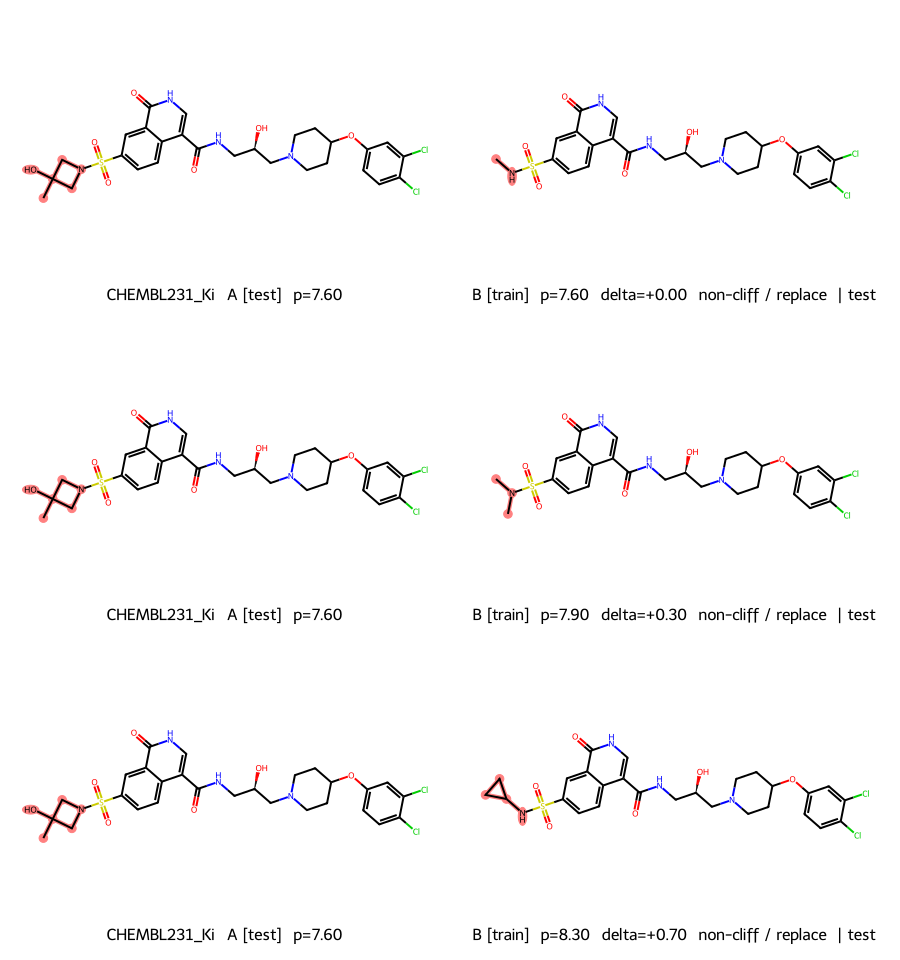

In [12]:
# 평가 쌍마다 평가 분자를 기준(center)으로 펼친 뒤, 학습 분자 짝이 3개 이상인 평가 분자 하나 선택
long = pd.concat([pairs[pairs[s] == 'test'].assign(center=lambda x: x.target + ':' + x[m].astype(str))
                  for m, s in [('i', 'split_a'), ('j', 'split_b')]])
n_ref = long.groupby('center').size()
center = n_ref[n_ref >= 3].sample(1, random_state=SEED).index[0]
print('평가 분자 =', center, '| 짝이 되는 학습 분자', int(n_ref[center]), '개 중 3개 표시')
draw_pairs(long[long.center == center].sample(3, random_state=SEED))

In [13]:
# 모든 쌍에 학습 분자가 하나 이상 있어야 한다 (기준 분자 없는 쌍이 빠졌는지 확인)
assert ((pairs.split_a == 'train') | (pairs.split_b == 'train')).all()
assert set(pairs.split) == set(SPLITS) and not pairs.split.isna().any()
# 같은 분자는 모든 타깃에서 같은 split이어야 한다 (타깃 간 누수 방지)
assert pd.concat([load(t)[['smiles', 'split']] for t in DEV_TARGETS]).drop_duplicates().smiles.is_unique
print('쌍 구성 확인 완료: 모든 쌍에 학습 분자 포함, 분자 split 타깃 간 일치')

쌍 구성 확인 완료: 모든 쌍에 학습 분자 포함


## 7. 비교 대상 (SVR)

기존 방식: 분자 하나씩 약효를 예측한 뒤 **두 값을 빼서** 차이를 구한다.
**항상 0이라고 답하는 기준**도 함께 둔다.

In [14]:
from sklearn.svm import SVR

SVR_C = [1, 10, 100, 1000]

def ecfp(smiles):
    return np.array([FPGEN.GetFingerprintAsNumPy(Chem.MolFromSmiles(s)) for s in smiles], dtype=np.float32)

def tanimoto(X, Y):
    inter = X @ Y.T
    return inter / (X.sum(1)[:, None] + Y.sum(1)[None, :] - inter)

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

def svr_predict(target):
    """train 분자로 학습, val로 C 선택 → 모든 분자의 예측값"""
    df = load(target)
    X = ecfp(df.smiles)
    tr, va = (df.split == 'train').values, (df.split == 'val').values
    K = tanimoto(X, X[tr])
    fit = lambda C: SVR(kernel='precomputed', C=C).fit(K[tr], df.p[tr])
    val_rmse = {C: rmse(fit(C).predict(K[va]), df.p[va]) for C in SVR_C}
    best = min(val_rmse, key=val_rmse.get)
    return df.assign(pred=fit(best).predict(K)), best

mol_pred, rows = {}, []
for t in DEV_TARGETS:
    d, C = svr_predict(t)
    mol_pred[t] = d.pred
    te = d[d.split == 'test']
    rows.append(dict(target=t, C=C, test_rmse=rmse(te.pred, te.p), test_rmse_cliff_mol=rmse(te.pred[te.cliff_mol == 1], te.p[te.cliff_mol == 1])))
for _p in (pairs, pairs_all):   # 한 군데만 다른 쌍(아래 표)과 유사 쌍 전부(학습·11번 평가)
    _p['pred_svr'] = [mol_pred[t][j] - mol_pred[t][i] for t, i, j in zip(_p.target, _p.i, _p.j)]
    _p['pred_zero'] = 0.0
svr_mol = pd.DataFrame(rows)
print(f'타깃 {len(svr_mol)}개 학습 완료  |  분자 단위 test RMSE 중앙값 {svr_mol.test_rmse.median():.3f}')

타깃 30개 학습 완료  |  분자 단위 test RMSE 중앙값 0.694


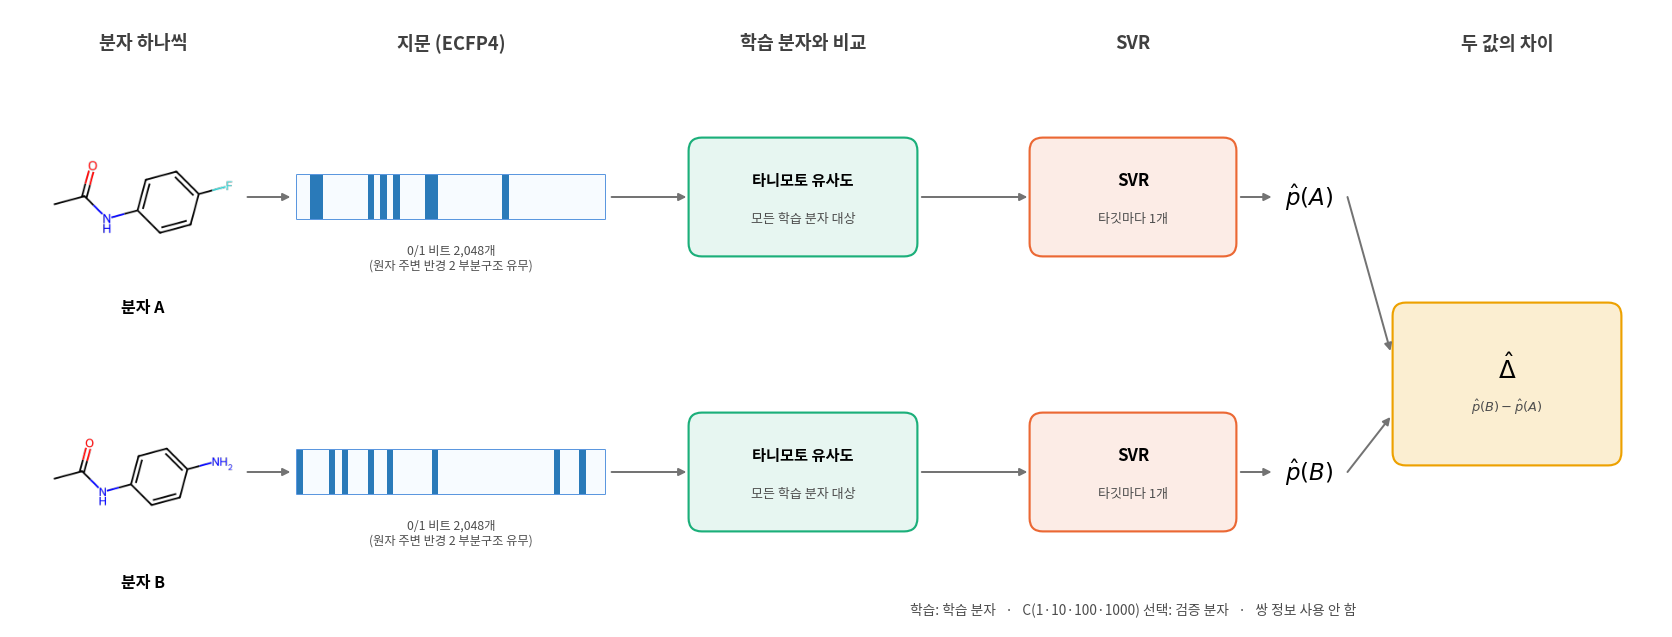

In [15]:
# 비교 대상 SVR이 Δ를 내는 과정. 분자는 RDKit, 글자는 matplotlib
import io
from matplotlib.patches import FancyBboxPatch
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

def _mol_img(smiles, size=230):
    mol = Chem.MolFromSmiles(smiles); rdDepictor.Compute2DCoords(mol)
    d = rdMolDraw2D.MolDraw2DCairo(size, size)
    d.drawOptions().clearBackground = False
    d.DrawMolecule(mol); d.FinishDrawing()
    return plt.imread(io.BytesIO(d.GetDrawingText()))

fig = plt.figure(figsize=(15, 5.6))
ax = fig.add_axes([0, 0, 1, 1]); ax.set_xlim(0, 150); ax.set_ylim(0, 56); ax.axis('off')

def box(x, y, w, h, title, sub='', color=C1, fill=0.10, fs=11):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.4,rounding_size=1.2',
                                fc=(*plt.matplotlib.colors.to_rgb(color), fill), ec=color, lw=1.4))
    ax.text(x + w / 2, y + h / 2 + (1.5 if sub else 0), title, ha='center', va='center', fontsize=fs, weight='bold')
    if sub:
        ax.text(x + w / 2, y + h / 2 - 2.0, sub, ha='center', va='center', fontsize=8.5, color='0.3')

def arrow(x0, y0, x1, y1, color='0.45'):
    ax.annotate('', (x1, y1), (x0, y0), arrowprops=dict(arrowstyle='-|>', color=color, lw=1.3, shrinkA=0, shrinkB=0))

for x, t in [(12, '분자 하나씩'), (40, '지문 (ECFP4)'), (72, '학습 분자와 비교'), (102, 'SVR'), (136, '두 값의 차이')]:
    ax.text(x, 52.5, t, ha='center', fontsize=12, weight='bold', color='0.25')

rng = np.random.default_rng(0)
for y, smi, name in [(30, 'CC(=O)Nc1ccc(F)cc1', 'A'), (5, 'CC(=O)Nc1ccc(N)cc1', 'B')]:
    ax.imshow(_mol_img(smi), extent=(3, 21, y, y + 18), zorder=2)
    ax.text(12, y - 0.3, f'분자 {name}', ha='center', va='top', fontsize=10.5, weight='bold')
    # 지문: 2048칸 중 일부만 1인 막대
    bits = (rng.random(48) < 0.18).astype(float)
    ax.imshow(bits[None, :], extent=(26, 54, y + 7, y + 11), cmap='Blues', vmin=0, vmax=1.4, aspect='auto', zorder=2)
    ax.add_patch(plt.Rectangle((26, y + 7), 28, 4, fill=False, ec=C1, lw=1))
    ax.text(40, y + 4.8, '0/1 비트 2,048개\n(원자 주변 반경 2 부분구조 유무)', ha='center', va='top', fontsize=8, color='0.3')
    arrow(21.5, y + 9, 25.4, y + 9)
    box(62, y + 4, 20, 10, '타니모토 유사도', '모든 학습 분자 대상', color=C3, fill=0.10, fs=10)
    arrow(54.6, y + 9, 61.4, y + 9)
    box(93, y + 4, 18, 10, 'SVR', '타깃마다 1개', color=C2, fill=0.12)
    arrow(82.8, y + 9, 92.4, y + 9)
    ax.text(118, y + 9, rf'$\hat{{p}}({name})$', ha='center', va='center', fontsize=15)
    arrow(111.8, y + 9, 114.6, y + 9)

box(126, 15, 20, 14, r'$\hat{\Delta}$', r'$\hat{p}(B) - \hat{p}(A)$', color=C4, fill=0.18, fs=16)
arrow(121.5, 39, 125.4, 25); arrow(121.5, 14, 125.4, 19)
ax.text(102, 1.2, '학습: 학습 분자   ·   C(1·10·100·1000) 선택: 검증 분자   ·   쌍 정보 사용 안 함',
        ha='center', fontsize=9, color='0.3')
plt.show()

### 평가 방법

평가 쌍(평가 분자 – 학습 분자)을 cliff 여부로 나눠 오차(RMSE)를 본다. 낮을수록 좋다.

In [16]:
def rmse_table(df, col, index='split'):
    se = df.assign(se=(df[col] - df.delta) ** 2)
    t = se.pivot_table(index=index, columns='is_cliff', values='se', aggfunc='mean').rename(columns={False: 'non-cliff', True: 'cliff'})
    t['all'] = se.groupby(index).se.mean()
    return t[['cliff', 'non-cliff', 'all']] ** 0.5

pd.concat({m: rmse_table(pairs, f'pred_{m}').loc[SPLITS] for m in ['zero', 'svr']}, axis=1).round(3)

zero                     svr                 
is_cliff  cliff non-cliff    all  cliff non-cliff    all
split                                                   
train     1.741     0.463  0.915  0.422     0.168  0.248
val       1.748     0.465  0.917  0.945     0.446  0.593
test      1.717     0.466  0.910  0.928     0.449  0.591

## 8. 분자를 그래프로 바꾸기

원자는 점, 결합은 선으로 바꿔 모델에 넣는다.

In [17]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GINEConv, global_mean_pool, global_add_pool
from rdkit.Chem.rdchem import HybridizationType as H, BondType as B

ELEMENTS = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'B', 'Si', 'Se']
HYBRID = [H.SP, H.SP2, H.SP3, H.SP3D, H.SP3D2]
BONDS = [B.SINGLE, B.DOUBLE, B.TRIPLE, B.AROMATIC]
EDITS = ['replace', 'insert', 'delete']   # 한 곳만 다른 쌍의 편집 이름 (그림·통계용)
# 편집 정보 6칸 (■1): 한 쌍에 교체와 추가가 함께 있을 수 있어 one-hot 대신 multi-hot
#   [교체 있음, 추가 있음, 삭제 있음, 부위 수 / MAX_SITES, 바뀐 원자 수 / MAX_CHANGED, 조각 있음]
#   조각 있음 = 0이면 조각 벡터 f가 실제 값이 아니라 0 (MCS 시간 초과·입체만 다름)
MAX_SITES = 4
# 큰 조각 처리 (■1-8): 바뀐 원자가 MAX_CHANGED를 넘는 쌍(too_big)은 마스크가 커져 15원자 평균처럼 성질이 다른 조각이 된다.
#   None = 그대로 쓰고 바뀐 원자 수 칸으로 구별 / 숫자 = 그보다 큰 조각은 마스크를 비우고 '조각 있음'=0
MASK_CAP = None
# 지름길 점검 (ablation): True면 '바뀐 원자 수' 칸을 0으로 둔다 (= 그 칸을 빼는 것과 같다). 가중치 이름에 _nonchanged
DROP_NCHANGED = False
EDIT_NAMES = ['교체 있음', '추가 있음', '삭제 있음', '부위 수', '바뀐 원자 수', '조각 있음']
N_EDIT = len(EDIT_NAMES)

def edit_feat(r, flip=False):
    ins, dele = (r.n_delete, r.n_insert) if flip else (r.n_insert, r.n_delete)   # B→A 방향에서는 추가와 삭제가 바뀐다
    capped = MASK_CAP is not None and r.n_changed > MASK_CAP
    return [float(r.n_replace > 0), float(ins > 0), float(dele > 0),
            min(r.n_sites / MAX_SITES, 1.0), 0.0 if DROP_NCHANGED else min(r.n_changed / MAX_CHANGED, 3.0), float(r.frag_available and not capped)]

def onehot(x, choices):
    return [float(x == c) for c in choices] + [float(x not in choices)]

def atom_features(a):
    return (onehot(a.GetSymbol(), ELEMENTS) + onehot(a.GetDegree(), [0, 1, 2, 3, 4, 5]) + onehot(a.GetFormalCharge(), [-1, 0, 1])
            + onehot(a.GetTotalNumHs(), [0, 1, 2, 3]) + onehot(a.GetHybridization(), HYBRID) + [float(a.GetIsAromatic()), float(a.IsInRing())])

def graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    src, dst, edge = [], [], []
    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        f = onehot(b.GetBondType(), BONDS) + [float(b.GetIsConjugated())]
        src += [i, j]; dst += [j, i]; edge += [f, f]
    return Data(x=torch.tensor([atom_features(a) for a in mol.GetAtoms()]),
                edge_index=torch.tensor([src, dst], dtype=torch.long).reshape(2, -1),
                edge_attr=torch.tensor(edge).reshape(-1, len(BONDS) + 2))

graphs = {(t, k): graph(s) for t in DEV_TARGETS for k, s in enumerate(load(t).smiles)}
N_ATOM, N_BOND = len(atom_features(Chem.MolFromSmiles('C').GetAtomWithIdx(0))), len(BONDS) + 2

def with_mask(g, atoms):
    if MASK_CAP is not None and len(atoms) > MASK_CAP:
        atoms = []   # 큰 조각은 마스크를 비운다 (■1-8 비교 조건)
    mask = torch.zeros(g.num_nodes, dtype=torch.bool)
    mask[torch.tensor(atoms, dtype=torch.long)] = True  # atoms가 비면(multi 쌍) 전부 False → f = 0 벡터
    return Data(x=g.x, edge_index=g.edge_index, edge_attr=g.edge_attr, mask=mask)

def samples(df, both_directions=False, reverse=False, gdict=None):
    """reverse=True면 (B, A, −Δ)만 만든다. 양방향 평균 예측에 쓴다. gdict: 쓸 그래프 묶음 (기본 graphs)"""
    gdict = graphs if gdict is None else gdict
    out = []
    for r in df.itertuples():
        ga, gb = with_mask(gdict[r.target, r.i], r.atoms_a), with_mask(gdict[r.target, r.j], r.atoms_b)
        t = DEV_TARGETS.index(r.target)
        fwd = (ga, gb, edit_feat(r), t, (r.p_a, r.p_b))                  # 마지막 = (A 실측, B 실측)
        rev = (gb, ga, edit_feat(r, flip=True), t, (r.p_b, r.p_a))
        out += [fwd, rev] if both_directions else [rev] if reverse else [fwd]
    return out

def collate(batch):
    """y = [A 실측, B 실측] (배치 × 2). 실제 Δ = y[:, 1] − y[:, 0]"""
    ga, gb, edit, tgt, y = zip(*batch)
    return (Batch.from_data_list(ga), Batch.from_data_list(gb),
            torch.tensor(edit, dtype=torch.float32), torch.tensor(tgt), torch.tensor(y, dtype=torch.float32))

ga, gb, edit, tgt, y = collate(samples(pairs.head(2)))
print('원자 특징', N_ATOM, '| 결합 특징', N_BOND, '| 타깃', len(DEV_TARGETS),
      '| 배치 A 노드', ga.num_nodes, '| mask 원자', int(ga.mask.sum()), '| edit', edit.tolist())

/home/bising0922/micromamba/envs/aienv/lib/python3.13/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


원자 특징 37 | 결합 특징 6 | 타깃 30 | 배치 A 노드 54 | mask 원자 12 | edit [[1.0, 0.0, 0.0, 0.25, 0.6000000238418579, 1.0], [0.0, 0.0, 1.0, 0.25, 0.6000000238418579, 1.0]]


### 편집 정보 6칸: 여러 군데 바뀐 쌍은 어떻게 들어가나

학습 쌍(유사 쌍 전부)에는 여러 군데 바뀐 쌍이 많다. 바뀐 덩어리(부위)마다 A와 B를 맞춰 본다.

- A의 덩어리와 B의 덩어리가 **같은 자리에 붙어 있으면 교체**, **B에만 있으면 추가**, **A에만 있으면 삭제**
- 앞 세 칸(교체·추가·삭제)은 그 종류가 **한 번이라도 있으면 1**이다. 두 곳을 교체해도 교체 칸은 1이다
- **몇 곳인지는 "부위 수" 칸**(바뀐 곳 ÷ 4, 4곳 이상은 1), 얼마나 큰지는 **"바뀐 원자 수" 칸**(÷ 10, 30개 이상은 3)
- MCS 시간 초과·입체만 다른 쌍은 바뀐 부분을 알 수 없어 모두 0이고 **"조각 있음" = 0**

평가 쌍(한 군데만 다른 쌍)은 항상 앞 세 칸 중 하나만 1이고 부위 수는 1곳이다.


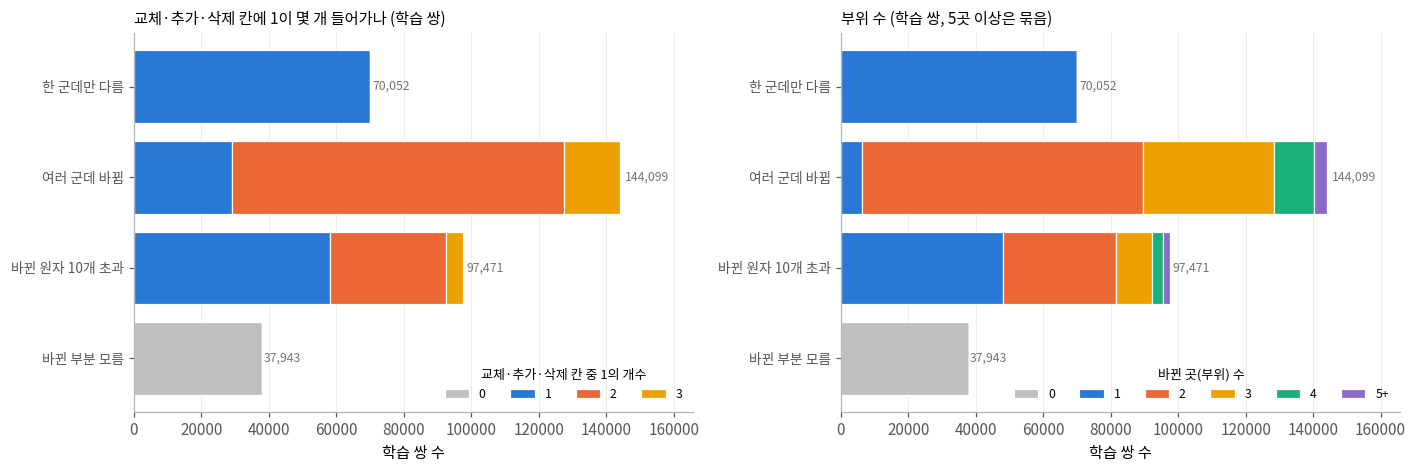

,교체·추가·삭제 수,바뀐 원자,교체 있음,추가 있음,삭제 있음,부위 수,바뀐 원자 수,조각 있음
한 군데만 다름,1·0·0,3,1.0,0.0,0.0,0.25,0.3,1.0
여러 군데 바뀜,1·1·0,10,1.0,1.0,0.0,0.50,1.0,1.0
여러 군데 바뀜,1·1·2,4,1.0,1.0,1.0,1.00,0.4,1.0
바뀐 원자 10개 초과,2·0·0,13,1.0,0.0,0.0,0.50,1.3,1.0
바뀐 부분 모름,0·0·0,0,0.0,0.0,0.0,0.00,0.0,0.0


In [18]:
# 학습 쌍이 편집 정보 6칸에 들어가는 모습: 예전 분류별 (앞 세 칸 중 1의 개수, 부위 수) 분포와 예시
_tr = pairs_all[pairs_all.split == 'train'].copy()
KIND = {'pass': '한 군데만 다름', 'multi_site': '여러 군데 바뀜', 'too_big': '바뀐 원자 10개 초과', 'timeout': '바뀐 부분 모름', 'identical_2d': '바뀐 부분 모름'}
ORDER = ['한 군데만 다름', '여러 군데 바뀜', '바뀐 원자 10개 초과', '바뀐 부분 모름']
_tr['kind'] = _tr.reason.map(KIND)
_tr['n1'] = (_tr.n_replace > 0).astype(int) + (_tr.n_insert > 0).astype(int) + (_tr.n_delete > 0).astype(int)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))
for a_, col, lab, ticks in [(a1, 'n1', '교체·추가·삭제 칸 중 1의 개수', [0, 1, 2, 3]),
                            (a2, 'n_sites', '바뀐 곳(부위) 수', [0, 1, 2, 3, 4, 5])]:
    t = pd.crosstab(_tr.kind, _tr[col].clip(upper=ticks[-1])).reindex(index=ORDER, columns=ticks, fill_value=0)
    left = np.zeros(len(ORDER))
    for k, c in zip(ticks, ['0.75', C1, C2, C4, C3, PURPLE if 'PURPLE' in globals() else '#8c6bc8']):
        a_.barh(range(len(ORDER)), t[k], left=left, color=c, label=f'{k}' + ('+' if k == ticks[-1] and col == 'n_sites' else ''),
                edgecolor=SURFACE, lw=0.8, zorder=2)
        left += t[k].values
    for i, v in enumerate(left):
        a_.text(v * 1.01, i, f'{int(v):,}', va='center', fontsize=8, color=MUTED)
    a_.set(yticks=range(len(ORDER)), xlabel='학습 쌍 수', xlim=(0, left.max() * 1.15))
    a_.set_yticklabels(ORDER, fontsize=9); a_.invert_yaxis()
    a_.legend(title=lab, fontsize=8, title_fontsize=8.5, frameon=False, ncol=len(ticks), loc='lower right')
    a_.grid(axis='y', visible=False); tidy(a_)
a1.set_title('교체·추가·삭제 칸에 1이 몇 개 들어가나 (학습 쌍)', loc='left', fontsize=10)
a2.set_title('부위 수 (학습 쌍, 5곳 이상은 묶음)', loc='left', fontsize=10)
fig.tight_layout(); plt.show()

# 종류별 예시 하나씩: 실제로 모델에 들어가는 6칸
ex = pd.concat([_tr[(_tr.reason == r) & cond].sample(1, random_state=SEED) for r, cond in
                [('pass', _tr.n_sites == 1), ('multi_site', _tr.n1 == 2), ('multi_site', _tr.n1 == 3), ('too_big', _tr.n1 == 1), ('timeout', _tr.n1 == 0)]
                if ((_tr.reason == r) & cond).any()])
show = pd.DataFrame([edit_feat(r) for r in ex.itertuples()], columns=EDIT_NAMES, index=ex.kind.values).round(2)
show.insert(0, '교체·추가·삭제 수', [f'{r.n_replace}·{r.n_insert}·{r.n_delete}' for r in ex.itertuples()])
show.insert(1, '바뀐 원자', ex.n_changed.values)
show


## 9. 모델 학습

### 구조

두 분자와 **바뀐 부분을 따로** 읽어서 약효 차이를 바로 예측한다.

| 부분 | 하는 일 |
|---|---|
| 분자 인코더 | 분자 전체를 읽어 원자 벡터를 만들고 **평균** → `h(A)`, `h(B)` |
| 조각 인코더 | **바뀐 원자만** 골라 평균 → `f(A)`, `f(B)`. 바뀐 곳이 여러 군데면 전부 읽는다. MCS 시간 초과·입체만 다른 쌍은 0이고, 편집 정보의 '조각 있음' 칸이 그 경우를 알려준다 |
| 예측 헤드 | `h(A), h(B), h(B)−h(A), f(A), f(B)` + 편집 정보 6칸 + 타깃 → MLP → Δ̂ |

두 인코더는 구조가 같지만 **가중치는 서로 다르다**. A와 B는 같은 인코더를 쓴다.

### 인코더: GINE 3층

```python
GINEConv(nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 64)), edge_dim=6)
```

한 층은 **자기 자신 + 이웃들을 합친 뒤 MLP에 통과**시킨다.

```
h'(v) = MLP( (1+ε)·h(v) + Σ ReLU( h(u) + e(u,v) ) )
                          이웃 u
```

- **평균이 아니라 합**이라서 이웃의 개수까지 구분된다 (GIN의 핵심)
- `e(u,v)`가 **결합 특징**이다. 이게 없으면 단일결합과 이중결합을 구분 못 한다 (GINE가 GIN에 더한 부분)

| | |
|---|---|
| MLP | 64 → 64 → 64 (중간에 ReLU) |
| 엣지 특징 | 6차원 (결합 종류 4 + 기타 + 공액 여부) → 내부에서 64로 투영 |
| ε | 0 고정 (학습 안 함) |
| 층 수 | 3층 → 각 원자가 **3결합 떨어진 곳까지** 봄 |

여기에 **잔차 연결**(`h = h + ReLU(conv(h))`)을 덧붙였다. GINE 자체에는 없는 부분으로,
층을 쌓아도 원래 원자 정보가 씻겨나가지 않게 한다.

### 손실

**아는 분자 A 실측 + 예측 Δ → 예측 B** 를 만들어 B 실측과의 제곱 오차를 줄인다 (식으로는 Δ 오차와 같다).

모든 쌍을 같은 무게로 본다. 그래서 손실은 쌍 수가 많은 non-cliff(약 72%) 쪽에 치우친다.
평가는 cliff와 non-cliff를 따로 재고 둘의 평균(bal)도 본다.

In [19]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# 공용 GPU다. 쌍 생성·그래프 변환에 수 분이 걸리는 사이 다른 사용자가 GPU를 통째로 채우면
# 학습 시작 시점에 OOM이 난다. 실제로 겪었으므로 미리 4GB를 잡아 캐싱 할당자에 남긴다
if torch.cuda.is_available():
    _reserve = torch.empty(int(4e9 // 4), dtype=torch.float32, device='cuda'); del _reserve
HIDDEN, LAYERS, BATCH, LR, EPOCHS = 64, 3, 256, 1e-3, 200
DROPOUT, WD = 0.3, 1e-4   # 과적합 대응: 폭 128→64, dropout 0.1→0.3, weight decay
# 30개 타깃이면 epoch당 본 쌍이 12.7배라 훨씬 적은 epoch에 수렴한다 → patience를 줄인다
PATIENCE = 8 if USE_ALL_TARGETS else 20
# 선택 지표 (■0): val_bal = (val cliff RMSE + val non-cliff RMSE) / 2
# val all은 non-cliff 쌍(72~78%)에 3:1로 치우쳐, 이걸로 고르면 cliff를 챙기는 설정이 선택되지 않는다.
# 결과 비교는 bal로 한다. 조기 종료 지표는 STOP_METRIC으로 고른다:
#   'all' = 지금까지 학습된 가중치와 같은 기준 (캐시 그대로 사용)
#   'bal' = 가중치 이름에 _stopbal이 붙어 새로 학습된다 (모든 모델 재학습 필요라 아직 전환하지 않았다)
STOP_METRIC = 'all'
# 조각 인코더 / 편집 정보 ablation (■2). 끄면 가중치 이름에 _nofrag / _noedit가 붙는다
USE_FRAG, USE_EDIT = True, True
RUNS = 'runs'
os.makedirs(RUNS, exist_ok=True)

def log(*msg):
    print(*msg)
    with open(f'{RUNS}/train.log', 'a') as f:
        print(pd.Timestamp.now().strftime('%m-%d %H:%M:%S'), *msg, file=f)


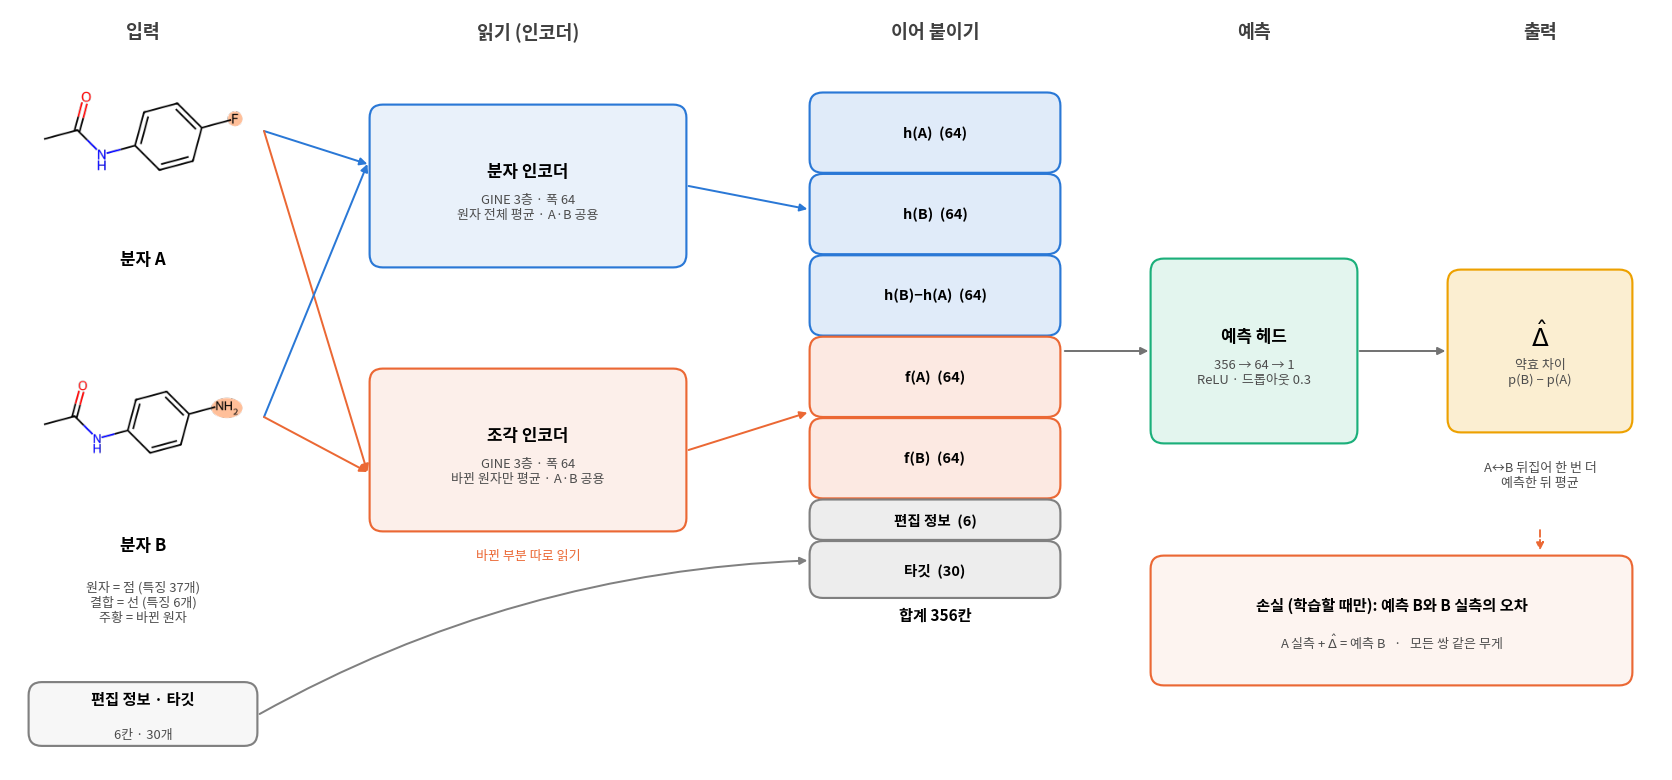

In [20]:
# 모델 구조 한 장 요약 (입력 → 출력). 분자는 RDKit, 글자는 matplotlib (RDKit 폰트엔 한글이 없다)
import io
from matplotlib.patches import FancyBboxPatch
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

def mol_png(smiles, atoms, size=260):
    mol = Chem.MolFromSmiles(smiles); rdDepictor.Compute2DCoords(mol)
    d = rdMolDraw2D.MolDraw2DCairo(size, size)
    d.drawOptions().clearBackground = False
    d.DrawMolecule(mol, highlightAtoms=atoms, highlightAtomColors={i: (1, .75, .6) for i in atoms}, highlightBonds=[])
    d.FinishDrawing()
    return plt.imread(io.BytesIO(d.GetDrawingText()))

fig = plt.figure(figsize=(15, 7))
ax = fig.add_axes([0, 0, 1, 1]); ax.set_xlim(0, 150); ax.set_ylim(0, 69); ax.axis('off')

def box(x, y, w, h, title, sub='', color=C1, fill=0.10, fs=11):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.4,rounding_size=1.2',
                                fc=(*plt.matplotlib.colors.to_rgb(color), fill), ec=color, lw=1.4))
    ax.text(x + w / 2, y + h / 2 + (1.4 if sub else 0), title, ha='center', va='center', fontsize=fs, weight='bold')
    if sub:
        ax.text(x + w / 2, y + h / 2 - 1.9, sub, ha='center', va='center', fontsize=8.5, color='0.3')

def arrow(x0, y0, x1, y1, color='0.45', **kw):
    ax.annotate('', (x1, y1), (x0, y0), arrowprops=dict(arrowstyle='-|>', color=color, lw=1.3, shrinkA=0, shrinkB=0, **kw))

def stage(x, text):
    ax.text(x, 66.5, text, ha='center', fontsize=12, weight='bold', color='0.25')

stage(12, '입력'); stage(47, '읽기 (인코더)'); stage(84, '이어 붙이기'); stage(113, '예측'); stage(139, '출력')

# ── 입력: 실제 분자쌍 (바뀐 원자 주황)
for y, smi, hl, name in [(48, 'CC(=O)Nc1ccc(F)cc1', [8], '분자 A'), (22, 'CC(=O)Nc1ccc(N)cc1', [8], '분자 B')]:
    ax.imshow(mol_png(smi, hl), extent=(2, 22, y, y + 20), zorder=2)
    ax.text(12, y - 0.8, name, ha='center', va='top', fontsize=11, weight='bold')
ax.text(12, 17.2, f'원자 = 점 (특징 {N_ATOM}개)\n결합 = 선 (특징 {N_BOND}개)\n주황 = 바뀐 원자', ha='center', va='top', fontsize=8.5, color='0.3')
box(2, 2.5, 20, 5, '편집 정보 · 타깃', f'{N_EDIT}칸 · {len(DEV_TARGETS)}개', color='0.5', fill=0.06, fs=10)

# ── 인코더 두 개 (A, B가 같은 인코더를 함께 쓴다)
box(33, 46, 28, 14, '분자 인코더', f'GINE {LAYERS}층 · 폭 {HIDDEN}\n원자 전체 평균 · A·B 공용', color=C1)
box(33, 22, 28, 14, '조각 인코더', f'GINE {LAYERS}층 · 폭 {HIDDEN}\n바뀐 원자만 평균 · A·B 공용', color=C2)
ax.text(47, 20, '바뀐 부분 따로 읽기', ha='center', va='top', fontsize=8.5, color=C2, style='italic')
for y0 in (58, 32):          # A, B 둘 다 두 인코더로
    arrow(23, y0, 32.4, 55, color=C1); arrow(23, y0, 32.4, 27, color=C2)

# ── 이어 붙이기: 7조각
parts = [('h(A)', HIDDEN, C1), ('h(B)', HIDDEN, C1), ('h(B)−h(A)', HIDDEN, C1),
         ('f(A)', HIDDEN, C2), ('f(B)', HIDDEN, C2), ('편집 정보', N_EDIT, '0.5'), ('타깃', len(DEV_TARGETS), '0.5')]
n_in = sum(n for _, n, _ in parts)
y, mid = 62, {}
for name, n, c in parts:
    h = 3.4 + 4.0 * n / HIDDEN
    box(73, y - h, 22, h - 0.9, f'{name}  ({n})', color=c, fill=0.14, fs=9.5)
    mid.setdefault(c, []).append(y - h / 2)
    y -= h
ax.text(84, y - 1.2, f'합계 {n_in}칸', ha='center', va='top', fontsize=10, weight='bold')
arrow(61.6, 53, 72.4, np.mean(mid[C1]), color=C1); arrow(61.6, 29, 72.4, np.mean(mid[C2]), color=C2)
arrow(22.6, 5, 72.4, y + 3, color='0.5', connectionstyle='arc3,rad=-0.12')

# ── 예측 헤드
box(104, 30, 18, 16, '예측 헤드', f'{n_in} → {HIDDEN} → 1\nReLU · 드롭아웃 {DROPOUT}', color=C3, fill=0.12)
arrow(95.8, 38, 103.4, 38)

# ── 출력
box(131, 31, 16, 14, r'$\hat{\Delta}$', '약효 차이\np(B) − p(A)', color=C4, fill=0.18, fs=16)
arrow(122.6, 38, 130.4, 38)
ax.text(139, 28, 'A↔B 뒤집어 한 번 더\n예측한 뒤 평균', ha='center', va='top', fontsize=8.5, color='0.3')

# ── 학습 신호
box(104, 8, 43, 11, '손실 (학습할 때만): 예측 B와 B 실측의 오차',
    r'A 실측 + $\hat{\Delta}$ = 예측 B   ·   모든 쌍 같은 무게', color=C2, fill=0.07, fs=10)
ax.annotate('', (139, 19.6), (139, 22.0), arrowprops=dict(arrowstyle='-|>', color=C2, lw=1.2, ls='--'))
plt.show()

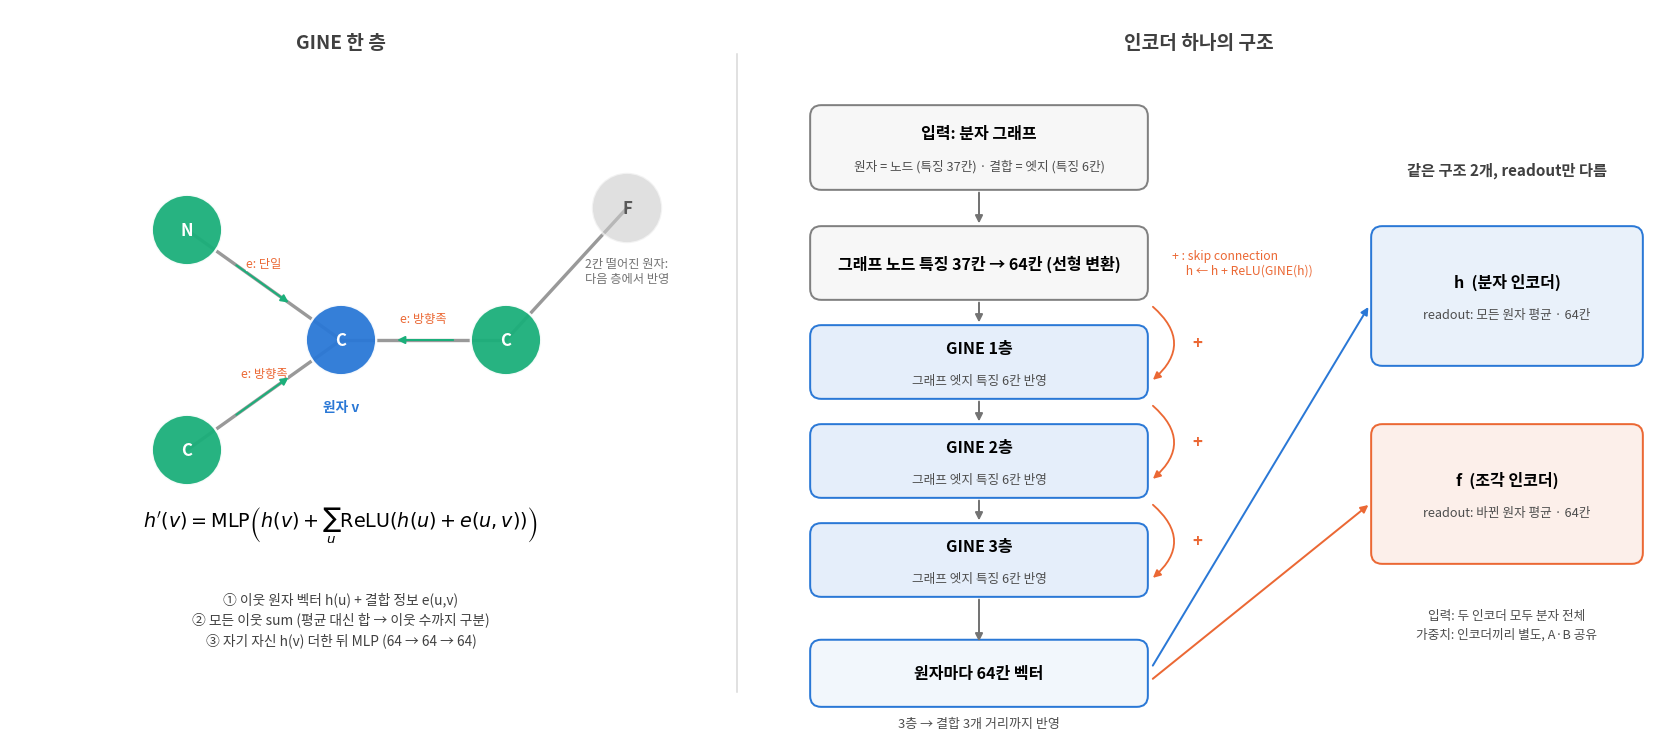

In [21]:
# GINE 인코더 한 층이 하는 일(왼쪽)과 층을 쌓는 방식(오른쪽)
from matplotlib.patches import FancyBboxPatch, Circle

fig = plt.figure(figsize=(15, 6.6))
ax = fig.add_axes([0, 0, 1, 1]); ax.set_xlim(0, 150); ax.set_ylim(0, 66); ax.axis('off')

def box(x, y, w, h, title, sub='', color=C1, fill=0.10, fs=10.5):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.35,rounding_size=1.0',
                                fc=(*plt.matplotlib.colors.to_rgb(color), fill), ec=color, lw=1.3))
    ax.text(x + w / 2, y + h / 2 + (1.3 if sub else 0), title, ha='center', va='center', fontsize=fs, weight='bold')
    if sub:
        ax.text(x + w / 2, y + h / 2 - 1.7, sub, ha='center', va='center', fontsize=8.3, color='0.3')

def arrow(x0, y0, x1, y1, color='0.45', **kw):
    ax.annotate('', (x1, y1), (x0, y0), arrowprops=dict(arrowstyle='-|>', color=color, lw=1.3, shrinkA=0, shrinkB=0, **kw))

# ── 왼쪽: 한 층에서 원자 v가 이웃 정보를 모으는 모습
ax.text(30, 62.5, 'GINE 한 층', ha='center', fontsize=12.5, weight='bold', color='0.25')
pos = {'v': (30, 36), 'u1': (16, 46), 'u2': (16, 26), 'u3': (45, 36), 'w': (56, 48)}
lab = {'v': 'C', 'u1': 'N', 'u2': 'C', 'u3': 'C', 'w': 'F'}
for a, b, kind in [('v', 'u1', '단일'), ('v', 'u2', '방향족'), ('v', 'u3', '방향족'), ('u3', 'w', '단일')]:
    (x0, y0), (x1, y1) = pos[a], pos[b]
    ax.plot([x0, x1], [y0, y1], color='0.6', lw=2.2, zorder=1)
    if b != 'w':
        ax.text((x0 + x1) / 2, (y0 + y1) / 2 + 1.6, f'e: {kind}', fontsize=8, color=C2, ha='center',
                bbox=dict(fc='white', ec='none', pad=0.3))
for k, (x, y) in pos.items():
    c = C1 if k == 'v' else ('0.8' if k == 'w' else C3)
    ax.add_patch(Circle((x, y), 3.2, fc=c, ec='white', lw=1.5, zorder=3, alpha=0.95 if k != 'w' else 0.6))
    ax.text(x, y, lab[k], ha='center', va='center', fontsize=11, weight='bold', color='white' if k != 'w' else '0.35', zorder=4)
for k in ('u1', 'u2', 'u3'):
    (x0, y0), (x1, y1) = pos[k], pos['v']
    arrow(x0 + (x1 - x0) * 0.32, y0 + (y1 - y0) * 0.32, x0 + (x1 - x0) * 0.66, y0 + (y1 - y0) * 0.66, color=C3)
ax.text(30, 30.5, '원자 v', ha='center', va='top', fontsize=9, color=C1, weight='bold')
ax.text(56, 43.5, '2칸 떨어진 원자:\n다음 층에서 반영', ha='center', va='top', fontsize=8, color='0.45')
ax.text(30, 19, r"$h'(v) = \mathrm{MLP}\left( h(v) + \sum_{u} \mathrm{ReLU}\left( h(u) + e(u,v) \right) \right)$",
        ha='center', fontsize=12.5)
ax.text(30, 13.2, '① 이웃 원자 벡터 h(u) + 결합 정보 e(u,v)\n'
                  '② 모든 이웃 sum (평균 대신 합 → 이웃 수까지 구분)\n'
                  '③ 자기 자신 h(v) 더한 뒤 MLP (64 → 64 → 64)', ha='center', va='top', fontsize=9, color='0.25',
        linespacing=1.5)

ax.plot([66, 66], [4, 62], color='0.85', lw=1)

# ── 오른쪽: 층 쌓기
ax.text(108, 62.5, '인코더 하나의 구조', ha='center', fontsize=12.5, weight='bold', color='0.25')
x0, w = 73, 30
box(x0, 50, w, 7, f'입력: 분자 그래프', f'원자 = 노드 (특징 {N_ATOM}칸) · 결합 = 엣지 (특징 {N_BOND}칸)', color='0.5', fill=0.06)
arrow(x0 + w / 2, 49.4, x0 + w / 2, 46.6)
box(x0, 40, w, 6, f'그래프 노드 특징 {N_ATOM}칸 → {HIDDEN}칸 (선형 변환)', color='0.5', fill=0.06)
ys = [31, 22, 13]
prev = 39.4
for k, y in enumerate(ys, 1):
    arrow(x0 + w / 2, prev, x0 + w / 2, y + 6.6)
    box(x0, y, w, 6, f'GINE {k}층', f'그래프 엣지 특징 {N_BOND}칸 반영', color=C1, fill=0.12)
    # 잔차 연결: 입력을 그대로 옆으로 돌려 더한다
    ax.annotate('', (x0 + w + 0.6, y + 1.2), (x0 + w + 0.6, y + 8.2),
                arrowprops=dict(arrowstyle='-|>', color=C2, lw=1.2, connectionstyle='arc3,rad=-0.6'))
    ax.text(x0 + w + 4.4, y + 4.7, '+', fontsize=11, color=C2, weight='bold', va='center')
    prev = y - 0.6
ax.text(x0 + w + 2.5, 43, '+ : skip connection\n     h ← h + ReLU(GINE(h))', fontsize=8, color=C2, va='center')
arrow(x0 + w / 2, prev, x0 + w / 2, 8.6)
box(x0, 3, w, 5.4, f'원자마다 {HIDDEN}칸 벡터', color=C1, fill=0.06)
ax.text(x0 + w / 2, 0.8, f'{LAYERS}층 → 결합 {LAYERS}개 거리까지 반영', ha='center', fontsize=8.5, color='0.3')

# 두 인코더가 이 구조를 각각 갖는다
box(124, 34, 24, 12, 'h  (분자 인코더)', 'readout: 모든 원자 평균 · 64칸', color=C1, fill=0.10)
box(124, 16, 24, 12, 'f  (조각 인코더)', 'readout: 바뀐 원자 평균 · 64칸', color=C2, fill=0.10)
ax.text(136, 51, '같은 구조 2개, readout만 다름', ha='center', fontsize=10, weight='bold', color='0.25')
ax.text(136, 11.5, '입력: 두 인코더 모두 분자 전체\n가중치: 인코더끼리 별도, A·B 공유',
        ha='center', va='top', fontsize=8.3, color='0.3', linespacing=1.45)
arrow(103.8, 6.4, 123.4, 39, color=C1)
arrow(103.8, 5.2, 123.4, 21, color=C2)
plt.show()

In [22]:
class GNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.inp = nn.Linear(N_ATOM, HIDDEN)
        self.convs = nn.ModuleList(GINEConv(nn.Sequential(nn.Linear(HIDDEN, HIDDEN), nn.ReLU(), nn.Linear(HIDDEN, HIDDEN)), edge_dim=N_BOND)
                                   for _ in range(LAYERS))

    def forward(self, g):
        h = self.inp(g.x)
        for conv in self.convs:
            h = h + F.relu(conv(h, g.edge_index, g.edge_attr))
        return h  # 원자별 벡터

def masked_mean(h, g):
    m = g.mask.float().unsqueeze(1)
    return global_add_pool(h * m, g.batch, g.num_graphs) / global_add_pool(m, g.batch, g.num_graphs).clamp(min=1)

class PairModel(nn.Module):
    """타깃 one-hot을 입력에 넣는다. 30개 타깃에서는 고유 분자 35,633개 중 9,507개(26.7%)가
    2개 이상 타깃에 등장하므로, 타깃 정보가 없으면 같은 쌍이 서로 다른 Δ를 갖는 것을 구분할 수 없다.
    use_frag / use_edit = False면 조각 인코더 / 편집 정보를 빼고 학습한다 (■2 ablation)"""
    def __init__(self, use_frag=None, use_edit=None):
        super().__init__()
        self.use_frag = USE_FRAG if use_frag is None else use_frag
        self.use_edit = USE_EDIT if use_edit is None else use_edit
        self.mol = GNN()
        self.frag = GNN() if self.use_frag else None
        n_in = (5 if self.use_frag else 3) * HIDDEN + (N_EDIT if self.use_edit else 0) + len(DEV_TARGETS)
        self.head = nn.Sequential(nn.Linear(n_in, HIDDEN), nn.ReLU(), nn.Dropout(DROPOUT), nn.Linear(HIDDEN, 1))

    def forward(self, ga, gb, edit, tgt):
        ha, hb = global_mean_pool(self.mol(ga), ga.batch), global_mean_pool(self.mol(gb), gb.batch)
        parts = [ha, hb, hb - ha]
        if self.use_frag:
            parts += [masked_mean(self.frag(ga), ga), masked_mean(self.frag(gb), gb)]
        if self.use_edit:
            parts.append(edit)   # 편집 정보 6칸 (multi-hot + 정규화 값)
        parts.append(F.one_hot(tgt, len(DEV_TARGETS)).float())
        return self.head(torch.cat(parts, 1)).squeeze(1)

def forward_pred(model, loader):
    model.eval()
    with torch.no_grad():
        return torch.cat([model(ga.to(DEVICE), gb.to(DEVICE), e.to(DEVICE), t.to(DEVICE)).cpu()
                          for ga, gb, e, t, _ in loader]).numpy()

def loaders(df, gdict=None):
    """(정방향, 역방향) loader 한 쌍"""
    return (DataLoader(samples(df, gdict=gdict), 1024, collate_fn=collate),
            DataLoader(samples(df, reverse=True, gdict=gdict), 1024, collate_fn=collate))

def predict(model, lds):
    """양방향 평균 Δ̂ = (Δ̂(A,B) − Δ̂(B,A)) / 2.
    모델은 반대칭 Δ̂(B,A) = −Δ̂(A,B) 를 정확히 지키지 않으므로, 평균이 그 어긋남만큼 오차를 깎는다"""
    return (forward_pred(model, lds[0]) - forward_pred(model, lds[1])) / 2


def build(pset, gdict=None):
    """한 설정의 loader 묶음을 만든다. gdict: 쓸 그래프 묶음 (기본 graphs)"""
    tr = pset[pset.split == 'train']
    va = pset[pset.split.str.startswith('val')]
    # num_workers=8: 실측 배치당 68.7ms → 55.1ms. 16은 과다구독으로 오히려 느리다
    loader = DataLoader(samples(tr, both_directions=True, gdict=gdict), BATCH, shuffle=True,
                        collate_fn=collate, num_workers=8, persistent_workers=True, pin_memory=True)
    # 학습 곡선용: 학습 쌍을 검증과 같은 규모로 고정 추출 (두 곡선의 격차를 과적합으로 읽기 위해)
    te = tr.sample(len(va), random_state=SEED)
    return dict(train_loader=loader, val=va, val_lds=loaders(va, gdict), all_lds=loaders(pset, gdict),
                train_eval=te, train_eval_lds=loaders(te, gdict))

def scores(df, lds, model):
    """(전체, cliff, non-cliff) RMSE"""
    p = predict(model, lds)
    m = df.is_cliff.values
    return rmse(p, df.delta), rmse(p[m], df.delta[m]), rmse(p[~m], df.delta[~m])

def train(seed, B, tag, make_model=None):
    # 파일 이름의 a0은 손실 가중치 실험 때 붙인 것. 바꾸면 학습된 가중치를 못 찾으므로 그대로 둔다
    path = f'{RUNS}/gnn_a0_{tag}_seed{seed}.pt'
    hist_path = f'{RUNS}/hist_a0_{tag}_seed{seed}.csv'
    torch.manual_seed(seed)
    model = (make_model or PairModel)().to(DEVICE)
    if os.path.exists(path) and os.path.exists(hist_path):
        model.load_state_dict(torch.load(path))   # 캐시 사용 — 로그에 남기지 않는다
        return model
    hist = []
    # 사전학습 인코더는 층마다 학습률이 다를 수 있다 (param_groups가 있으면 사용)
    opt = torch.optim.Adam(model.param_groups() if hasattr(model, 'param_groups') else model.parameters(), lr=LR, weight_decay=WD)
    best, best_state, wait = float('inf'), None, 0
    for epoch in range(EPOCHS):
        model.train()
        for ga, gb, e, t, y in B['train_loader']:
            ga, gb, e, t, y = ga.to(DEVICE), gb.to(DEVICE), e.to(DEVICE), t.to(DEVICE), y.to(DEVICE)
            pa, pb = y[:, 0], y[:, 1]                       # A 실측, B 실측
            b_hat = pa + model(ga, gb, e, t)                # 기준 분자 A 실측 + 예측 Δ = 예측 B
            loss = ((b_hat - pb) ** 2).mean()               # 예측 B와 B 실측의 오차
            opt.zero_grad(); loss.backward(); opt.step()
        score, cliff, noncl = scores(B['val'], B['val_lds'], model)
        tr_, tr_cliff, tr_noncl = scores(B['train_eval'], B['train_eval_lds'], model)
        bal = (cliff + noncl) / 2
        hist.append(dict(epoch=epoch, train=tr_, train_cliff=tr_cliff, train_noncliff=tr_noncl,
                         val=score, val_cliff=cliff, val_noncliff=noncl, val_bal=bal))
        stop = bal if STOP_METRIC == 'bal' else score   # 조기 종료 지표
        if stop < best:
            best, wait = stop, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
        if epoch % 5 == 0 or wait >= PATIENCE:
            log(f'{tag[:6]} s={seed} epoch={epoch} val_rmse={score:.3f} val_cliff={cliff:.3f} best={best:.3f}')
        if wait >= PATIENCE:
            break
    model.load_state_dict(best_state)
    # 끝까지 학습한 경우에만 저장 → 중간에 끊겨도 캐시가 오염되지 않는다
    key = 'val_bal' if STOP_METRIC == 'bal' else 'val'
    pd.DataFrame(hist).assign(best_epoch=int(np.argmin([h[key] for h in hist]))).to_csv(hist_path, index=False)
    torch.save(best_state, path)
    return model

import glob

def pred_cache(prefix, tag, files):
    """가중치·학습 기록이 모두 있을 때만 예측값 캐시 경로를 준다.
    이름에 그 파일들의 최신 수정 시각을 넣어, 다시 학습하면 옛 예측값을 쓰지 않는다"""
    if not all(os.path.exists(f) for f in files):
        return None
    return f'{RUNS}/{prefix}_{tag}_{int(max(os.path.getmtime(f) for f in files))}.pkl'

def save_cache(path, df):
    for old in glob.glob(f'{path.rsplit("_", 1)[0]}_*.pkl'):   # 같은 태그의 옛 캐시는 지운다
        os.remove(old)
    df.to_pickle(path)

# 반대칭 확인 (■1): 무작위 초기 모델로 Δ̂(a,b) + Δ̂(b,a) = 0 과 Δ̂(x,x) = 0 (편집 정보의 추가↔삭제 교환이 맞는지)
_chk = pairs_all[pairs_all.frag_available == 1].sample(64, random_state=SEED) if 'pairs_all' in globals() else pairs.sample(64, random_state=SEED)
_rev = _chk.assign(i=_chk.j, j=_chk.i, atoms_a=_chk.atoms_b, atoms_b=_chk.atoms_a, n_insert=_chk.n_delete, n_delete=_chk.n_insert, delta=-_chk.delta)
_same = _chk.assign(j=_chk.i, atoms_b=_chk.atoms_a, n_insert=0, n_delete=0)
_m = PairModel().to(DEVICE).eval()
_d1, _d2, _d0 = (predict(_m, loaders(x)) for x in (_chk, _rev, _same))
assert np.abs(_d1 + _d2).max() < 1e-5 and np.abs(_d0).max() < 1e-5, (np.abs(_d1 + _d2).max(), np.abs(_d0).max())
print(f'반대칭 확인: max|Δ̂(a,b)+Δ̂(b,a)| = {np.abs(_d1 + _d2).max():.1e}, max|Δ̂(x,x)| = {np.abs(_d0).max():.1e}')

# 학습은 유사 쌍 전부로 한다 (평가 쌍 고르기는 11번)
KEY = ['target', 'i', 'j']
TAGS = {}
for setting, pset in PAIRSETS.items():
    tag = f't{len(DEV_TARGETS)}_h{HIDDEN}_dr{DROPOUT}_wd{WD}_exp{1 if setting == "all" else 0}_anchored'   # 검증 쌍에서 hard 제외
    tag += '_v3'   # ■3: 분자 split을 타깃 전체에서 하나로 (타깃 간 누수 제거). ■1: 쌍 판정 v2 + 편집 정보 6칸
    tag += f'_cap{MASK_CAP}' if MASK_CAP is not None else ''   # 큰 조각 마스크 상한 조건
    tag += ('' if USE_FRAG else '_nofrag') + ('' if USE_EDIT else '_noedit') + ('_nonchanged' if DROP_NCHANGED else '')   # ablation 조건
    tag += '_stopbal' if STOP_METRIC == 'bal' else ''   # 조기 종료 지표가 다르면 다른 가중치
    TAGS[setting] = tag
    cols = [f'pred_gnn_a0_s{s}' for s in SEEDS] + ['pred_gnn_a0_fwd']
    files = [f'{RUNS}/{k}_a0_{tag}_seed{s}.{x}' for s in SEEDS for k, x in [('gnn', 'pt'), ('hist', 'csv')]]
    cache = pred_cache('preds', tag, files)
    if cache and os.path.exists(cache):
        # 예측값 캐시: 학습도 예측도 건너뛴다 (그림·표만 고칠 때 수 분)
        cached = pd.read_pickle(cache)
        assert (cached[KEY].values == pset[KEY].values).all(), '쌍 순서가 캐시와 다르다'
        for col in cols:
            pset[col] = cached[col].values
        log(f'[{setting}] 예측값 캐시 사용: {os.path.basename(cache)}')
    else:
        B = build(pset)
        log(f'[{setting}] 학습 쌍 {len(B["train_loader"].dataset):,} | 검증 {len(B["val"]):,} | 평가 전체 {len(pset):,}')
        for s in SEEDS:
            m = train(s, B, tag)
            pset[f'pred_gnn_a0_s{s}'] = predict(m, B['all_lds'])
            if s == SEEDS[0]:
                pset['pred_gnn_a0_fwd'] = forward_pred(m, B['all_lds'][0])
        save_cache(pred_cache('preds', tag, files), pset[KEY + cols])

반대칭 확인: max|Δ̂(a,b)+Δ̂(b,a)| = 1.9e-08, max|Δ̂(x,x)| = 7.5e-09
[all] 예측값 캐시 사용: preds_t30_h64_dr0.3_wd0.0001_exp1_anchored_v2_1791291017.pkl


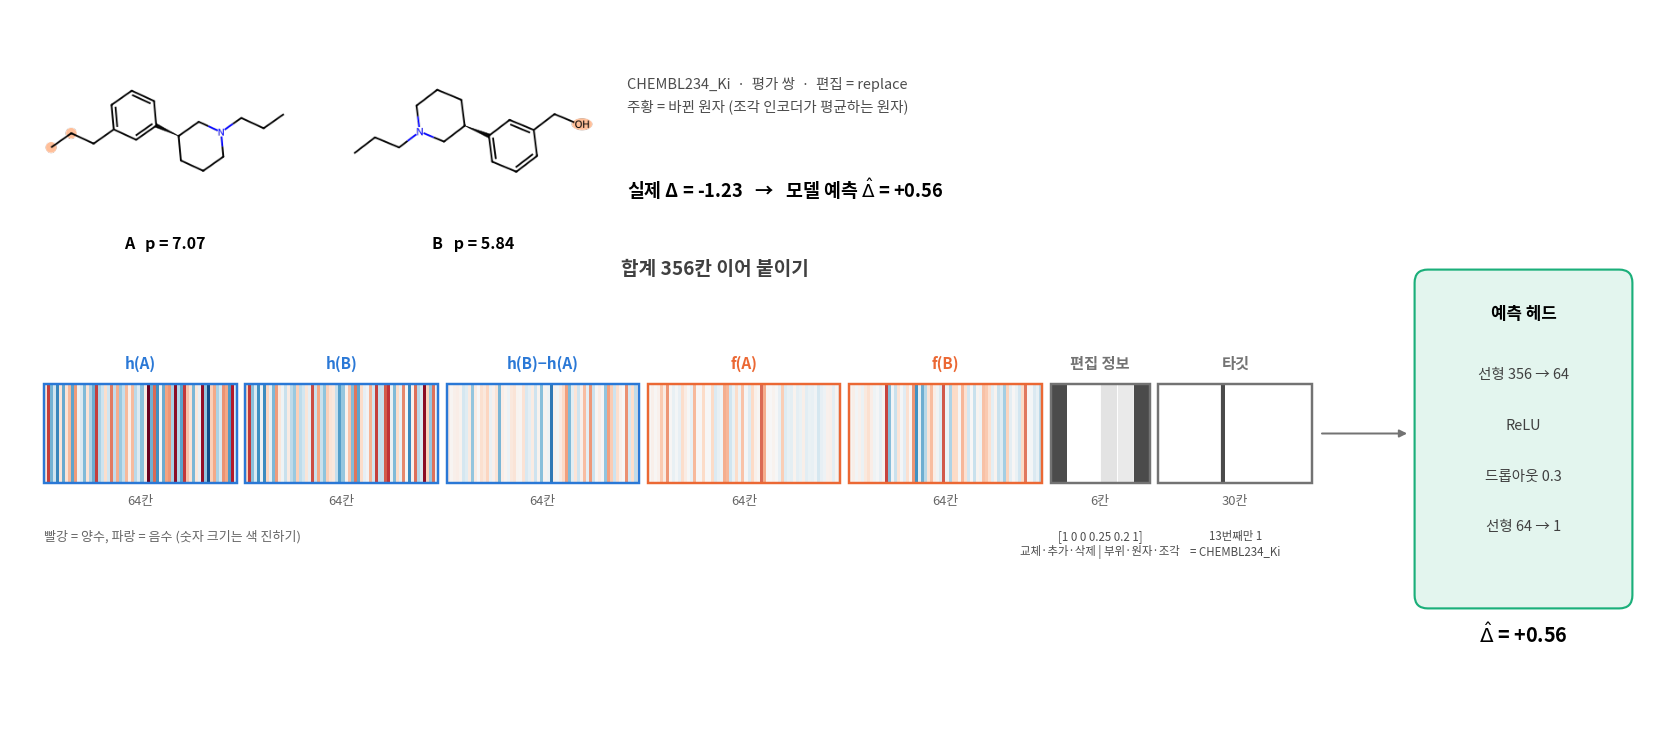

In [23]:
# 이어 붙이기 예시: 실제 평가 쌍 하나를 학습된 쌍 모델(유사 쌍 전부, α=0, 시드 0)에 넣었을 때의 입력 벡터
import io
from matplotlib.patches import FancyBboxPatch
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

_cand = pairs[(pairs.split == 'test') & (pairs.edit == 'replace') & pairs.is_cliff
              & (pairs.smiles_a.str.len() < 40) & (pairs.smiles_b.str.len() < 40)
              & (pairs.atoms_a.map(len).between(1, 3)) & (pairs.atoms_b.map(len).between(1, 3))]   # 작은 치환기 교체만
ex = _cand.sample(1, random_state=3).iloc[0]

_m = PairModel().to(DEVICE)
_m.load_state_dict(torch.load(f'{RUNS}/gnn_a0_{TAGS["all"]}_seed{SEEDS[0]}.pt', map_location=DEVICE)); _m.eval()
with torch.no_grad():
    ga, gb, e, t, _ = collate(samples(pd.DataFrame([ex])))
    ga, gb, e, t = ga.to(DEVICE), gb.to(DEVICE), e.to(DEVICE), t.to(DEVICE)
    ha, hb = global_mean_pool(_m.mol(ga), ga.batch), global_mean_pool(_m.mol(gb), gb.batch)
    fa, fb = masked_mean(_m.frag(ga), ga), masked_mean(_m.frag(gb), gb)
    parts = [ha, hb, hb - ha, fa, fb, e, F.one_hot(t, len(DEV_TARGETS)).float()]
    vec = torch.cat(parts, 1)[0].cpu().numpy()
    pred = _m.head(torch.cat(parts, 1)).item()
    hidden = _m.head[1](_m.head[0](torch.cat(parts, 1)))[0].cpu().numpy()

def _img(smi, hl, size=300):
    mol = Chem.MolFromSmiles(smi); rdDepictor.Compute2DCoords(mol)
    d = rdMolDraw2D.MolDraw2DCairo(size, int(size * 0.75))
    d.drawOptions().clearBackground = False
    d.DrawMolecule(mol, highlightAtoms=hl, highlightAtomColors={i: (1, .75, .6) for i in hl}, highlightBonds=[])
    d.FinishDrawing()
    return plt.imread(io.BytesIO(d.GetDrawingText()))

fig = plt.figure(figsize=(15, 6.6))
ax = fig.add_axes([0, 0, 1, 1]); ax.set_xlim(0, 150); ax.set_ylim(4, 70); ax.axis('off')
ax.imshow(_img(ex.smiles_a, ex.atoms_a), extent=(2, 26, 50, 68), zorder=2)
ax.imshow(_img(ex.smiles_b, ex.atoms_b), extent=(30, 54, 50, 68), zorder=2)
ax.text(14, 49.5, f'A   p = {ex.p_a:.2f}', ha='center', va='top', fontsize=10.5, weight='bold')
ax.text(42, 49.5, f'B   p = {ex.p_b:.2f}', ha='center', va='top', fontsize=10.5, weight='bold')
ax.text(56, 64, f'{ex.target}  ·  평가 쌍  ·  편집 = {ex.edit}\n주황 = 바뀐 원자 (조각 인코더가 평균하는 원자)',
        fontsize=9.5, color='0.3', va='top', linespacing=1.6)
ax.text(56, 55, f'실제 Δ = {ex.delta:+.2f}   →   모델 예측 Δ̂ = {pred:+.2f}'.replace('Δ̂', r'$\hat{\Delta}$'),
        fontsize=12, weight='bold', va='top')

# 입력 벡터 막대: 칸 너비를 조각 크기에 비례시키되 원-핫 부분은 보이게 넓힌다
SEG = [('h(A)', 64, C1), ('h(B)', 64, C1), ('h(B)−h(A)', 64, C1), ('f(A)', 64, C2), ('f(B)', 64, C2),
       ('편집 정보', N_EDIT, '0.45'), ('타깃', len(DEV_TARGETS), '0.45')]
x, y0, H, start = 3.0, 27, 9, 0
lim = np.abs(vec[:5 * HIDDEN]).max()
for name, n, c in SEG:
    w = 17.5 if n == HIDDEN else (9 if n == N_EDIT else 14)
    seg = vec[start:start + n]
    if n == HIDDEN:
        ax.imshow(seg[None, :], extent=(x, x + w, y0, y0 + H), cmap='RdBu_r', vmin=-lim, vmax=lim, aspect='auto', zorder=2)
    else:
        ax.imshow(seg[None, :], extent=(x, x + w, y0, y0 + H), cmap='Greys', vmin=0, vmax=max(1.3, float(seg.max()) * 1.3), aspect='auto', zorder=2)
        for k in range(n + 1):
            ax.plot([x + w * k / n] * 2, [y0, y0 + H], color='white', lw=0.6, zorder=3)
    ax.add_patch(plt.Rectangle((x, y0), w, H, fill=False, ec=c, lw=1.6, zorder=4))
    ax.text(x + w / 2, y0 + H + 1.2, f'{name}', ha='center', va='bottom', fontsize=10, weight='bold', color=c)
    ax.text(x + w / 2, y0 - 1.0, f'{n}칸', ha='center', va='top', fontsize=8.5, color='0.4')
    if name == '편집 정보':   # multi-hot 3칸(0/1) + 정규화 값 3칸
        ax.text(x + w / 2, y0 - 4.2, '[' + ' '.join(f'{v:.2g}' for v in seg) + ']\n교체·추가·삭제 | 부위·원자·조각',
                ha='center', va='top', fontsize=7.5, color='0.3')
    if name == '타깃':
        ax.text(x + w / 2, y0 - 4.2, f'{int(seg.argmax()) + 1}번째만 1\n= {ex.target}', ha='center', va='top', fontsize=7.5, color='0.3')
    x += w + 0.8
    start += n
assert start == len(vec)
ax.text(3, y0 - 4.2, '빨강 = 양수, 파랑 = 음수 (숫자 크기는 색 진하기)', fontsize=8.5, color='0.4', va='top')
ax.text(64, 46, f'합계 {len(vec)}칸 이어 붙이기', ha='center', fontsize=12.5, weight='bold', color='0.25')

# 헤드
hx = 128
ax.annotate('', (hx - 0.8, y0 + H / 2), (x - 0.2, y0 + H / 2), arrowprops=dict(arrowstyle='-|>', color='0.45', lw=1.3))
ax.add_patch(FancyBboxPatch((hx, 16), 19, 30, boxstyle='round,pad=0.4,rounding_size=1.2', fc=(*plt.matplotlib.colors.to_rgb(C3), .12), ec=C3, lw=1.4))
ax.text(hx + 9.5, 42, '예측 헤드', ha='center', fontsize=11, weight='bold')
for k, s in enumerate([f'선형 {len(vec)} → {HIDDEN}', 'ReLU', f'드롭아웃 {DROPOUT}', f'선형 {HIDDEN} → 1']):
    ax.text(hx + 9.5, 36.5 - k * 4.6, s, ha='center', fontsize=9.5, color='0.25')
ax.text(hx + 9.5, 12.5, r'$\hat{\Delta}$' + f' = {pred:+.2f}', ha='center', fontsize=13, weight='bold')
plt.show()

### 비교군: 분자별 GNN

SVR처럼 **분자 하나씩** 약효를 예측한 뒤 두 값을 뺀다. 인코더는 쌍 모델과 **구조가 똑같은 GINE**이고,
가중치는 가져오지 않고 **처음부터 따로 학습**한다. 입력만 다르다.
이것과 쌍 모델(α=0)을 비교하면 **쌍으로 넣는 것 자체가 도움이 되는지** 알 수 있다.


In [24]:
class MolModel(nn.Module):
    """비교군: 분자 하나 + 타깃 → 약효. 인코더(GNN)와 헤드 크기는 쌍 모델과 같다"""
    def __init__(self):
        super().__init__()
        self.mol = GNN()
        self.head = nn.Sequential(nn.Linear(HIDDEN + len(DEV_TARGETS), HIDDEN), nn.ReLU(), nn.Dropout(DROPOUT), nn.Linear(HIDDEN, 1))

    def forward(self, g, tgt):
        h = global_mean_pool(self.mol(g), g.batch)
        return self.head(torch.cat([h, F.one_hot(tgt, len(DEV_TARGETS)).float()], 1)).squeeze(1)

MOL_PATIENCE = 20   # 한 epoch에 보는 양이 쌍보다 훨씬 적어 쌍 모델(8)보다 길게 기다린다
# 분자는 3.1만 개라 epoch당 학습 횟수가 쌍(13.5만~70만)보다 훨씬 적다. 200에서는 시드 3개 모두
# 상한에 걸려 멈췄다(최적 197~199) → 상한을 넉넉히 두고 patience로 멈춘다
MOL_EPOCHS = 1000
MOLS = pd.concat([load(t).assign(target=t, k=np.arange(len(load(t)))) for t in DEV_TARGETS], ignore_index=True)

def mol_collate(batch):
    g, t, y = zip(*batch)
    return Batch.from_data_list(g), torch.tensor(t), torch.tensor(y, dtype=torch.float32)

def mol_loader(df, shuffle=False, gdict=None):
    gdict = graphs if gdict is None else gdict
    items = [(gdict[t, k], DEV_TARGETS.index(t), p) for t, k, p in zip(df.target, df.k, df.p)]
    if shuffle:   # 학습용: 쌍 모델처럼 일꾼 8개
        return DataLoader(items, BATCH, shuffle=True, collate_fn=mol_collate, num_workers=8, persistent_workers=True)
    return DataLoader(items, 1024, collate_fn=mol_collate)

def mol_predict(model, loader):
    model.eval()
    with torch.no_grad():
        return torch.cat([model(g.to(DEVICE), t.to(DEVICE)).cpu() for g, t, _ in loader]).numpy()

def train_mol(seed, tag, make_model=None, gdict=None):
    """쌍 모델 가중치는 쓰지 않고 새로 학습한다. 파일 이름도 따로라 캐시가 섞이지 않는다"""
    path, hist_path = f'{RUNS}/gnnmol_{tag}_seed{seed}.pt', f'{RUNS}/histmol_{tag}_seed{seed}.csv'
    torch.manual_seed(seed)
    model = (make_model or MolModel)().to(DEVICE)
    if os.path.exists(path) and os.path.exists(hist_path):
        model.load_state_dict(torch.load(path))
        return model
    tr, va = MOLS[MOLS.split == 'train'], MOLS[MOLS.split == 'val']
    tr_loader, va_loader = mol_loader(tr, shuffle=True, gdict=gdict), mol_loader(va, gdict=gdict)
    opt = torch.optim.Adam(model.param_groups() if hasattr(model, 'param_groups') else model.parameters(), lr=LR, weight_decay=WD)
    best, best_state, wait, hist = float('inf'), None, 0, []
    for epoch in range(MOL_EPOCHS):
        model.train()
        for g, t, y in tr_loader:
            g, t, y = g.to(DEVICE), t.to(DEVICE), y.to(DEVICE)
            loss = ((model(g, t) - y) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        score = rmse(mol_predict(model, va_loader), va.p)
        hist.append(dict(epoch=epoch, val=score))
        if score < best:
            best, wait = score, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
        if epoch % 25 == 0 or wait >= MOL_PATIENCE:
            log(f'mol s={seed} epoch={epoch} val_rmse(분자)={score:.3f} best={best:.3f}')
        if wait >= MOL_PATIENCE:
            break
    model.load_state_dict(best_state)
    log(f'mol s={seed} 멈춤 epoch={epoch} (최적 {int(np.argmin([h["val"] for h in hist]))})')
    pd.DataFrame(hist).to_csv(hist_path, index=False)
    torch.save(best_state, path)
    return model

MOL_TAG = f't{len(DEV_TARGETS)}_h{HIDDEN}_l{LAYERS}_dr{DROPOUT}_wd{WD}_ep{MOL_EPOCHS}_v3'   # ■3: split 분자 단위
log(f'[mol] 학습 분자 {(MOLS.split == "train").sum():,} | 검증 분자 {(MOLS.split == "val").sum():,}')
te = (MOLS.split == 'test').values
files = [f'{RUNS}/{k}_{MOL_TAG}_seed{s}.{x}' for s in SEEDS for k, x in [('gnnmol', 'pt'), ('histmol', 'csv')]]
cache = pred_cache('preds_mol', MOL_TAG, files)
if cache and os.path.exists(cache):
    MOL_PRED = pd.read_pickle(cache)
    assert (MOL_PRED[['target', 'k']].values == MOLS[['target', 'k']].values).all(), '분자 순서가 캐시와 다르다'
    log(f'[mol] 예측값 캐시 사용: {os.path.basename(cache)}')
else:
    all_loader = mol_loader(MOLS)
    MOL_PRED = MOLS[['target', 'k']].copy()
    for s in SEEDS:
        MOL_PRED[f's{s}'] = mol_predict(train_mol(s, MOL_TAG), all_loader)
    save_cache(pred_cache('preds_mol', MOL_TAG, files), MOL_PRED)
for s in SEEDS:
    p_ = MOL_PRED[f's{s}'].values
    print(f'시드 {s}: 분자 단위 test RMSE {rmse(p_[te], MOLS.p[te]):.3f}')
    p_ = dict(zip(zip(MOLS.target, MOLS.k), p_))
    for pset in PAIRSETS.values():
        pset[f'pred_gnnmol_s{s}'] = [p_[t, j] - p_[t, i] for t, i, j in zip(pset.target, pset.i, pset.j)]
for pset in PAIRSETS.values():
    pset['pred_gnnmol'] = pset[f'pred_gnnmol_s{SEEDS[0]}']
print(f'참고: SVR 분자 단위 test RMSE {rmse(np.concatenate([mol_pred[t][load(t).split == "test"] for t in DEV_TARGETS]), MOLS.p[te]):.3f}')

[mol] 학습 분자 31,144 | 검증 분자 7,768
[mol] 예측값 캐시 사용: preds_mol_t30_h64_l3_dr0.3_wd0.0001_ep1000_1790834439.pkl
시드 0: 분자 단위 test RMSE 0.828


시드 1: 분자 단위 test RMSE 0.821


시드 2: 분자 단위 test RMSE 0.820


참고: SVR 분자 단위 test RMSE 0.691


In [25]:
# 학습 기록 (runs/train.log). 가중치가 캐시된 경우 이 셀이 실제 학습 과정을 보여준다
print(open(f'{RUNS}/train.log').read()[-3000:])

08 20:03:38 t30_h6 s=1 epoch=30 val_rmse=0.713 val_cliff=1.032 best=0.710
10-08 20:09:14 t30_h6 s=2 epoch=30 val_rmse=0.710 val_cliff=1.085 best=0.705
10-08 20:10:19 t30_h6 s=2 epoch=30 val_rmse=0.706 val_cliff=1.025 best=0.703
10-08 20:11:09 t30_h6 s=0 epoch=30 val_rmse=0.703 val_cliff=1.022 best=0.699
10-08 20:13:12 t30_h6 s=0 epoch=35 val_rmse=0.710 val_cliff=1.019 best=0.702
10-08 20:14:47 t30_h6 s=1 epoch=35 val_rmse=0.699 val_cliff=1.034 best=0.696
10-08 20:20:10 t30_h6 s=1 epoch=35 val_rmse=0.728 val_cliff=1.028 best=0.707
10-08 20:26:27 t30_h6 s=2 epoch=35 val_rmse=0.704 val_cliff=1.019 best=0.704
10-08 20:27:39 t30_h6 s=2 epoch=35 val_rmse=0.704 val_cliff=1.010 best=0.696
10-08 20:28:30 t30_h6 s=0 epoch=35 val_rmse=0.697 val_cliff=1.012 best=0.697
10-08 20:29:31 t30_h6 s=0 epoch=40 val_rmse=0.706 val_cliff=1.034 best=0.702
10-08 20:31:25 t30_h6 s=1 epoch=40 val_rmse=0.692 val_cliff=1.001 best=0.692
10-08 20:32:47 t30_h6 s=0 epoch=41 val_rmse=0.708 val_cliff=1.024 best=0.702
10

## 10. Mole-BERT 학습 (사전학습 인코더)

지금 GINE(폭 64, 3층)은 작고 처음부터 학습한다. 데이터가 적은 타깃이 많아 GNN이 분자를 충분히 배우지 못한다.
그래서 **ZINC 200만 분자로 미리 학습된 Mole-BERT 인코더**(GIN 5층, 폭 300)로 분자·조각 인코더를 바꾼다.
이어 붙이기·헤드·손실·평가는 그대로라, 인코더만 바꾼 효과를 볼 수 있다.

- 사전학습은 활성값 없이 구조만 보는 자기지도 학습이다 (정답 누수 아님). 다만 ZINC에 평가 분자가 있었을 수는 있다
- 인코더는 작은 학습률(1e-4)로 미세조정하고, 헤드는 지금과 같은 학습률(1e-3)
- 같은 인코더를 MoleculeACE 30개 타깃에 쓴 연구(MTPNet, 2025)가 있어 비교하기 좋다

In [26]:
# 사전학습 인코더: Mole-BERT (Xia et al., ICLR 2023). ZINC 200만 분자로 자기지도 사전학습한 GIN 5층 · 폭 300
# 구조는 Hu et al. (2020)의 사전학습 GIN과 같고, 원자를 (원소, 입체) · 결합을 (종류, 방향) 정수로 받는다
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops
from rdkit.Chem.rdchem import ChiralType, BondDir

PT_PATH = f'{RUNS}/pretrained/Mole-BERT.pth'   # https://github.com/junxia97/Mole-BERT (model_gin/Mole-BERT.pth)
PT_DIM, PT_LAYERS, PT_LR = 300, 5, 1e-4          # 인코더는 작은 학습률로 미세조정, 헤드는 LR
PT_CHIRAL = [ChiralType.CHI_UNSPECIFIED, ChiralType.CHI_TETRAHEDRAL_CW, ChiralType.CHI_TETRAHEDRAL_CCW]
PT_BDIR = [BondDir.NONE, BondDir.ENDUPRIGHT, BondDir.ENDDOWNRIGHT]

def _idx(x, choices):
    return choices.index(x) if x in choices else 0

def graph_pt(smiles):
    """Mole-BERT 입력 형식. 원자 순서는 graph()와 같아서 바뀐 원자 표시(mask)를 그대로 쓴다"""
    mol = Chem.MolFromSmiles(smiles)
    x = [[a.GetAtomicNum() - 1, _idx(a.GetChiralTag(), PT_CHIRAL)] for a in mol.GetAtoms()]
    src, dst, edge = [], [], []
    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        f = [_idx(b.GetBondType(), BONDS), _idx(b.GetBondDir(), PT_BDIR)]
        src += [i, j]; dst += [j, i]; edge += [f, f]
    return Data(x=torch.tensor(x, dtype=torch.long), edge_index=torch.tensor([src, dst], dtype=torch.long).reshape(2, -1),
                edge_attr=torch.tensor(edge, dtype=torch.long).reshape(-1, 2))

class PTConv(MessagePassing):
    def __init__(self, dim):
        super().__init__(aggr='add')
        self.mlp = nn.Sequential(nn.Linear(dim, 2 * dim), nn.ReLU(), nn.Linear(2 * dim, dim))
        self.edge_embedding1, self.edge_embedding2 = nn.Embedding(6, dim), nn.Embedding(3, dim)

    def forward(self, x, edge_index, edge_attr):
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))
        loop = torch.zeros(x.size(0), 2, dtype=edge_attr.dtype, device=edge_attr.device); loop[:, 0] = 4   # 자기 연결 결합 종류
        edge_attr = torch.cat([edge_attr, loop])
        return self.propagate(edge_index, x=x, edge_attr=self.edge_embedding1(edge_attr[:, 0]) + self.edge_embedding2(edge_attr[:, 1]))

    def message(self, x_j, edge_attr):
        return x_j + edge_attr

    def update(self, aggr_out):
        return self.mlp(aggr_out)

class MoleBERT(nn.Module):
    """사전학습 가중치를 그대로 불러온다 (strict=True로 이름·크기 모두 일치 확인)"""
    def __init__(self):
        super().__init__()
        self.x_embedding1, self.x_embedding2 = nn.Embedding(120, PT_DIM), nn.Embedding(3, PT_DIM)
        self.gnns = nn.ModuleList(PTConv(PT_DIM) for _ in range(PT_LAYERS))
        self.batch_norms = nn.ModuleList(nn.BatchNorm1d(PT_DIM) for _ in range(PT_LAYERS))
        self.load_state_dict(torch.load(PT_PATH, map_location='cpu'))

    def forward(self, g):
        h = self.x_embedding1(g.x[:, 0]) + self.x_embedding2(g.x[:, 1])
        for k, (conv, bn) in enumerate(zip(self.gnns, self.batch_norms)):
            h = bn(conv(h, g.edge_index, g.edge_attr))
            if k < PT_LAYERS - 1:
                h = F.relu(h)
        return h   # 원자별 벡터 (마지막 층 출력)

class PTPairModel(PairModel):
    """쌍 모델에서 두 인코더만 Mole-BERT로 바꾼다. 이어 붙이기·헤드·손실은 그대로"""
    def __init__(self):
        nn.Module.__init__(self)
        self.use_frag, self.use_edit = True, True   # PairModel.forward가 쓰는 설정 (ablation은 GINE에서만)
        self.mol, self.frag = MoleBERT(), MoleBERT()
        n_in = 5 * PT_DIM + N_EDIT + len(DEV_TARGETS)
        self.head = nn.Sequential(nn.Linear(n_in, HIDDEN), nn.ReLU(), nn.Dropout(DROPOUT), nn.Linear(HIDDEN, 1))

    def param_groups(self):
        enc = list(self.mol.parameters()) + list(self.frag.parameters())
        return [{'params': enc, 'lr': PT_LR}, {'params': self.head.parameters(), 'lr': LR}]

PT_GRAPHS = {(t, k): graph_pt(s) for t in DEV_TARGETS for k, s in enumerate(load(t).smiles)}
assert all(PT_GRAPHS[k].num_nodes == graphs[k].num_nodes for k in graphs), '원자 수가 graph()와 달라 mask를 쓸 수 없다'

PT_TAGS = {}
for setting, pset in PAIRSETS.items():
    tag = f'{TAGS[setting]}_molebert'
    PT_TAGS[setting] = tag
    cols = [f'pred_pt_a0_s{s}' for s in SEEDS]
    files = [f'{RUNS}/{k}_a0_{tag}_seed{s}.{x}' for s in SEEDS for k, x in [('gnn', 'pt'), ('hist', 'csv')]]
    cache = pred_cache('preds_pt', tag, files)
    if cache and os.path.exists(cache):
        cached = pd.read_pickle(cache)
        assert (cached[KEY].values == pset[KEY].values).all(), '쌍 순서가 캐시와 다르다'
        for col in cols:
            pset[col] = cached[col].values
        log(f'[{setting}] Mole-BERT 예측값 캐시 사용: {os.path.basename(cache)}')
    else:
        B = build(pset, gdict=PT_GRAPHS)
        log(f'[{setting}] Mole-BERT 학습 쌍 {len(B["train_loader"].dataset):,} | 검증 {len(B["val"]):,}')
        for s in SEEDS:
            m = train(s, B, tag, make_model=PTPairModel)
            pset[f'pred_pt_a0_s{s}'] = predict(m, B['all_lds'])
        save_cache(pred_cache('preds_pt', tag, files), pset[KEY + cols])
print('Mole-BERT 쌍 모델 파라미터', sum(p.numel() for p in PTPairModel().parameters()))

[all] Mole-BERT 예측값 캐시 사용: preds_pt_t30_h64_dr0.3_wd0.0001_exp1_anchored_v2_molebert_1791424448.pkl


Mole-BERT 쌍 모델 파라미터 3814233


### 비교군: Mole-BERT 분자별

9번의 분자별 GNN과 같은 방식(분자 하나씩 예측한 뒤 빼기)이고, 인코더만 Mole-BERT로 바꾼다.
Mole-BERT 쌍과 비교하면 **사전학습 인코더에서도 쌍으로 넣는 것이 도움이 되는지** 알 수 있다.

In [27]:
# 비교군: Mole-BERT 분자별 — 분자 하나씩 예측한 뒤 빼기. 인코더만 Mole-BERT(사전학습 가중치에서 미세조정)로 바꾼다
class PTMolModel(MolModel):
    def __init__(self):
        nn.Module.__init__(self)
        self.mol = MoleBERT()
        self.head = nn.Sequential(nn.Linear(PT_DIM + len(DEV_TARGETS), HIDDEN), nn.ReLU(), nn.Dropout(DROPOUT), nn.Linear(HIDDEN, 1))

    def param_groups(self):
        return [{'params': self.mol.parameters(), 'lr': PT_LR}, {'params': self.head.parameters(), 'lr': LR}]

PTMOL_TAG = f'{MOL_TAG}_molebert'
# --- 학습·예측
files = [f'{RUNS}/{k}_{PTMOL_TAG}_seed{s}.{x}' for s in SEEDS for k, x in [('gnnmol', 'pt'), ('histmol', 'csv')]]
cache = pred_cache('preds_molpt', PTMOL_TAG, files)
if cache and os.path.exists(cache):
    PTMOL_PRED = pd.read_pickle(cache)
    assert (PTMOL_PRED[['target', 'k']].values == MOLS[['target', 'k']].values).all(), '분자 순서가 캐시와 다르다'
    log(f'[mol] Mole-BERT 분자별 예측값 캐시 사용: {os.path.basename(cache)}')
else:
    loader_ = mol_loader(MOLS, gdict=PT_GRAPHS)
    PTMOL_PRED = MOLS[['target', 'k']].copy()
    for s in SEEDS:
        PTMOL_PRED[f's{s}'] = mol_predict(train_mol(s, PTMOL_TAG, make_model=PTMolModel, gdict=PT_GRAPHS), loader_)
    save_cache(pred_cache('preds_molpt', PTMOL_TAG, files), PTMOL_PRED)
for s in SEEDS:
    p_ = PTMOL_PRED[f's{s}'].values
    print(f'시드 {s}: Mole-BERT 분자별 test RMSE {rmse(p_[te], MOLS.p[te]):.3f}')
    p_ = dict(zip(zip(MOLS.target, MOLS.k), p_))
    for pset in PAIRSETS.values():
        pset[f'pred_ptmol_s{s}'] = [p_[t, j] - p_[t, i] for t, i, j in zip(pset.target, pset.i, pset.j)]

[mol] Mole-BERT 분자별 예측값 캐시 사용: preds_molpt_t30_h64_l3_dr0.3_wd0.0001_ep1000_molebert_1791254132.pkl
시드 0: Mole-BERT 분자별 test RMSE 0.798


시드 1: Mole-BERT 분자별 test RMSE 0.802


시드 2: Mole-BERT 분자별 test RMSE 0.801


## 11. 결과 비교

**쌍 모델은 유사 쌍 전부로 학습했고, 평가는 한 군데만 다른 쌍을 기본으로 본다.** 유사 쌍 전부 평가는 참고로 함께 둔다.
분자별 비교군(SVR 등)은 쌍을 쓰지 않으므로 두 평가에서 같은 모델이다.

| 비교군 | 무엇인가 |
|---|---|
| 항상 0 | 모든 쌍에 Δ̂ = 0 |
| SVR | ECFP4 + 타니모토 SVR, 분자별 예측 후 빼기 |
| GNN 분자별 | 같은 GINE으로 분자별 예측 후 빼기 |
| Mole-BERT 분자별 | 같은 Mole-BERT로 분자별 예측 후 빼기 |
| GINE 쌍 | 9번 쌍 모델 |
| Mole-BERT 쌍 | 10번 사전학습 쌍 모델 |

**앙상블** = 시드 3개의 예측을 평균한 것 (그림에서 빗금). 앙상블이 아닌 칸은 시드마다 따로 잰 오차의 평균이다.

**오차 계산:** 모든 평가 쌍에는 실측값을 아는 학습 분자(A)가 들어 있다. 오차는 **A 실측 + 예측 Δ → 예측 B** 를 만들어
**B 실측과 비교한 RMSE**다. 이 값은 식으로 Δ̂과 실제 Δ의 차이와 같다 ((p_A + Δ̂) − p_B = Δ̂ − Δ). 학습 손실도 같은 방식이다.

**bal** = (cliff RMSE + non-cliff RMSE) / 2. non-cliff 쌍이 훨씬 많아서, 전체 RMSE만 보면 cliff 성능이 묻힌다.
학습을 멈추는 기준은 검증 쌍 전체 RMSE다.


In [28]:
# 평가 쌍 고르기: 쌍 모델은 유사 쌍 전부로 학습했다. 평가는 그중 한 군데만 다른 쌍을 기본으로 본다
for enc in ['gnn', 'pt']:   # 시드 앙상블: 시드 3개의 예측을 평균
    pairs_all[f'pred_{enc}_ens'] = pairs_all[[f'pred_{enc}_a0_s{s}' for s in SEEDS]].mean(axis=1)
RESULTS = {'single': pairs_all[pairs_all.reason == 'pass'].reset_index(drop=True), 'all': pairs_all}
LABEL = {'single': '평가: 한 군데만 다른 쌍', 'all': '평가: 유사 쌍 전부 (참고)'}
PURPLE = '#8c6bc8'   # Mole-BERT 분자별
ENC = {'gnn': 'GINE 쌍', 'pt': 'Mole-BERT 쌍'}

def b_err(d, col):
    """기준 분자 A(실측값을 아는 학습 분자) 실측 + 예측 Δ → 예측 B, 그리고 B 실측과의 차이.
    열의 Δ̂는 쌍 순서 i → j 방향이므로, 학습 분자가 j 쪽이면 부호를 바꿔 j를 기준으로 쓴다"""
    a_is_i = (d.split_a == 'train').values
    pred_b = np.where(a_is_i, d.p_a.values + d[col].values, d.p_b.values - d[col].values)
    true_b = np.where(a_is_i, d.p_b.values, d.p_a.values)
    return pred_b - true_b

def b_rmse(d, col):
    """아는 분자(A) 실측 + Δ̂로 구한 B 활성의 RMSE"""
    return float(np.sqrt(np.mean(b_err(d, col) ** 2)))

def seed_cols(enc):
    return [f'pred_{enc}_a0_s{s}' for s in SEEDS]

def seed_rmse(df, cols, mask=None):
    """열마다(시드마다) RMSE 배열"""
    d = df if mask is None else df[mask]
    return np.array([b_rmse(d, c) for c in cols])

def grouped(df):
    """행 앞에 구분(기준선 / GINE 쌍 / Mole-BERT 쌍)을 붙여, 표에서 모델 묶음이 한눈에 보이게 한다"""
    g = ['기준선' if '분자별' in str(i) else next((v for k, v in [('GINE', 'GINE 쌍'), ('Mole-BERT', 'Mole-BERT 쌍')]
                                                  if str(i).startswith(k)), '기준선') for i in df.index]
    return df.set_index(pd.MultiIndex.from_arrays([g, df.index], names=['구분', '모델']))

# 확인: "A 실측 + Δ̂ vs B 실측" 오차는 "Δ̂ vs 실제 Δ" 오차와 식으로 같다 ((p_A + Δ̂) − p_B = Δ̂ − Δ)
for _p in RESULTS.values():
    _t = _p[_p.split == 'test']
    assert abs(b_rmse(_t, 'pred_svr') - rmse(_t.pred_svr, _t.delta)) < 1e-9

# 비교군: (이름, 열 목록, 색, 빗금). 열이 여러 개면 시드마다 따로 잰 뒤 평균, 하나면 그대로 잰다
COMPARE = {}
for st in RESULTS:
    cmp = [('항상 0', ['pred_zero'], MUTED, ''), ('SVR', ['pred_svr'], C2, ''),
           ('GNN 분자별', [f'pred_gnnmol_s{s}' for s in SEEDS], C4, ''),
           ('Mole-BERT 분자별', [f'pred_ptmol_s{s}' for s in SEEDS], PURPLE, '')]
    for enc, col in [('gnn', C3), ('pt', C1)]:
        cmp += [(ENC[enc], seed_cols(enc), col, ''), (f'{ENC[enc]} 앙상블', [f'pred_{enc}_ens'], col, '//')]
    COMPARE[st] = cmp


### 모델 비교

막대 위 수염은 시드 3개의 흔들림, 빗금은 시드 앙상블이다.
노란 점선은 분자별 GNN의 높이다. 쌍 모델 막대가 점선보다 낮으면 **쌍으로 넣는 쪽이 낫다**는 뜻이다.

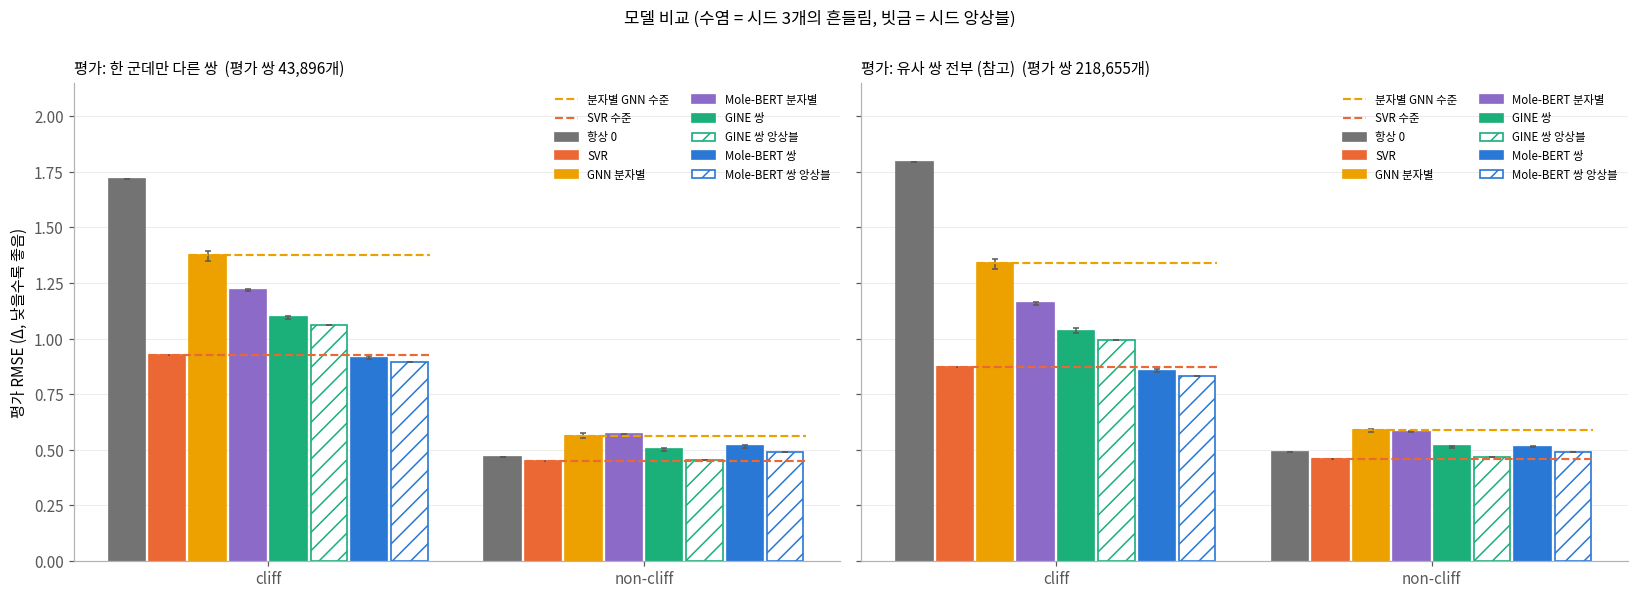

In [29]:
GROUPS = [(True, 'cliff'), (False, 'non-cliff')]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.4), sharey=True)
for a_, (st, pset) in zip(axes, RESULTS.items()):
    cmp, d = COMPARE[st], pset[pset.split == 'test']
    w, mid = 0.86 / len(COMPARE[st]), (len(COMPARE[st]) - 1) / 2
    for k_, (lbl, cols, col, hatch) in enumerate(cmp):
        v, lo, hi = [], [], []
        for cl, _ in GROUPS:
            s = seed_rmse(d, cols, d.is_cliff if cl else ~d.is_cliff)
            v.append(s.mean()); lo.append(s.mean() - s.min()); hi.append(s.max() - s.mean())
        a_.bar(np.arange(len(GROUPS)) + (k_ - mid) * w, v, w * 0.9, color=SURFACE if hatch else col, edgecolor=col, hatch=hatch,
               linewidth=1.1, label=lbl, zorder=2, yerr=[lo, hi], capsize=2, error_kw=dict(elinewidth=1, ecolor='0.35'))
        if lbl == 'GNN 분자별':
            mol_v, mol_k = v, k_
        if lbl == 'SVR':
            svr_v, svr_k = v, k_
    for g_, mv in enumerate(mol_v):   # 분자별 GNN 높이를 오른쪽 쌍 모델 막대 위로 연장 → 점선보다 낮으면 쌍 입력이 낫다
        a_.hlines(mv, g_ + (mol_k - mid - 0.45) * w, g_ + 0.43, colors=C4, linestyles='--', lw=1.4, zorder=3,
                  label='분자별 GNN 수준' if g_ == 0 else None)
    for g_, sv in enumerate(svr_v):   # SVR 높이도 같은 방식 → 점선보다 낮으면 SVR보다 낫다
        a_.hlines(sv, g_ + (svr_k - mid - 0.45) * w, g_ + 0.43, colors=C2, linestyles='--', lw=1.4, zorder=3,
                  label='SVR 수준' if g_ == 0 else None)
    a_.set(xticks=range(len(GROUPS)), ylim=(0, 2.15))
    a_.set_xticklabels([g[1] for g in GROUPS], fontsize=10)
    a_.set_title(f'{LABEL[st]}  (평가 쌍 {len(d):,}개)', loc='left', fontsize=10)
    a_.legend(fontsize=7.5, frameon=False, ncol=2, loc='upper right')
    a_.grid(axis='x', visible=False); tidy(a_)
axes[0].set_ylabel('평가 RMSE (Δ, 낮을수록 좋음)')
fig.suptitle('모델 비교 (수염 = 시드 3개의 흔들림, 빗금 = 시드 앙상블)', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()

In [30]:
CMP_TABLE = {}
for st, pset in RESULTS.items():
    d = pset[pset.split == 'test']
    CMP_TABLE[st] = pd.DataFrame({lbl: {'cliff': seed_rmse(d, cols, d.is_cliff).mean(),
                                        'non-cliff': seed_rmse(d, cols, ~d.is_cliff).mean(),
                                        'all': seed_rmse(d, cols).mean(),
                                        'bal': ((seed_rmse(d, cols, d.is_cliff) + seed_rmse(d, cols, ~d.is_cliff)) / 2).mean()}
                                  for lbl, cols, _, _ in COMPARE[st]}).T
    print(f'■ {LABEL[st]}  — 평가 RMSE: 아는 분자(A) 실측 + 예측 Δ로 구한 B와 B 실측의 차이  (평가 쌍 {len(d):,}개)')
    display(grouped(CMP_TABLE[st]).round(3))
t_ = RESULTS['single'][RESULTS['single'].split == 'test']
d_ = rmse(t_['pred_gnn_a0_fwd'], t_.delta) - rmse(t_[f'pred_gnn_a0_s{SEEDS[0]}'], t_.delta)
print(f'양방향 평균 효과 (GINE 시드 {SEEDS[0]}, 한 군데만 다른 평가 쌍) {d_:+.3f}')


■ 평가: 한 군데만 다른 쌍  — 평가 RMSE: 아는 분자(A) 실측 + 예측 Δ로 구한 B와 B 실측의 차이  (평가 쌍 43,896개)


cliff  non-cliff    all    bal
구분          모델                                             
기준선         항상 0             1.717      0.466  0.910  1.091
            SVR              0.928      0.449  0.591  0.688
            GNN 분자별          1.378      0.564  0.820  0.971
            Mole-BERT 분자별    1.219      0.570  0.765  0.894
GINE 쌍      GINE 쌍           1.097      0.504  0.683  0.801
            GINE 쌍 앙상블       1.059      0.456  0.642  0.758
Mole-BERT 쌍 Mole-BERT 쌍      0.914      0.515  0.627  0.715
            Mole-BERT 쌍 앙상블  0.893      0.491  0.605  0.692

■ 평가: 유사 쌍 전부 (참고)  — 평가 RMSE: 아는 분자(A) 실측 + 예측 Δ로 구한 B와 B 실측의 차이  (평가 쌍 218,655개)


cliff  non-cliff    all    bal
구분          모델                                             
기준선         항상 0             1.796      0.490  1.034  1.143
            SVR              0.872      0.459  0.603  0.665
            GNN 분자별          1.338      0.589  0.865  0.964
            Mole-BERT 분자별    1.160      0.582  0.786  0.871
GINE 쌍      GINE 쌍           1.035      0.516  0.700  0.775
            GINE 쌍 앙상블       0.995      0.466  0.657  0.731
Mole-BERT 쌍 Mole-BERT 쌍      0.854      0.513  0.626  0.683
            Mole-BERT 쌍 앙상블  0.832      0.489  0.604  0.660

양방향 평균 효과 (GINE 시드 0, 한 군데만 다른 평가 쌍) +0.004


### 기준 분자로 평가 분자 활성값 추정

Δ만 맞히고 분자 각각은 엉뚱하게 보는 것은 아닌지 확인한다.
평가 분자 B마다 짝이 되는 **학습 분자 A의 실측값**을 기준으로 B의 활성을 추정한다.

p̂(B) = 평균[ p(A) + Δ̂(A→B) ]   (B와 짝인 학습 분자 A 전부)

- 같은 평가 분자에서 **바로 예측**(SVR, GNN 분자별)과 비교한다
- **기준별 흩어짐**: 기준 A를 바꿔도 B의 추정값이 비슷한지 (기준 2개 이상인 분자의 표준편차 중앙값)
- 짝이 되는 학습 분자가 없는 평가 분자는 추정할 수 없어 뺀다 (추정 가능 비율을 함께 표시)


[single] 추정 가능 평가 분자 7,572/9,802 (77%) | 기준 2개 이상 5,789


[all] 추정 가능 평가 분자 9,148/9,802 (93%) | 기준 2개 이상 8,703


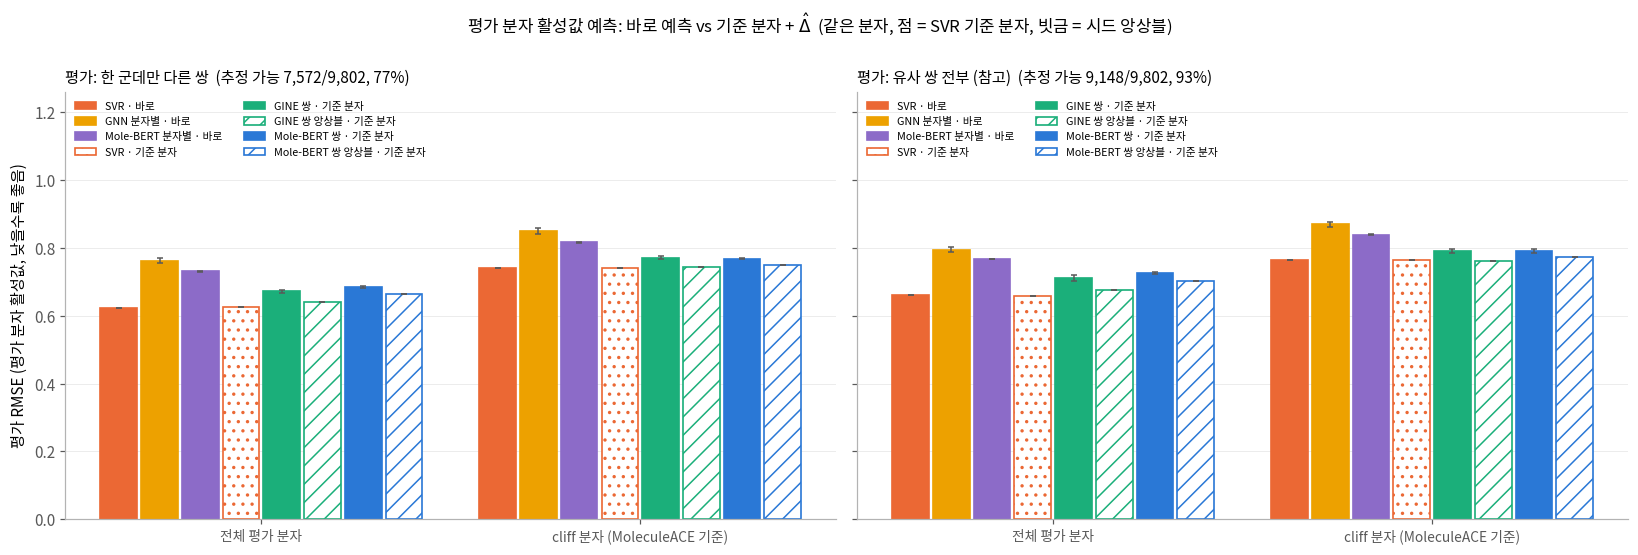

■ 평가: 한 군데만 다른 쌍  (추정 가능 평가 분자 7,572개)


전체 분자  cliff 분자  기준별 흩어짐
구분          모델                                               
기준선         SVR · 바로                 0.624     0.742      NaN
            GNN 분자별 · 바로             0.763     0.851      NaN
            Mole-BERT 분자별 · 바로       0.731     0.817      NaN
            SVR · 기준 분자              0.625     0.740    0.101
GINE 쌍      GINE 쌍 · 기준 분자           0.673     0.772    0.320
            GINE 쌍 앙상블 · 기준 분자       0.640     0.744    0.293
Mole-BERT 쌍 Mole-BERT 쌍 · 기준 분자      0.686     0.769    0.134
            Mole-BERT 쌍 앙상블 · 기준 분자  0.664     0.750    0.107

■ 평가: 유사 쌍 전부 (참고)  (추정 가능 평가 분자 9,148개)


전체 분자  cliff 분자  기준별 흩어짐
구분          모델                                               
기준선         SVR · 바로                 0.661     0.765      NaN
            GNN 분자별 · 바로             0.795     0.870      NaN
            Mole-BERT 분자별 · 바로       0.767     0.839      NaN
            SVR · 기준 분자              0.660     0.765    0.100
GINE 쌍      GINE 쌍 · 기준 분자           0.713     0.791    0.404
            GINE 쌍 앙상블 · 기준 분자       0.677     0.763    0.369
Mole-BERT 쌍 Mole-BERT 쌍 · 기준 분자      0.725     0.792    0.171
            Mole-BERT 쌍 앙상블 · 기준 분자  0.703     0.774    0.137

In [31]:
# 평가 분자 B의 활성을 학습 분자 A(실측값을 앎)를 기준으로 추정: p̂(B) = p(A) + Δ̂(A→B), 기준이 여러 개면 평균
TEST = pd.concat([load(t).assign(target=t, k=np.arange(len(load(t))))[lambda d: d.split == 'test'] for t in DEV_TARGETS]) \
         .set_index(['target', 'k'])[['p', 'cliff_mol']]
P_TRUE = {t: load(t).p.values for t in DEV_TARGETS}
SVR_DIRECT = pd.concat({t: pd.Series(mol_pred[t].values) for t in DEV_TARGETS}).rename_axis(['target', 'k'])
MOL_DIRECT = MOL_PRED.set_index(['target', 'k'])
PTMOL_DIRECT = PTMOL_PRED.set_index(['target', 'k'])

def anchored(pset, col):
    """평가 쌍(평가 분자 – 학습 분자)으로 평가 분자마다 (평균 추정값, 기준별 표준편차, 기준 수)"""
    e = pset[pset.split == 'test']
    b_is_j = np.array([mol_split[t][i] != 'test' for t, i in zip(e.target, e.i)])   # 쌍의 어느 쪽이 평가 분자인가
    k_test, k_ref = np.where(b_is_j, e.j, e.i), np.where(b_is_j, e.i, e.j)
    p_ref = np.array([P_TRUE[t][k] for t, k in zip(e.target, k_ref)])
    est = p_ref + np.where(b_is_j, 1, -1) * e[col].values      # 열의 Δ̂는 i → j 방향
    return pd.DataFrame({'target': e.target.values, 'k': k_test, 'est': est}) \
             .groupby(['target', 'k']).est.agg(['mean', 'std', 'size'])

ANCHOR = {}
for st, pset in RESULTS.items():
    pair = [x for x in COMPARE[st] if ' 쌍' in x[0]]
    est = {'SVR · 기준 분자': [anchored(pset, 'pred_svr')]}
    est.update({f'{lbl} · 기준 분자': [anchored(pset, c) for c in cols] for lbl, cols, _, _ in pair})
    idx = est['SVR · 기준 분자'][0].index                     # 추정 가능한 평가 분자 (모든 모델 공통)
    truth = TEST.loc[idx]
    cl = (truth.cliff_mol == 1).values
    preds = {'SVR · 바로': [SVR_DIRECT.loc[idx].values],
             'GNN 분자별 · 바로': [MOL_DIRECT.loc[idx, f's{s}'].values for s in SEEDS],
             'Mole-BERT 분자별 · 바로': [PTMOL_DIRECT.loc[idx, f's{s}'].values for s in SEEDS]}
    preds.update({m: [r.loc[idx, 'mean'].values for r in rs] for m, rs in est.items()})
    rows = {}
    for m, ps in preds.items():
        a_ = [rmse(p, truth.p) for p in ps]
        c_ = [rmse(p[cl], truth.p.values[cl]) for p in ps]
        sd = [float(r.loc[idx].query('size >= 2')['std'].median()) for r in est[m]] if m in est else [np.nan]
        rows[m] = {'전체 분자': np.mean(a_), '전체 분자 폭': np.ptp(a_), 'cliff 분자': np.mean(c_), 'cliff 분자 폭': np.ptp(c_),
                   '기준별 흩어짐': np.mean(sd)}
    style = [('SVR · 바로', C2, ''), ('GNN 분자별 · 바로', C4, ''), ('Mole-BERT 분자별 · 바로', PURPLE, ''), ('SVR · 기준 분자', C2, '..')] + \
            [(f'{lbl} · 기준 분자', col, hatch) for lbl, _, col, hatch in pair]
    ANCHOR[st] = dict(table=pd.DataFrame(rows).T, n=len(idx), n_test=len(TEST), idx=idx, truth=truth, preds=preds, style=style,
                      n_ref=est['SVR · 기준 분자'][0].loc[idx, 'size'],
                      n_multi=int((est['SVR · 기준 분자'][0].loc[idx, 'size'] >= 2).sum()))
    log(f'[{st}] 추정 가능 평가 분자 {len(idx):,}/{len(TEST):,} ({len(idx)/len(TEST):.0%}) | 기준 2개 이상 {ANCHOR[st]["n_multi"]:,}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for a_, (st, res) in zip(axes, ANCHOR.items()):
    t_, sty = res['table'], res['style']
    w, mid = 0.86 / len(sty), (len(sty) - 1) / 2
    for k_, (m, col, hatch) in enumerate(sty):
        v = [t_.loc[m, '전체 분자'], t_.loc[m, 'cliff 분자']]
        e = [t_.loc[m, '전체 분자 폭'] / 2, t_.loc[m, 'cliff 분자 폭'] / 2]
        a_.bar(np.arange(2) + (k_ - mid) * w, v, w * 0.9, color=SURFACE if hatch else col, edgecolor=col, hatch=hatch,
               linewidth=1.1, label=m, zorder=2, yerr=e, capsize=2, error_kw=dict(elinewidth=1, ecolor='0.35'))
    a_.set(xticks=range(2))
    a_.set_xticklabels(['전체 평가 분자', 'cliff 분자 (MoleculeACE 기준)'], fontsize=9)
    a_.set_title(f'{LABEL[st]}  (추정 가능 {res["n"]:,}/{res["n_test"]:,}, {res["n"]/res["n_test"]:.0%})', loc='left', fontsize=10)
    a_.legend(fontsize=7, frameon=False, ncol=2, loc='upper left'); a_.grid(axis='x', visible=False); tidy(a_)
axes[0].set_ylabel('평가 RMSE (평가 분자 활성값, 낮을수록 좋음)')
axes[0].set_ylim(0, max(r['table'][['전체 분자', 'cliff 분자']].values.max() for r in ANCHOR.values()) * 1.45)
fig.suptitle(r'평가 분자 활성값 예측: 바로 예측 vs 기준 분자 + $\hat{\Delta}$  (같은 분자, 점 = SVR 기준 분자, 빗금 = 시드 앙상블)', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()
for st, r in ANCHOR.items():
    print(f'■ {LABEL[st]}  (추정 가능 평가 분자 {r["n"]:,}개)')
    display(grouped(r['table'].drop(columns=['전체 분자 폭', 'cliff 분자 폭'])).round(3))


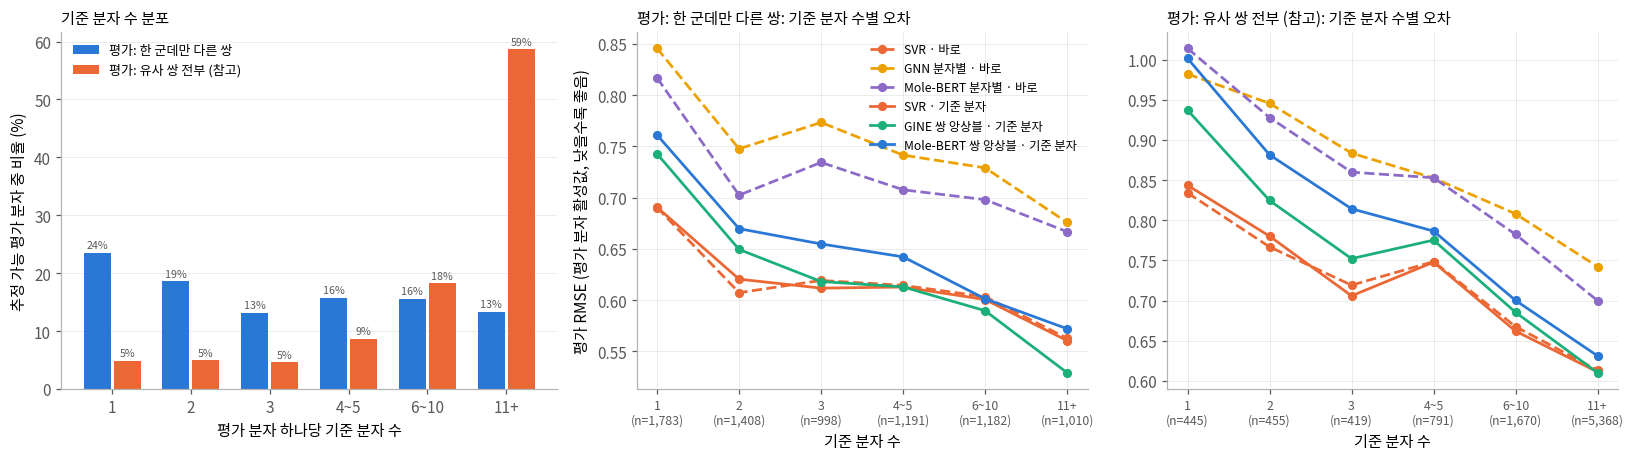

In [32]:
# 기준 분자 수 분포(왼쪽)와 기준 분자 수별 평가 분자 활성값 오차(가운데·오른쪽)
BINS = [(1, 1, '1'), (2, 2, '2'), (3, 3, '3'), (4, 5, '4~5'), (6, 10, '6~10'), (11, 10 ** 9, '11+')]
def ref_bin(n):
    return pd.Series(pd.cut(n, [b[0] - 0.5 for b in BINS] + [10 ** 9], labels=[b[2] for b in BINS]), index=n.index)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), gridspec_kw=dict(width_ratios=[1.1, 1, 1]))
a_ = axes[0]; w = 0.38
for k_, (st, res) in enumerate(ANCHOR.items()):
    share = ref_bin(res['n_ref']).value_counts(normalize=True).reindex([b[2] for b in BINS]) * 100
    bars = a_.bar(np.arange(len(BINS)) + (k_ - 0.5) * w, share.values, w * 0.9, color=[C1, C2][k_], label=LABEL[st], zorder=2)
    for b, v in zip(bars, share.values):
        a_.text(b.get_x() + b.get_width() / 2, v + 0.8, f'{v:.0f}%', ha='center', fontsize=7, color='0.35')
a_.set(xticks=range(len(BINS)), xlabel='평가 분자 하나당 기준 분자 수', ylabel='추정 가능 평가 분자 중 비율 (%)')
a_.set_xticklabels([b[2] for b in BINS])
a_.set_title('기준 분자 수 분포', loc='left', fontsize=10)
a_.legend(fontsize=8.5, frameon=False); a_.grid(axis='x', visible=False); tidy(a_)

LINES = [('SVR · 바로', C2, '--'), ('GNN 분자별 · 바로', C4, '--'), ('Mole-BERT 분자별 · 바로', PURPLE, '--'), ('SVR · 기준 분자', C2, '-'),
         ('GINE 쌍 앙상블 · 기준 분자', C3, '-'), ('Mole-BERT 쌍 앙상블 · 기준 분자', C1, '-')]
for a_, (st, res) in zip(axes[1:], ANCHOR.items()):
    bins = ref_bin(res['n_ref']).values
    tp = res['truth'].p.values
    for m, col, ls in LINES:
        ys = [np.mean([rmse(p[bins == b[2]], tp[bins == b[2]]) for p in res['preds'][m]]) for b in BINS]
        a_.plot(range(len(BINS)), ys, ls, color=col, marker='o', ms=5, lw=1.8, label=m)
    a_.set(xticks=range(len(BINS)), xlabel='기준 분자 수')
    a_.set_xticklabels([f'{b[2]}\n(n={int((bins == b[2]).sum()):,})' for b in BINS], fontsize=8)
    a_.set_title(f'{LABEL[st]}: 기준 분자 수별 오차', loc='left', fontsize=10)
    tidy(a_)
axes[1].set_ylabel('평가 RMSE (평가 분자 활성값, 낮을수록 좋음)'); axes[1].legend(fontsize=8, frameon=False)
fig.tight_layout(); plt.show()

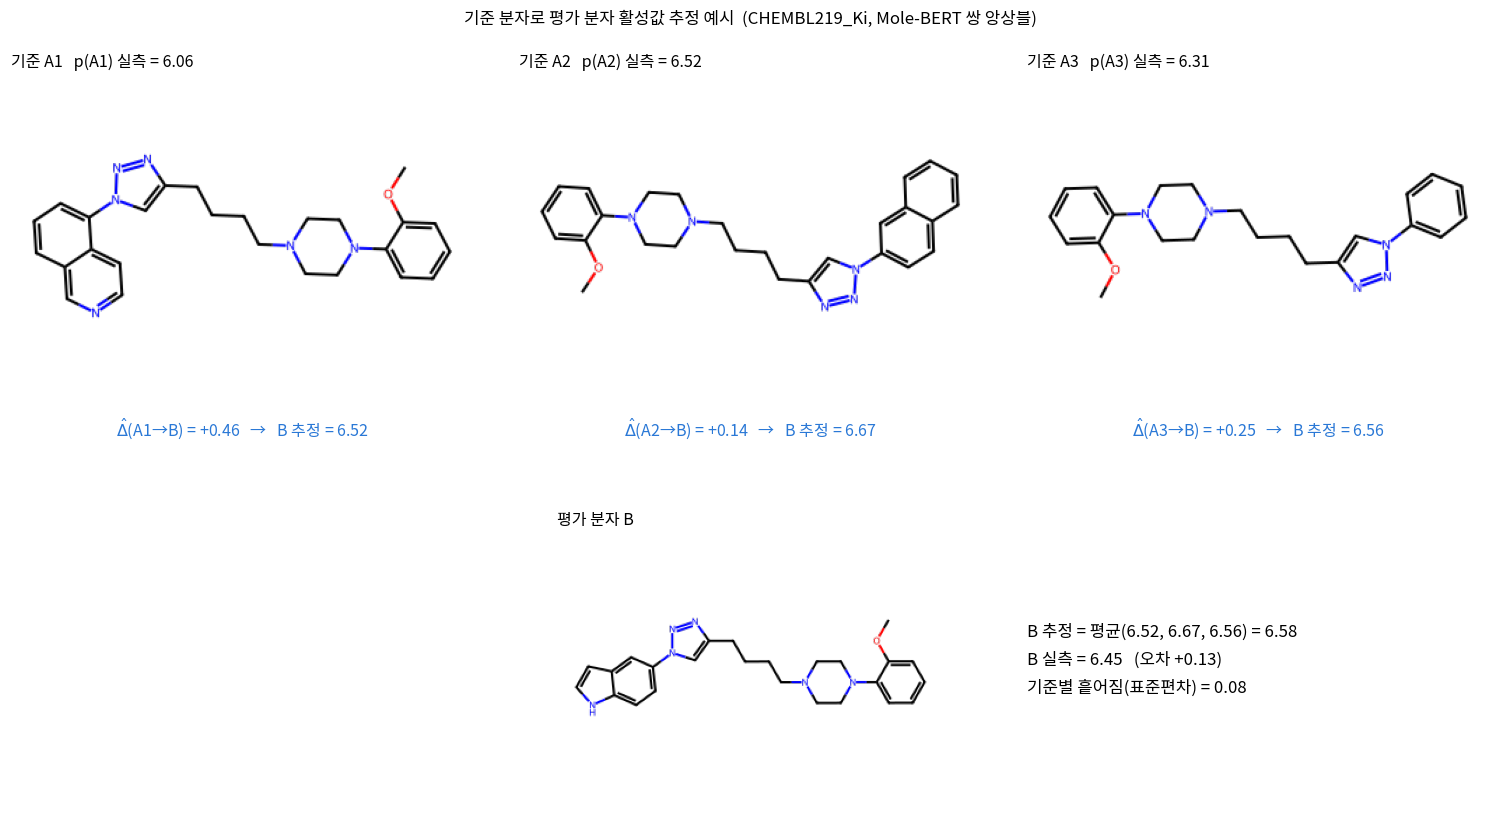

In [33]:
# 기준 분자 예시: 기준이 3개인 평가 분자 하나 (한 군데만 다른 쌍, Mole-BERT 쌍 앙상블)
import io
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

def _mol(smiles, size=(330, 230)):
    m = Chem.MolFromSmiles(smiles); rdDepictor.Compute2DCoords(m)
    d = rdMolDraw2D.MolDraw2DCairo(*size); d.drawOptions().clearBackground = False
    d.DrawMolecule(m); d.FinishDrawing()
    return plt.imread(io.BytesIO(d.GetDrawingText()))

ps = RESULTS['single']; e = ps[ps.split == 'test'].copy()
e['b_is_j'] = [mol_split[t][i] != 'test' for t, i in zip(e.target, e.i)]
e['kb'] = np.where(e.b_is_j, e.j, e.i); e['ka'] = np.where(e.b_is_j, e.i, e.j)
e['d_hat'] = np.where(e.b_is_j, 1, -1) * e['pred_pt_ens']
n_ref = e.groupby(['target', 'kb']).size()
t_, kb = n_ref[n_ref == 3].sample(1, random_state=SEED).index[0]
ex = e[(e.target == t_) & (e.kb == kb)]
p_b = P_TRUE[t_][kb]; smi = load(t_).smiles

fig = plt.figure(figsize=(14, 7.2))
ests = []
for n, r in enumerate(ex.itertuples()):
    p_a = P_TRUE[t_][r.ka]; est = p_a + r.d_hat; ests.append(est)
    ax = fig.add_axes([0.02 + n * 0.33, 0.50, 0.30, 0.43]); ax.imshow(_mol(smi[r.ka])); ax.axis('off')
    ax.set_title(f'기준 A{n + 1}   p(A{n + 1}) 실측 = {p_a:.2f}', fontsize=10.5, loc='left')
    ax.text(0.5, -0.06, rf'$\hat{{\Delta}}$(A{n + 1}→B) = {r.d_hat:+.2f}   →   B 추정 = {est:.2f}',
            transform=ax.transAxes, ha='center', va='top', fontsize=10.5, color=C1)
ax = fig.add_axes([0.35, 0.0, 0.30, 0.34]); ax.imshow(_mol(smi[kb])); ax.axis('off')
ax.set_title('평가 분자 B', fontsize=10.5, loc='left')
fig.text(0.68, 0.18, f'B 추정 = 평균({", ".join(f"{v:.2f}" for v in ests)}) = {np.mean(ests):.2f}\n'
                     f'B 실측 = {p_b:.2f}   (오차 {np.mean(ests) - p_b:+.2f})\n'
                     f'기준별 흩어짐(표준편차) = {np.std(ests, ddof=1):.2f}', fontsize=11, va='center', linespacing=1.8)
fig.suptitle(f'기준 분자로 평가 분자 활성값 추정 예시  ({t_}, Mole-BERT 쌍 앙상블)', y=1.0, fontsize=11)
plt.show()

#### 기준 분자 평가 해석

| 앙상블 기준 | 한 군데만 평가: 전체 분자 | 한 군데만 평가: 흩어짐 | 유사 쌍 평가: 전체 분자 | 유사 쌍 평가: 흩어짐 |
|---|---|---|---|---|
| SVR · 바로 | **0.624** | — | **0.661** | — |
| GNN 분자별 · 바로 | 0.763 | — | 0.795 | — |
| Mole-BERT 분자별 · 바로 | 0.731 | — | 0.767 | — |
| GINE 쌍 · 기준 분자 | 0.640 | 0.29 | 0.677 | 0.37 |
| Mole-BERT 쌍 · 기준 분자 | 0.664 | **0.11** | 0.703 | **0.14** |

(흩어짐: SVR · 기준 분자는 0.10)

- **Δ만 맞고 개별 값은 엉뚱한 것은 아니다.** 실측 기준을 주면 쌍 모델이 같은 인코더의 분자별 예측보다 평가 분자 활성값을 잘 맞힌다
- **Mole-BERT는 기준을 바꿔도 추정값이 거의 흔들리지 않는다** (0.11, SVR 0.10 수준). GINE은 0.29로 크게 흔들린다
- **그래도 평가 분자 활성값 오차는 SVR이 가장 낮다**


### 누수 점검: 다른 타깃에서 본 분자

GNN은 30개 타깃을 모델 하나로 학습한다. 그래서 어떤 타깃의 평가 분자가 **다른 타깃에서는 학습 분자**였을 수 있다
(평가 분자의 약 1/3). 그 타깃의 활성값을 본 것은 아니지만 구조는 본 셈이다. SVR은 타깃마다 따로 학습해 이 문제가 없다.

In [34]:
# 누수 점검: 30개 타깃을 모델 하나로 학습하므로, 평가 분자가 다른 타깃의 학습 분자로 나왔을 수 있다
TRAIN_T = pd.concat([load(t)[load(t).split == 'train'].assign(target=t) for t in DEV_TARGETS]).groupby('smiles').target.apply(set)
def seen_elsewhere(t, k):
    s = load(t).smiles[k]
    return s in TRAIN_T.index and bool(TRAIN_T[s] - {t})

te_seen = np.array([seen_elsewhere(t, k) for t, k in TEST.index])
print(f'평가 분자 {len(te_seen):,}개 중 다른 타깃의 학습 분자로 나온 분자 {te_seen.sum():,}개 ({te_seen.mean():.1%})')

LEAK = {}
for st, pset in RESULTS.items():
    d = pset[pset.split == 'test']
    kb = np.where([mol_split[t][i] != 'test' for t, i in zip(d.target, d.i)], d.j, d.i)   # 평가 분자 쪽
    seen = np.array([seen_elsewhere(t, k) for t, k in zip(d.target, kb)])
    cols_ = {(cn, sn): cm & sm for cn, cm in [('cliff', d.is_cliff.values), ('non-cliff', ~d.is_cliff.values)]
             for sn, sm in [('다른 타깃에서 본 분자', seen), ('처음 보는 분자', ~seen)]}
    LEAK[st] = pd.DataFrame({lbl: {k: np.mean([float(np.sqrt(np.mean(b_err(d, c)[m] ** 2))) for c in cols]) for k, m in cols_.items()}
                             for lbl, cols, _, _ in COMPARE[st]}).T
    for sn in ['다른 타깃에서 본 분자', '처음 보는 분자']:
        LEAK[st][('bal', sn)] = (LEAK[st][('cliff', sn)] + LEAK[st][('non-cliff', sn)]) / 2
    print(f'{LABEL[st]}: 쌍 수 ' + ', '.join(f'{c}·{s} {int(m.sum()):,}' for (c, s), m in cols_.items()))
for st, t in LEAK.items():
    print(f'■ {LABEL[st]}')
    display(grouped(t).round(3))


평가 분자 9,802개 중 다른 타깃의 학습 분자로 나온 분자 3,311개 (33.8%)


평가: 한 군데만 다른 쌍: 쌍 수 cliff·다른 타깃에서 본 분자 2,678, cliff·처음 보는 분자 7,155, non-cliff·다른 타깃에서 본 분자 11,363, non-cliff·처음 보는 분자 22,700


평가: 유사 쌍 전부 (참고): 쌍 수 cliff·다른 타깃에서 본 분자 20,610, cliff·처음 보는 분자 40,064, non-cliff·다른 타깃에서 본 분자 61,835, non-cliff·처음 보는 분자 96,146
■ 평가: 한 군데만 다른 쌍


cliff             non-cliff           \
                            다른 타깃에서 본 분자 처음 보는 분자 다른 타깃에서 본 분자 처음 보는 분자   
구분          모델                                                            
기준선         항상 0                   1.670    1.734        0.441    0.478   
            SVR                    0.953    0.918        0.431    0.458   
            GNN 분자별                1.352    1.387        0.526    0.582   
            Mole-BERT 분자별          1.163    1.239        0.533    0.587   
GINE 쌍      GINE 쌍                 1.048    1.114        0.458    0.526   
            GINE 쌍 앙상블             1.020    1.074        0.423    0.472   
Mole-BERT 쌍 Mole-BERT 쌍            0.839    0.940        0.456    0.543   
            Mole-BERT 쌍 앙상블        0.822    0.919        0.435    0.517   

                                     bal           
                            다른 타깃에서 본 분자 처음 보는 분자  
구분          모델                                     
기준선         항상 0                   1.055    1.106  
            SVR                    0.692    0.688  
            GNN 분자별                0.939    0.985  
            Mole-BERT 분자별          0.848    0.913  
GINE 쌍      GINE 쌍                 0.753    0.820  
            GINE 쌍 앙상블             0.721    0.773  
Mole-BERT 쌍 Mole-BERT 쌍            0.647    0.742  
            Mole-BERT 쌍 앙상블        0.629    0.718

■ 평가: 유사 쌍 전부 (참고)


cliff             non-cliff           \
                            다른 타깃에서 본 분자 처음 보는 분자 다른 타깃에서 본 분자 처음 보는 분자   
구분          모델                                                            
기준선         항상 0                   1.772    1.808        0.477    0.498   
            SVR                    0.850    0.883        0.428    0.478   
            GNN 분자별                1.276    1.369        0.557    0.609   
            Mole-BERT 분자별          1.084    1.198        0.543    0.606   
GINE 쌍      GINE 쌍                 0.950    1.076        0.450    0.553   
            GINE 쌍 앙상블             0.918    1.033        0.412    0.497   
Mole-BERT 쌍 Mole-BERT 쌍            0.745    0.905        0.439    0.555   
            Mole-BERT 쌍 앙상블        0.725    0.882        0.418    0.529   

                                     bal           
                            다른 타깃에서 본 분자 처음 보는 분자  
구분          모델                                     
기준선         항상 0                   1.124    1.153  
            SVR                    0.639    0.680  
            GNN 분자별                0.916    0.989  
            Mole-BERT 분자별          0.813    0.902  
GINE 쌍      GINE 쌍                 0.700    0.815  
            GINE 쌍 앙상블             0.665    0.765  
Mole-BERT 쌍 Mole-BERT 쌍            0.592    0.730  
            Mole-BERT 쌍 앙상블        0.572    0.706

같은 cliff / non-cliff 안에서 비교하면, GNN은 **다른 타깃에서 구조를 본 분자에서 더 잘 맞힌다.**
한 군데만 다른 평가 쌍 · cliff · Mole-BERT 앙상블: 본 분자 0.822 vs 처음 보는 분자 0.919.
**처음 보는 분자만 보면 Mole-BERT와 SVR은 cliff에서 대등하다** (0.919 vs 0.918, 유사 쌍 평가에서도 0.882 vs 0.883).
즉 SVR을 앞선 폭은 대부분 누수에서 나오고, 누수를 빼면 SVR과 **대등**하다.


### 학습 곡선

학습이 진행될수록 오차가 어떻게 줄었는지 본다.
두 선의 간격에는 **과적합과 난이도 차이가 섞여 있다**: 학습 선은 학습–학습 쌍, 검증 선은 한쪽이 처음 보는 분자인 쌍이다.


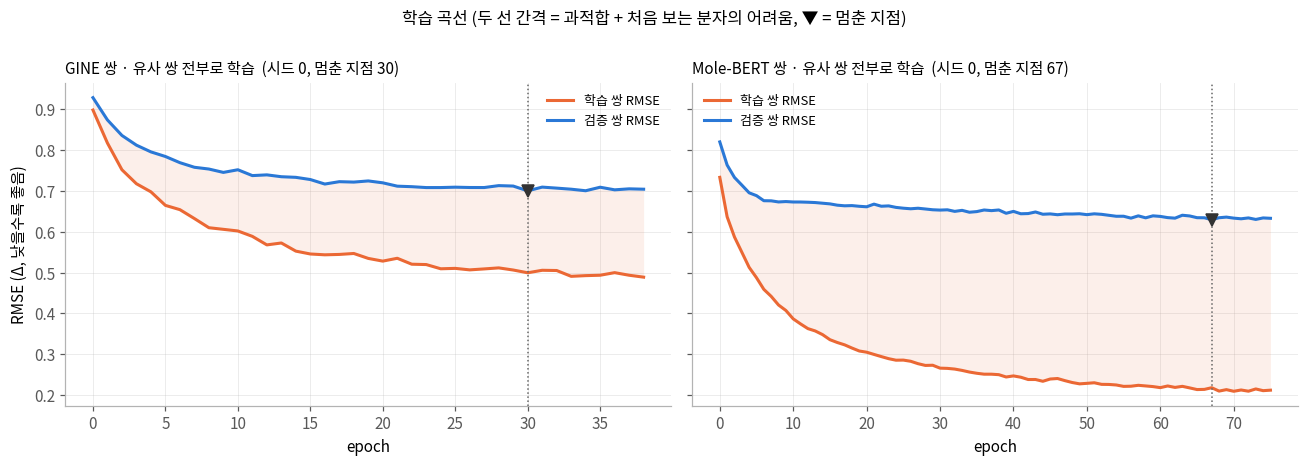

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for a_, (enc, tag) in zip(axes, [('gnn', TAGS['all']), ('pt', PT_TAGS['all'])]):
    h = pd.read_csv(f'{RUNS}/hist_a0_{tag}_seed{SEEDS[0]}.csv')
    stop = int(h.best_epoch[0])
    a_.plot(h.epoch, h.train, color=C2, lw=2, label='학습 쌍 RMSE')
    a_.plot(h.epoch, h.val, color=C1, lw=2, label='검증 쌍 RMSE')
    a_.fill_between(h.epoch, h.train, h.val, color=C2, alpha=0.10, lw=0)
    a_.axvline(stop, color='0.4', lw=1, ls=':')
    a_.plot([stop], [h.val.min()], marker='v', color='0.2', ms=8, clip_on=False)
    a_.set_title(f'{ENC[enc]} · 유사 쌍 전부로 학습  (시드 {SEEDS[0]}, 멈춘 지점 {stop})', loc='left', fontsize=10)
    a_.set_xlabel('epoch'); a_.legend(fontsize=8.5, frameon=False); tidy(a_)
axes[0].set_ylabel('RMSE (Δ, 낮을수록 좋음)')
fig.suptitle('학습 곡선 (두 선 간격 = 과적합 + 처음 보는 분자의 어려움, ▼ = 멈춘 지점)', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()


### 기록: 시도한 개선과 결과

모두 시드 3개. 숫자는 평가 쌍 RMSE (cliff / non-cliff / bal). **차이 없음** = 차이가 시드 흔들림(시드 3개의 최대−최소) 안.

**학습 쌍 고르기 (반영)** — 한 군데만 다른 평가 쌍 43,896개, 시드 앙상블

| | 한 군데만 다른 쌍으로 학습 | 유사 쌍 전부로 학습 |
|---|---|---|
| GINE 쌍 | 1.117 / 0.459 / 0.788 | 1.059 / 0.456 / 0.758 |
| Mole-BERT 쌍 | 1.061 / 0.467 / 0.764 | **0.893** / 0.491 / **0.692** |

Mole-BERT는 확실히 좋아진다 (시드별 bal 0.778 → 0.715, 시드 흔들림 0.004). GINE은 좋아지는 방향이지만 시드 흔들림 안이다 (0.823 → 0.801, 흔들림 0.026).
학습 데이터가 많고, 여러 군데 바뀐 쌍까지 보면서 더 일반적으로 배우는 것으로 보인다. 그래서 학습은 유사 쌍 전부로 한다.

**쌍 판정 개선 (반영)** — 여러 군데 바뀐 쌍도 바뀐 원자(조각)와 부위별 편집 수를 갖게 했다. 유사 쌍 전부 평가 · GINE

| | cliff | non-cliff | bal | 시드 흔들림 |
|---|---|---|---|---|
| 고치기 전 | 1.029 | 0.526 | 0.777 | 0.025 |
| 고친 후 | 1.035 | 0.516 | 0.775 | 0.008 |
| 고친 후 + 큰 조각(10원자 초과) 비움 | 1.030 | 0.522 | 0.776 | 0.018 |

차이 없음. 그래도 학습 쌍의 대부분(여러 군데 바뀐 쌍)이 조각 정보 없이 학습되던 문제를 고친 것이라 유지한다 (조각 정보를 되살린 비율 86.1%).

**바뀐 부분 따로 읽기 (유지)** — 한 군데만 다른 쌍으로 학습·평가 · GINE

| | cliff | non-cliff | bal | 시드 흔들림 | 파라미터 |
|---|---|---|---|---|---|
| 그대로 (분자 + 조각 + 편집 정보) | 1.149 | 0.496 | 0.823 | 0.026 | 80,385 |
| 조각 인코더 뺌 | 1.187 | 0.500 | 0.844 | 0.060 | 43,457 |
| 조각 인코더 · 편집 정보 둘 다 뺌 | 1.154 | 0.506 | 0.830 | 0.010 | 43,073 |

빼면 bal이 나빠지는 방향이지만 시드 흔들림 안이다. 편집 정보만 뺀 조건은 아직 재지 않았다.

**손실 가중치 α (뺌)** — 차이가 큰 쌍을 더 무겁게(w = 1 + α·|Δ|). 예측 크기를 검증 쌍으로 보정한 뒤 bal (v2 이전 쌍 판정)

| | α=0 | 0.5 | 1 | 2 | 4 |
|---|---|---|---|---|---|
| 한 군데만 · GINE | **0.823** | 0.829 | 0.839 | 0.855 | 0.852 |
| 한 군데만 · Mole-BERT | **0.779** | 0.787 | 0.794 | 0.799 | 0.808 |
| 유사 쌍 · GINE | **0.778** | 0.786 | 0.780 | 0.788 | 0.803 |
| 유사 쌍 · Mole-BERT | 0.696 | 0.703 | **0.694** | 0.725 | 0.752 |

α=0보다 시드 흔들림 이상 좋은 경우가 없다. 검증 전체 오차도 네 경우 모두 α=0이 가장 좋았다.

**게이트 (뺌)** — 헤드가 cliff 확률 p도 내고, 예측 = p × 원래 예측. LAM = 손실에서 cliff 맞히기(분류)의 비중. 한 군데만 다른 쌍 · GINE

| | cliff | non-cliff | bal | 시드 흔들림 |
|---|---|---|---|---|
| 게이트 없음 | 1.149 | 0.496 | 0.823 | 0.026 |
| 모든 예측을 같은 비율로 줄이기 | 1.165 | 0.483 | 0.824 | 0.027 |
| 게이트 LAM 0 | 1.191 | 0.501 | 0.846 | 0.023 |
| 게이트 LAM 0.1 | 1.256 | 0.494 | 0.875 | 0.008 |
| 게이트 LAM 0.3 | 1.298 | 0.498 | 0.898 | 0.007 |
| 게이트 LAM 1 | 1.336 | 0.492 | 0.914 | 0.014 |

LAM 0.1 이상은 cliff가 확실히 나빠진다. cliff 확률 자체는 잘 맞았다 (약 30%라고 한 쌍의 실제 cliff 비율 25–29%).


### 기록: 편집 정보 빼 보기 (유사 쌍 전부로 학습 · GINE · 시드 3)

"많이 바뀌었으니 차이가 크겠지"라는 쉬운 단서에 기대는지 본다. 편집 정보 6칸 전부를 뺀 모델과,
"바뀐 원자 수" 칸만 뺀 모델을 따로 학습해 지금 모델과 같은 평가 쌍(한 군데만 다른 쌍)에서 비교한다.


In [36]:
# 편집 정보 빼 보기 결과: 따로 학습한 모델의 예측값(runs/tmp/ablC)을 불러와 비교한다 (학습 없음)
ABL = {'지금 모델 (6칸 모두)': [pairs_all[f'pred_gnn_a0_s{s}'].values for s in SEEDS]}
for cond, name in [('noedit', '편집 정보 6칸 전부 뺌'), ('nonchanged', '바뀐 원자 수 칸만 뺌')]:
    fs = [f'runs/tmp/ablC/pred_ablC_{cond}_s{s}.pkl' for s in SEEDS]
    if all(os.path.exists(f) for f in fs):
        ps_ = [pd.read_pickle(f) for f in fs]
        assert all((p_[KEY].values == pairs_all[KEY].values).all() for p_ in ps_), '쌍 순서가 다르다'
        ABL[name] = [p_[f'pred_gnn_a0_s{s}'].values for p_, s in zip(ps_, SEEDS)]
    else:
        print(f'{name}: 아직 학습 중')
m_ = ((pairs_all.split == 'test') & (pairs_all.reason == 'pass')).values
y_ = pairs_all.delta.values[m_]; cl_ = np.abs(y_) >= CLIFF
rows = {}
for name, preds in ABL.items():
    v = np.array([[rmse(p[m_][cl_], y_[cl_]), rmse(p[m_][~cl_], y_[~cl_]), rmse(p[m_], y_)] for p in preds])
    b = v[:, :2].mean(1)
    rows[name] = {'cliff': v[:, 0].mean(), 'non-cliff': v[:, 1].mean(), 'all': v[:, 2].mean(), 'bal': b.mean(), 'bal 시드 흔들림': np.ptp(b)}
ABL_TABLE = pd.DataFrame(rows).T
b0, w0 = ABL_TABLE.iloc[0].bal, ABL_TABLE.iloc[0]['bal 시드 흔들림']
ABL_TABLE['지금 모델 대비'] = ['—'] + ['나빠짐' if r.bal - b0 > max(w0, r['bal 시드 흔들림']) else '좋아짐' if b0 - r.bal > max(w0, r['bal 시드 흔들림'])
                                       else '차이 없음' for _, r in ABL_TABLE.iloc[1:].iterrows()]
print(f'평가 RMSE (한 군데만 다른 평가 쌍 {int(m_.sum()):,}개, 시드 3개 평균)')
ABL_TABLE.round(3)


평가 RMSE (한 군데만 다른 평가 쌍 43,896개, 시드 3개 평균)


,cliff,non-cliff,all,bal,bal 시드 흔들림,지금 모델 대비
지금 모델 (6칸 모두),1.097,0.504,0.683,0.801,0.005,—
편집 정보 6칸 전부 뺌,1.091,0.514,0.687,0.803,0.005,차이 없음
바뀐 원자 수 칸만 뺌,1.101,0.509,0.687,0.805,0.015,차이 없음


#### 편집 정보 빼 보기 해석 (차이 없음)

| 한 군데만 다른 평가 쌍 (시드 3 평균) | cliff | non-cliff | all | bal | 시드 흔들림 |
|---|---|---|---|---|---|
| 지금 모델 (6칸 모두) | 1.097 | 0.504 | 0.683 | 0.801 | 0.005 |
| 편집 정보 6칸 전부 뺌 | 1.091 | 0.514 | 0.687 | 0.803 | 0.005 |
| 바뀐 원자 수 칸만 뺌 | 1.101 | 0.509 | 0.687 | 0.805 | 0.015 |

- 셋 다 차이가 시드 흔들림 안이라 **차이 없음**이다
- **"많이 바뀌었으니 차이가 크겠지"라는 단서에 기대지 않는다.** 바뀐 원자 수 칸을 빼도 cliff 오차가 그대로다
- 대신 **편집 정보가 성능에 도움이 된다는 근거도 없다.** 모델은 분자 그래프와 조각에서 필요한 정보를 이미 얻는 것으로 보인다


### 타깃별 차이

한 군데만 다른 평가 쌍에서 타깃별 cliff 오차를 비교한다.
시드 앙상블 기준으로 **Mole-BERT 쌍은 30개 중 13개 타깃에서 SVR보다 낫다** (GINE 쌍은 3개).


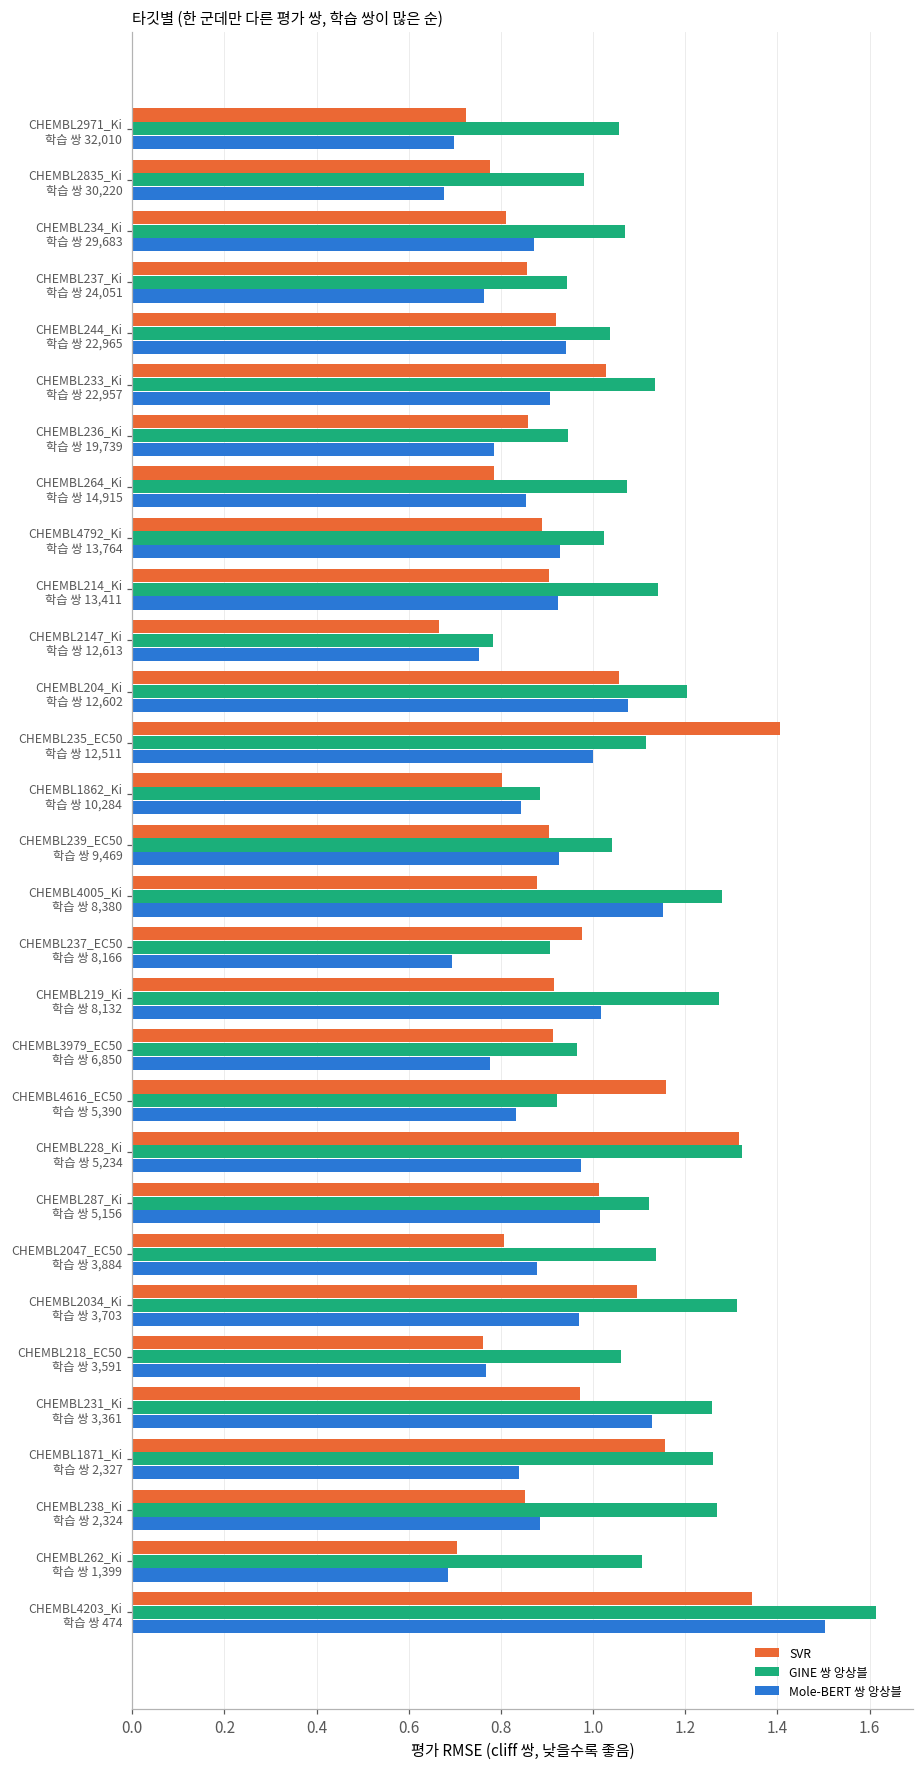

GINE 쌍 앙상블이 SVR보다 나은 타깃: 3 / 30
Mole-BERT 쌍 앙상블이 SVR보다 나은 타깃: 13 / 30


In [37]:
pset = RESULTS['single']
tc = pset[(pset.split == 'test') & pset.is_cliff]
SHOW = [('svr', 'SVR', C2), ('gnn_ens', 'GINE 쌍 앙상블', C3), ('pt_ens', 'Mole-BERT 쌍 앙상블', C1)]
per = pd.DataFrame({m: {t: b_rmse(d, f'pred_{m}') for t, d in tc.groupby('target')} for m, _, _ in SHOW})
per['n_train'] = pairs_all[pairs_all.split == 'train'].target.value_counts()   # 실제 학습 쌍 (유사 쌍 전부)
per = per.sort_values('n_train')

fig, a_ = plt.subplots(figsize=(8.5, max(3.6, 0.5 * len(per) + 1.2)))
y, hgt = np.arange(len(per)), 0.27
for k_, (m, lbl, col) in enumerate(SHOW):
    a_.barh(y + (1 - k_) * hgt, per[m], hgt * 0.95, color=col, label=lbl, zorder=2)
a_.set(yticks=y, xlabel='평가 RMSE (cliff 쌍, 낮을수록 좋음)')
a_.set_yticklabels([f'{t}\n학습 쌍 {n:,}' for t, n in zip(per.index, per.n_train)], fontsize=8)
a_.legend(fontsize=8, frameon=False, loc='lower right'); a_.grid(axis='y', visible=False); tidy(a_)
a_.set_title('타깃별 (한 군데만 다른 평가 쌍, 학습 쌍이 많은 순)', loc='left', fontsize=10)
fig.tight_layout(); plt.show()
for m, lbl, _ in SHOW[1:]:
    print(f'{lbl}이 SVR보다 나은 타깃: {int((per[m] < per.svr).sum())} / {len(per)}')

### 차이 크기별 오차

약효 차이가 작은 쌍 / 중간 / 큰 쌍으로 나눠 오차를 본다.

In [38]:
BUCKETS = ['|Δ|<1', '1≤|Δ|<2', '|Δ|≥2']
MAES = {}
for st, pset in RESULTS.items():
    t_ = pset[pset.split == 'test']
    b = pd.cut(t_.delta.abs(), [0, 1, 2, np.inf], right=False, labels=BUCKETS)
    m = pd.DataFrame({lbl: [np.mean([np.abs(b_err(t_, c))[(b == bk).values].mean() for c in cols]) for bk in BUCKETS]
                      for lbl, cols, _, _ in COMPARE[st]}, index=BUCKETS)
    m.insert(0, 'n', b.value_counts().reindex(BUCKETS).values)
    MAES[st] = m

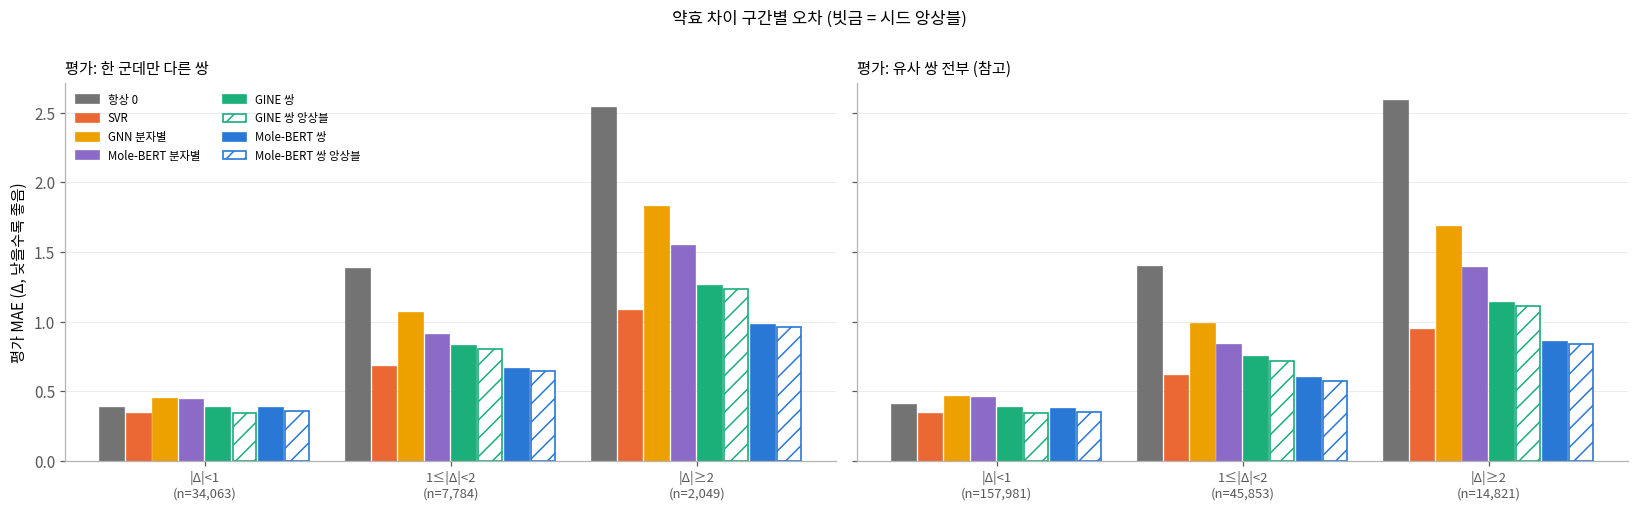

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), sharey=True)
for a_, (st, mae) in zip(axes, MAES.items()):
    cmp = COMPARE[st]; w, mid = 0.86 / len(cmp), (len(cmp) - 1) / 2
    for i, (lbl, _, col, hatch) in enumerate(cmp):
        a_.bar(np.arange(3) + (i - mid) * w, mae[lbl].values, w * 0.9, color=SURFACE if hatch else col, edgecolor=col,
               hatch=hatch, linewidth=1.1, label=lbl, zorder=2)
    a_.set(xticks=range(3))
    a_.set_xticklabels([f'{b}\n(n={int(n):,})' for b, n in zip(BUCKETS, mae.n)], fontsize=8.5)
    a_.set_title(LABEL[st], loc='left', fontsize=10)
    a_.grid(axis='x', visible=False); tidy(a_)
axes[0].set_ylabel('평가 MAE (Δ, 낮을수록 좋음)')
axes[0].legend(fontsize=7.5, frameon=False, ncol=2)
fig.suptitle('약효 차이 구간별 오차 (빗금 = 시드 앙상블)', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()

### non-cliff에서 약한 이유

예측이 **실제보다 크게 나오는지** 본다. 차이가 거의 없는 쌍에도 큰 값을 말하면 오차가 커진다.
아래 숫자의 **기울기가 1보다 작으면 과장**이라는 뜻이다.

In [40]:
for st, pset in RESULTS.items():
    d, v = pset[pset.split == 'test'], pset[pset.split == 'val']
    for enc in ['gnn', 'pt']:
        col = f'pred_{enc}_ens'
        corr = float(np.corrcoef(d[col], d.delta)[0, 1]); slope = float(np.polyfit(d[col], d.delta, 1)[0])
        c = float((v.delta * v[col]).sum() / (v[col] ** 2).sum())
        sh = c * d[col]
        b0 = rmse(d[col][d.is_cliff], d.delta[d.is_cliff]), rmse(d[col][~d.is_cliff], d.delta[~d.is_cliff])
        a0 = rmse(sh[d.is_cliff], d.delta[d.is_cliff]), rmse(sh[~d.is_cliff], d.delta[~d.is_cliff])
        print(f'{LABEL[st]:<10} {ENC[enc]} 앙상블  상관 {corr:.3f}  기울기 {slope:.3f}'
              f'  | {c:.3f}배로 줄이면 cliff {b0[0]:.3f}→{a0[0]:.3f}, non-cliff {b0[1]:.3f}→{a0[1]:.3f}')

평가: 한 군데만 다른 쌍 GINE 쌍 앙상블  상관 0.709  기울기 1.051  | 1.042배로 줄이면 cliff 1.059→1.046, non-cliff 0.456→0.464
평가: 한 군데만 다른 쌍 Mole-BERT 쌍 앙상블  상관 0.752  기울기 0.900  | 0.878배로 줄이면 cliff 0.893→0.942, non-cliff 0.491→0.456
평가: 유사 쌍 전부 (참고) GINE 쌍 앙상블  상관 0.774  기울기 1.071  | 1.061배로 줄이면 cliff 0.995→0.972, non-cliff 0.466→0.480


평가: 유사 쌍 전부 (참고) Mole-BERT 쌍 앙상블  상관 0.813  기울기 0.945  | 0.941배로 줄이면 cliff 0.832→0.855, non-cliff 0.489→0.470


#### 아래 산점도 읽는 법

가로축 = **모델이 말한 차이**, 세로축 = **실제 차이**. 점 하나가 평가 쌍 하나다. 각 인코더의 시드 앙상블을 그렸다.

| 보이는 것 | 뜻 |
|---|---|
| 회색 대각선 | 완벽한 예측 — 점이 이 선 위면 말한 대로 맞은 것 |
| **검은 선** | 점들에 실제로 맞춘 직선 |
| **검은 선이 대각선보다 누움** | **말한 것보다 실제가 작다 = 차이를 과장한다** |
| 회색 세로 띠 | 모델이 "거의 안 변한다"고 답한 구간 |
| 파란 점 / 주황 점 | 실제로 cliff인 쌍 / 아닌 쌍 |

#### 이번 결과 해석

| 시드 앙상블 | 한 군데만 평가: 상관 | 한 군데만 평가: 기울기 | 유사 쌍 평가: 상관 | 유사 쌍 평가: 기울기 |
|---|---|---|---|---|
| GINE 쌍 | 0.71 | 1.05 | 0.77 | 1.07 |
| Mole-BERT 쌍 | **0.75** | 0.90 | **0.81** | 0.95 |

GINE은 기울기가 1에 가까워 과장이 거의 없다. Mole-BERT는 한 군데만 다른 쌍에서 약간 과장한다(0.90).
예측 크기를 줄이면 non-cliff는 좋아지지만(0.491 → 0.456) cliff가 나빠진다(0.893 → 0.942). 맞바꿈일 뿐이다.
남은 non-cliff 오차는 실제로 차이가 거의 없는 쌍(주황 점)을 가로로 넓게 말하는 데서 온다.


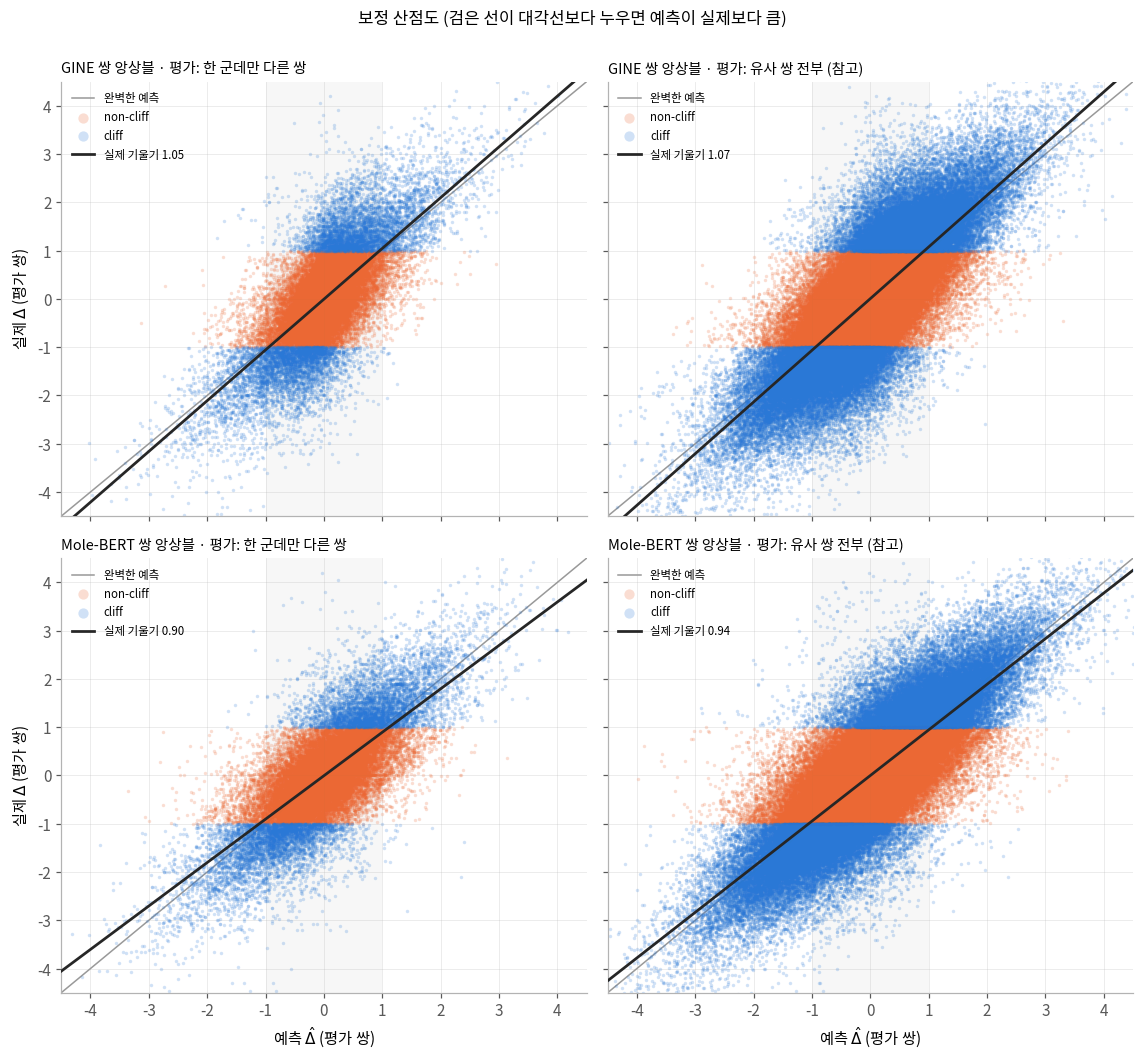

In [41]:
LIM = 4.5
fig, axes = plt.subplots(2, 2, figsize=(10.5, 9.6), sharex=True, sharey=True)
for row, enc in enumerate(['gnn', 'pt']):
    for a_, (st, pset) in zip(axes[row], RESULTS.items()):
        d, col = pset[pset.split == 'test'], f'pred_{enc}_ens'
        a_.plot([-LIM, LIM], [-LIM, LIM], color='0.6', lw=1, zorder=1, label='완벽한 예측')
        for cl, c, lbl in [(False, C2, 'non-cliff'), (True, C1, 'cliff')]:
            m = (d.is_cliff == cl).values
            a_.scatter(d[col][m], d.delta[m], s=5, alpha=0.22, color=c, lw=0, zorder=2, label=lbl)
        sl, ic = np.polyfit(d[col], d.delta, 1)
        xs = np.array([-LIM, LIM])
        a_.plot(xs, sl * xs + ic, color='0.15', lw=1.8, zorder=3, label=f'실제 기울기 {sl:.2f}')
        a_.axvspan(-1, 1, color='0.5', alpha=0.06, lw=0, zorder=0)
        a_.set(xlim=(-LIM, LIM), ylim=(-LIM, LIM))
        a_.set_title(f'{ENC[enc]} 앙상블 · {LABEL[st]}', loc='left', fontsize=9.5)
        a_.legend(fontsize=7.5, frameon=False, loc='upper left', markerscale=3)
        tidy(a_)
for a_ in axes[1]: a_.set_xlabel(r'예측 $\hat{\Delta}$ (평가 쌍)')
for a_ in axes[:, 0]: a_.set_ylabel(r'실제 $\Delta$ (평가 쌍)')
fig.suptitle(r'보정 산점도 (검은 선이 대각선보다 누우면 예측이 실제보다 큼)', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()

## 12. 결과 정리

**30개 타깃 · 시드 3개. 쌍 모델은 유사 쌍 전부(학습 쌍 349,565개)로 학습하고, 한 군데만 다른 평가 쌍(43,896개)에서 평가했다.**
모든 쌍은 학습 분자를 하나 이상 포함한다(기준 분자 없는 쌍 제외).

### Δ 예측 (평가 RMSE, cliff / non-cliff / bal)

| | 한 군데만 다른 평가 쌍 | 참고: 유사 쌍 전부 평가 |
|---|---|---|
| 항상 0 | 1.717 / 0.466 / 1.091 | 1.796 / 0.490 / 1.143 |
| SVR | 0.928 / **0.449** / **0.688** | 0.872 / **0.459** / 0.665 |
| GNN 분자별 | 1.378 / 0.564 / 0.971 | 1.338 / 0.589 / 0.964 |
| Mole-BERT 분자별 | 1.219 / 0.570 / 0.894 | 1.160 / 0.582 / 0.871 |
| GINE 쌍 앙상블 | 1.059 / 0.456 / 0.758 | 0.995 / 0.466 / 0.731 |
| Mole-BERT 쌍 앙상블 | **0.893** / 0.491 / 0.692 | **0.832** / 0.489 / **0.660** |

### 알게 된 것
- **Mole-BERT 쌍이 cliff에서 SVR보다 낮다** (한 군데만 평가 0.893 vs 0.928). bal은 SVR과 비슷하다 (0.692 vs 0.688)
- **유사 쌍 전부로 학습한 것이 컸다.** 한 군데만 다른 쌍으로만 학습했을 때 Mole-BERT cliff는 1.061이었다 (11번 기록)
- **non-cliff는 아직 SVR이 가장 낫다** (0.449 vs Mole-BERT 0.491)
- **쌍으로 넣는 것은 도움이 된다.** 같은 인코더로 분자별 예측해 빼면 모든 칸에서 쌍 모델보다 나쁘다
- **Δ만 맞추는 것이 아니다.** 실측 기준 분자 + Δ̂로 평가 분자 활성값을 추정하면 분자별 예측보다 낫고, Mole-BERT는 기준을 바꿔도 거의 흔들리지 않는다. 다만 평가 분자 활성값은 SVR이 가장 정확하다
- **누수가 GNN을 도왔다.** 평가 분자의 1/3이 다른 타깃의 학습 분자였고, 처음 보는 분자만 보면 Mole-BERT와 SVR은 cliff에서 대등하다 (0.919 vs 0.918)

### 다음 할 일
1. **누수 없는 학습** — 평가 분자를 모든 타깃의 학습에서 빼거나 타깃별로 학습해 SVR과의 관계가 유지되는지 확인 (팀 논의 중)
2. **손실을 평가 기준(bal)에 맞추기** — 지금 손실은 쌍 수가 많은 non-cliff에 치우친다. cliff와 non-cliff가 반반 되게 무게를 주고, 멈추는 기준도 bal로
3. **편집 정보 빼기 검토** — 빼도 성능이 같았다 (11번 기록). 모델을 단순하게 하려면 빼도 된다 (재학습 필요)
